L1 — COMPLETE OPENVINO HAND PERCEPTION
Image: /home/dipshikha/Music/cao/sample.jpeg
Size : 678 x 452
[OK] Palm detector
[OK] Hand landmark model

OpenVINO: 2026.3.1-22476-759c5a6ab8c-releases/2026/3
Device  : CPU

Palm input:
  [1,192,192,3]
Palm outputs:
  [1,2016,18]
  [1,2016,1]

Landmark input:
  [1,224,224,3]
Landmark outputs:
  [1,63]
  [1,1]
  [1,1]
  [1,63]

Anchors: (2016, 4)

PALM RESULT
Raw candidates : 14
Final palms    : 2
Palm latency   : 5.170 ms

Landmark network outputs:
  output 0: (1, 63) size= 63 min= -16.262971878051758 max= 197.7979278564453
  output 1: (1, 1) size= 1 min= 0.995631992816925 max= 0.995631992816925
  output 2: (1, 1) size= 1 min= 0.01089480146765709 max= 0.01089480146765709
  output 3: (1, 63) size= 63 min= -0.09275352209806442 max= 0.0939246118068695

Hand 1
Palm score : 0.9706032276153564
ROI center : 471.0226745605469 121.92852783203125
ROI size   : 334.47442626953125 334.47442626953125
Rotation   : -55.31391580176662 degrees
Scalars    : [(1, 0.

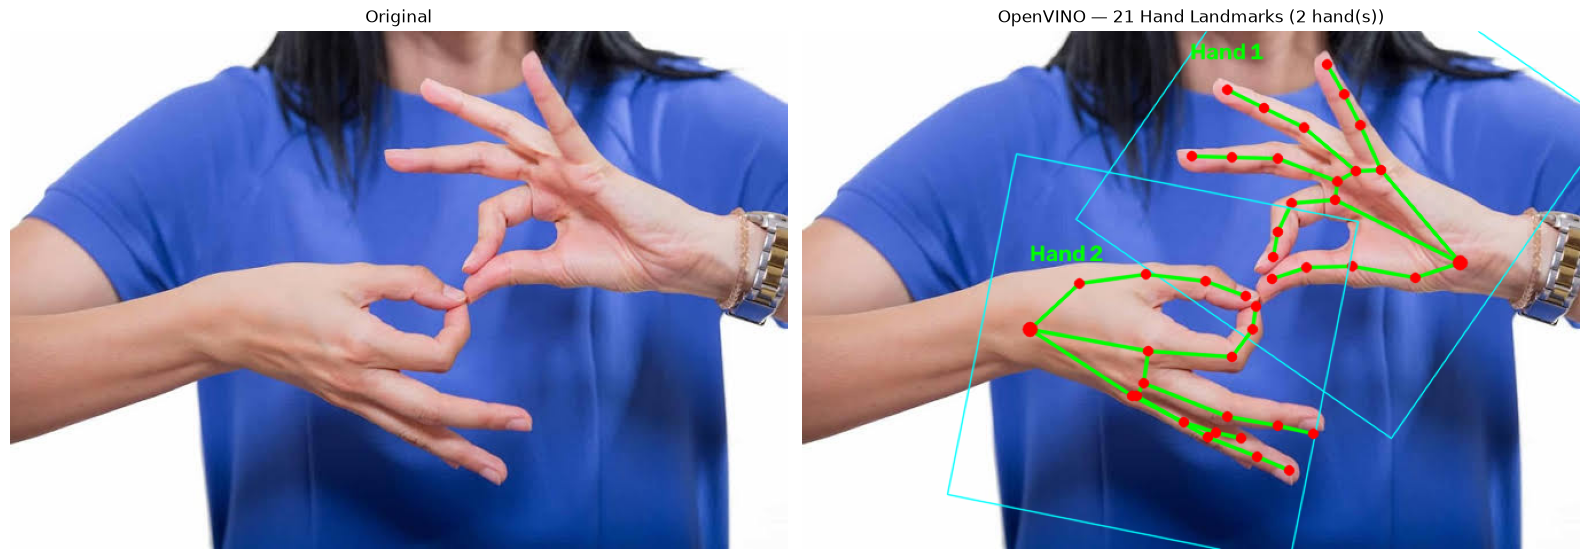

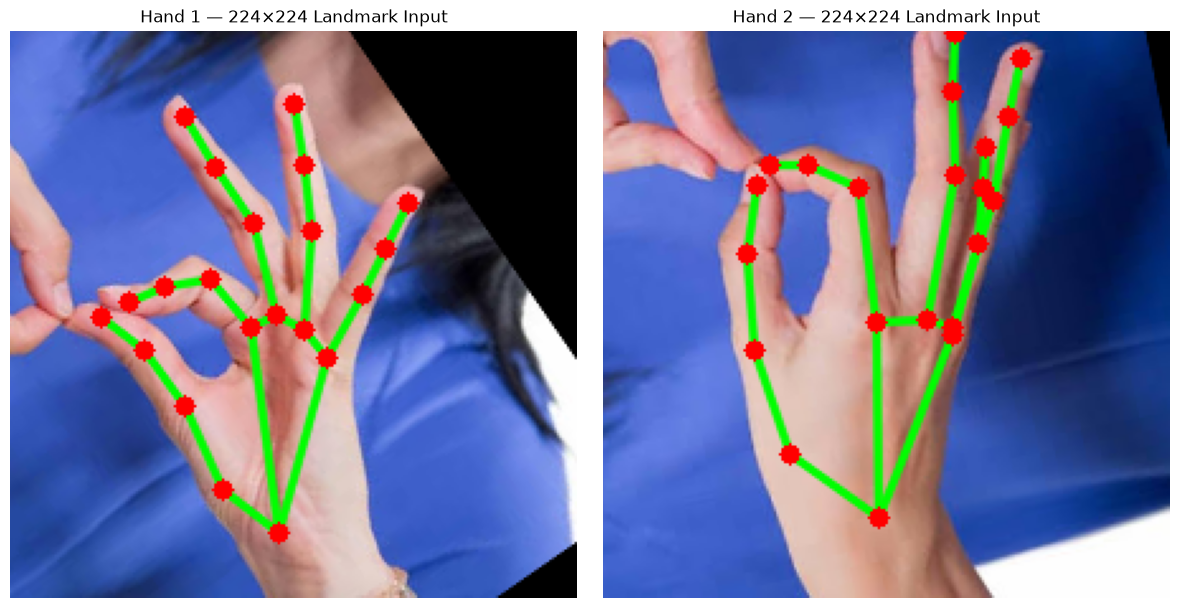


L1 FINAL
Hands detected : 2
Landmark shape : (2, 21, 3)
Palm latency   : 5.170 ms
Landmark total : 6.881 ms

Saved:
/home/dipshikha/Music/cao/CISLR_RESEARCH/CISLR_LANDMARK_MODEL/audit/l1_complete_hand_perception/l1_final_skeleton.jpg
/home/dipshikha/Music/cao/CISLR_RESEARCH/CISLR_LANDMARK_MODEL/audit/l1_complete_hand_perception/l1_landmarks.npy

PASS CONDITIONS:
1. Each 224×224 ROI contains ONE complete hand.
2. Wrist is near landmark 0.
3. Points 4,8,12,16,20 lie near fingertips.
4. Green skeleton follows the fingers.
5. Full-image skeleton lies on the same hand.
6. Two visible hands should produce two independent skeletons.


In [4]:
# ==========================================================================================
# CISLR LANDMARK MODEL — COMPLETE L1
# OpenVINO Palm Detection + Exact MediaPipe-style ROI + 21 Hand Landmarks + Skeleton
#
# CHANGE ONLY:
#     SAMPLE_IMAGE
#
# Models:
#     palm_detection_full.tflite
#     hand_landmark_full.tflite
#
# Inference:
#     OpenVINO only
#
# No MediaPipe Python runtime.
# ==========================================================================================

from pathlib import Path
import urllib.request
import math
import time
import json

import cv2
import numpy as np
import matplotlib.pyplot as plt
import openvino as ov


# ==========================================================================================
# L1.1 — CONFIGURATION
# ==========================================================================================

ROOT = Path("/home/dipshikha/Music/cao/CISLR_RESEARCH")

LANDMARK_ROOT = ROOT / "CISLR_LANDMARK_MODEL"

PALM_DIR = LANDMARK_ROOT / "models" / "pretrained" / "palm"
HAND_DIR = LANDMARK_ROOT / "models" / "pretrained" / "hand_landmark"

AUDIT_DIR = (
    LANDMARK_ROOT
    / "audit"
    / "l1_complete_hand_perception"
)

for p in [PALM_DIR, HAND_DIR, AUDIT_DIR]:
    p.mkdir(parents=True, exist_ok=True)


# ==========================================================================================
# CHANGE ONLY THIS
# ==========================================================================================

SAMPLE_IMAGE = Path(
    "/home/dipshikha/Music/cao/sample.jpeg"
)


# ==========================================================================================
# MODEL PATHS
# ==========================================================================================

PALM_MODEL = PALM_DIR / "palm_detection_full.tflite"
HAND_MODEL = HAND_DIR / "hand_landmark_full.tflite"

PALM_URL = (
    "https://storage.googleapis.com/"
    "mediapipe-assets/palm_detection_full.tflite"
)

HAND_URL = (
    "https://storage.googleapis.com/"
    "mediapipe-assets/hand_landmark_full.tflite"
)

DEVICE = "CPU"

PALM_SIZE = 192
LANDMARK_SIZE = 224

PALM_THRESHOLD = 0.50
NMS_THRESHOLD = 0.30
HAND_THRESHOLD = 0.50

MAX_HANDS = 2


print("=" * 100)
print("L1 — COMPLETE OPENVINO HAND PERCEPTION")
print("=" * 100)


# ==========================================================================================
# L1.2 — LOAD TEST IMAGE
# ==========================================================================================

if not SAMPLE_IMAGE.exists():
    raise FileNotFoundError(
        f"\nImage not found:\n{SAMPLE_IMAGE}\n"
        "Change SAMPLE_IMAGE at the top."
    )

image = cv2.imread(str(SAMPLE_IMAGE))

if image is None:
    raise RuntimeError("OpenCV could not read the sample image.")

H, W = image.shape[:2]

print("Image:", SAMPLE_IMAGE)
print("Size :", W, "x", H)


# ==========================================================================================
# L1.3 — VERIFY / DOWNLOAD MODELS
# ==========================================================================================

def is_tflite(path):

    if not path.exists():
        return False

    with open(path, "rb") as f:
        h = f.read(32)

    return b"TFL3" in h


def ensure_model(path, url, name):

    if is_tflite(path):
        print("[OK]", name)
        return

    if path.exists():
        path.unlink()

    print("[DOWNLOAD]", name)

    urllib.request.urlretrieve(
        url,
        str(path)
    )

    if not is_tflite(path):
        raise RuntimeError(
            f"{name} download is not valid TFLite."
        )

    print("[OK]", name)


ensure_model(
    PALM_MODEL,
    PALM_URL,
    "Palm detector"
)

ensure_model(
    HAND_MODEL,
    HAND_URL,
    "Hand landmark model"
)


# ==========================================================================================
# L1.4 — COMPILE WITH OPENVINO
# ==========================================================================================

core = ov.Core()

palm_model = core.read_model(str(PALM_MODEL))
hand_model = core.read_model(str(HAND_MODEL))

palm_net = core.compile_model(
    palm_model,
    DEVICE
)

hand_net = core.compile_model(
    hand_model,
    DEVICE
)

print("\nOpenVINO:", ov.__version__)
print("Device  :", DEVICE)

print("\nPalm input:")
for x in palm_net.inputs:
    print(" ", x.shape)

print("Palm outputs:")
for x in palm_net.outputs:
    print(" ", x.shape)

print("\nLandmark input:")
for x in hand_net.inputs:
    print(" ", x.shape)

print("Landmark outputs:")
for x in hand_net.outputs:
    print(" ", x.shape)


# ==========================================================================================
# L1.5 — PALM ANCHORS
# ==========================================================================================

def calc_scale(min_scale, max_scale, i, n):

    if n == 1:
        return (min_scale + max_scale) / 2

    return (
        min_scale
        + (max_scale - min_scale)
        * i / (n - 1)
    )


def generate_anchors():

    num_layers = 4

    min_scale = 0.1484375
    max_scale = 0.75

    strides = [8, 16, 16, 16]

    anchors = []

    layer = 0

    while layer < num_layers:

        same = layer

        anchors_per_cell = 0

        while (
            same < num_layers
            and strides[same] == strides[layer]
        ):

            # Normal anchor
            anchors_per_cell += 1

            # Interpolated anchor
            anchors_per_cell += 1

            same += 1

        stride = strides[layer]

        fh = int(math.ceil(PALM_SIZE / stride))
        fw = int(math.ceil(PALM_SIZE / stride))

        for y in range(fh):
            for x in range(fw):

                cx = (x + 0.5) / fw
                cy = (y + 0.5) / fh

                for _ in range(anchors_per_cell):

                    anchors.append(
                        [cx, cy, 1.0, 1.0]
                    )

        layer = same

    return np.asarray(
        anchors,
        dtype=np.float32
    )


ANCHORS = generate_anchors()

print("\nAnchors:", ANCHORS.shape)

assert ANCHORS.shape == (2016, 4)


# ==========================================================================================
# L1.6 — PALM PREPROCESSING
# ==========================================================================================

def preprocess_palm(frame):

    h, w = frame.shape[:2]

    scale = min(
        PALM_SIZE / w,
        PALM_SIZE / h
    )

    nw = int(round(w * scale))
    nh = int(round(h * scale))

    resized = cv2.resize(
        frame,
        (nw, nh),
        interpolation=cv2.INTER_LINEAR
    )

    rgb = cv2.cvtColor(
        resized,
        cv2.COLOR_BGR2RGB
    )

    left = (PALM_SIZE - nw) // 2
    top = (PALM_SIZE - nh) // 2

    right = PALM_SIZE - nw - left
    bottom = PALM_SIZE - nh - top

    padded = cv2.copyMakeBorder(
        rgb,
        top,
        bottom,
        left,
        right,
        cv2.BORDER_CONSTANT,
        value=(0, 0, 0)
    )

    tensor = (
        padded.astype(np.float32)
        / 255.0
    )

    shape = list(palm_net.input(0).shape)

    if shape == [1, 192, 192, 3]:

        tensor = tensor[None]

    elif shape == [1, 3, 192, 192]:

        tensor = np.transpose(
            tensor,
            (2, 0, 1)
        )[None]

    else:
        raise RuntimeError(
            f"Unexpected palm input shape {shape}"
        )

    return tensor, {
        "scale": scale,
        "left": left,
        "top": top
    }


# ==========================================================================================
# L1.7 — PALM INFERENCE
# ==========================================================================================

def palm_inference(frame):

    tensor, info = preprocess_palm(frame)

    t0 = time.perf_counter()

    result = palm_net([tensor])

    latency = (
        time.perf_counter() - t0
    ) * 1000

    reg = None
    logits = None

    for out in palm_net.outputs:

        arr = np.asarray(result[out])

        if arr.size == 2016 * 18:
            reg = arr.reshape(2016, 18)

        elif arr.size == 2016:
            logits = arr.reshape(2016)

    if reg is None or logits is None:
        raise RuntimeError(
            "Could not identify palm outputs."
        )

    return reg, logits, info, latency


# ==========================================================================================
# L1.8 — PALM DECODING
# ==========================================================================================

def sigmoid(x):

    x = np.clip(x, -100, 100)

    return 1.0 / (
        1.0 + np.exp(-x)
    )


def decode_palms(reg, logits):

    scores = sigmoid(logits)

    ids = np.where(
        scores >= PALM_THRESHOLD
    )[0]

    detections = []

    for i in ids:

        r = reg[i]

        ax, ay, aw, ah = ANCHORS[i]

        cx = r[0] / 192.0 * aw + ax
        cy = r[1] / 192.0 * ah + ay

        bw = r[2] / 192.0 * aw
        bh = r[3] / 192.0 * ah

        box = np.array(
            [
                cx - bw / 2,
                cy - bh / 2,
                cx + bw / 2,
                cy + bh / 2
            ],
            dtype=np.float32
        )

        kp = []

        for k in range(7):

            j = 4 + 2 * k

            x = r[j] / 192.0 * aw + ax
            y = r[j + 1] / 192.0 * ah + ay

            kp.append([x, y])

        detections.append(
            {
                "score": float(scores[i]),
                "bbox": box,
                "keypoints": np.asarray(
                    kp,
                    dtype=np.float32
                )
            }
        )

    detections.sort(
        key=lambda d: d["score"],
        reverse=True
    )

    return detections


# ==========================================================================================
# L1.9 — WEIGHTED NMS
# ==========================================================================================

def IoU(a, b):

    x1 = max(a[0], b[0])
    y1 = max(a[1], b[1])

    x2 = min(a[2], b[2])
    y2 = min(a[3], b[3])

    inter = (
        max(0.0, x2 - x1)
        *
        max(0.0, y2 - y1)
    )

    aa = (
        max(0.0, a[2] - a[0])
        *
        max(0.0, a[3] - a[1])
    )

    ab = (
        max(0.0, b[2] - b[0])
        *
        max(0.0, b[3] - b[1])
    )

    union = aa + ab - inter

    return inter / union if union > 0 else 0.0


def weighted_nms(detections):

    remaining = detections.copy()

    output = []

    while remaining:

        reference = remaining[0]

        group = []
        rest = []

        for d in remaining:

            if IoU(
                reference["bbox"],
                d["bbox"]
            ) > NMS_THRESHOLD:

                group.append(d)

            else:

                rest.append(d)

        weights = np.asarray(
            [d["score"] for d in group],
            dtype=np.float32
        )

        total = weights.sum()

        boxes = np.stack(
            [d["bbox"] for d in group]
        )

        kps = np.stack(
            [d["keypoints"] for d in group]
        )

        merged_box = (
            boxes
            * weights[:, None]
        ).sum(axis=0) / total

        merged_kps = (
            kps
            * weights[:, None, None]
        ).sum(axis=0) / total

        output.append(
            {
                "score": max(
                    d["score"]
                    for d in group
                ),

                "bbox": merged_box,

                "keypoints": merged_kps
            }
        )

        remaining = rest

    output.sort(
        key=lambda d: d["score"],
        reverse=True
    )

    return output[:MAX_HANDS]


# ==========================================================================================
# L1.10 — REMOVE PALM LETTERBOX
# ==========================================================================================

def palm_to_original(p, info):

    x = (
        p[0] * PALM_SIZE
        - info["left"]
    ) / info["scale"]

    y = (
        p[1] * PALM_SIZE
        - info["top"]
    ) / info["scale"]

    return np.array(
        [x, y],
        dtype=np.float32
    )


def palm_detection_to_original(det, info):

    box = det["bbox"]

    p1 = palm_to_original(
        [box[0], box[1]],
        info
    )

    p2 = palm_to_original(
        [box[2], box[3]],
        info
    )

    keypoints = np.stack(
        [
            palm_to_original(p, info)
            for p in det["keypoints"]
        ]
    )

    return {
        "score": det["score"],

        "bbox": np.array(
            [
                p1[0],
                p1[1],
                p2[0],
                p2[1]
            ],
            dtype=np.float32
        ),

        "keypoints": keypoints
    }


# ==========================================================================================
# L1.11 — EXACT MEDIAPIPE-STYLE PALM → HAND ROI
#
# Official graph:
#
# rotation_vector_start_keypoint_index = 0   wrist
# rotation_vector_end_keypoint_index   = 2   middle finger MCP
# rotation_vector_target_angle         = 90°
#
# RectTransformation:
#
# scale_x     = 2.6
# scale_y     = 2.6
# shift_y     = -0.5
# square_long = true
#
# IMPORTANT:
# shift_y happens in the ROTATED rectangle coordinate system.
# ==========================================================================================

def normalize_radians(angle):

    return (
        angle
        - 2 * math.pi
        * math.floor(
            (angle + math.pi)
            / (2 * math.pi)
        )
    )


def palm_to_hand_rect(det):

    box = det["bbox"]

    x1, y1, x2, y2 = box

    box_w = x2 - x1
    box_h = y2 - y1

    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0


    # ------------------------------------------------------------------
    # square_long = true
    # ------------------------------------------------------------------

    long_side = max(
        box_w,
        box_h
    )

    rect_w = long_side
    rect_h = long_side


    # ------------------------------------------------------------------
    # Rotation:
    # wrist -> middle MCP should align with +90 degrees.
    # ------------------------------------------------------------------

    wrist = det["keypoints"][0]
    middle = det["keypoints"][2]

    angle = math.atan2(
        -(
            middle[1]
            - wrist[1]
        ),
        middle[0]
        - wrist[0]
    )

    rotation = normalize_radians(
        math.pi / 2.0
        - angle
    )


    # ------------------------------------------------------------------
    # RectTransformation shift_y = -0.5
    #
    # MediaPipe applies shift in rotated rectangle coordinates.
    #
    # x_shift = width*shift_x*cos(rotation)
    #           - height*shift_y*sin(rotation)
    #
    # y_shift = width*shift_x*sin(rotation)
    #           + height*shift_y*cos(rotation)
    #
    # shift_x = 0
    # shift_y = -0.5
    # ------------------------------------------------------------------

    shift_y = -0.5

    x_shift = (
        -rect_h
        * shift_y
        * math.sin(rotation)
    )

    y_shift = (
        rect_h
        * shift_y
        * math.cos(rotation)
    )

    cx += x_shift
    cy += y_shift


    # ------------------------------------------------------------------
    # Scale after shift.
    # ------------------------------------------------------------------

    rect_w *= 2.6
    rect_h *= 2.6


    return {
        "cx": float(cx),
        "cy": float(cy),

        "width": float(rect_w),
        "height": float(rect_h),

        "rotation": float(rotation)
    }


# ==========================================================================================
# L1.12 — BUILD 224×224 ROTATED ROI
#
# Instead of guessing an inverse transform, we create ONE perspective matrix
# and later use its exact inverse for the landmarks.
# ==========================================================================================

def rect_corners(rect):

    cx = rect["cx"]
    cy = rect["cy"]

    rw = rect["width"]
    rh = rect["height"]

    rotation = rect["rotation"]

    c = math.cos(rotation)
    s = math.sin(rotation)

    local = np.array(
        [
            [-rw / 2, -rh / 2],  # TL
            [ rw / 2, -rh / 2],  # TR
            [ rw / 2,  rh / 2],  # BR
            [-rw / 2,  rh / 2],  # BL
        ],
        dtype=np.float32
    )

    R = np.array(
        [
            [c, -s],
            [s,  c]
        ],
        dtype=np.float32
    )

    points = (
        local @ R.T
        + np.array(
            [cx, cy],
            dtype=np.float32
        )
    )

    return points.astype(
        np.float32
    )


def crop_hand_roi(frame, rect):

    src = rect_corners(rect)

    dst = np.array(
        [
            [0, 0],
            [LANDMARK_SIZE - 1, 0],
            [
                LANDMARK_SIZE - 1,
                LANDMARK_SIZE - 1
            ],
            [
                0,
                LANDMARK_SIZE - 1
            ]
        ],
        dtype=np.float32
    )

    M = cv2.getPerspectiveTransform(
        src,
        dst
    )

    M_inv = cv2.getPerspectiveTransform(
        dst,
        src
    )

    crop = cv2.warpPerspective(
        frame,
        M,
        (
            LANDMARK_SIZE,
            LANDMARK_SIZE
        ),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0)
    )

    return crop, M, M_inv, src


# ==========================================================================================
# L1.13 — LANDMARK MODEL
# ==========================================================================================

def preprocess_hand(crop):

    rgb = cv2.cvtColor(
        crop,
        cv2.COLOR_BGR2RGB
    )

    tensor = (
        rgb.astype(np.float32)
        / 255.0
    )

    shape = list(
        hand_net.input(0).shape
    )

    if shape == [1, 224, 224, 3]:

        tensor = tensor[None]

    elif shape == [1, 3, 224, 224]:

        tensor = np.transpose(
            tensor,
            (2, 0, 1)
        )[None]

    else:

        raise RuntimeError(
            f"Unexpected landmark input shape: {shape}"
        )

    return tensor


def run_hand_landmark(crop):

    tensor = preprocess_hand(crop)

    t0 = time.perf_counter()

    result = hand_net([tensor])

    latency = (
        time.perf_counter()
        - t0
    ) * 1000


    screen_landmarks = None
    world_landmarks = None
    scalar_outputs = []


    print("\nLandmark network outputs:")

    for i, out in enumerate(
        hand_net.outputs
    ):

        arr = np.asarray(
            result[out]
        )

        flat = arr.reshape(-1)

        print(
            f"  output {i}:",
            arr.shape,
            "size=",
            arr.size,
            "min=",
            float(arr.min()),
            "max=",
            float(arr.max())
        )


        # --------------------------------------------------------------
        # Both screen landmarks and world landmarks contain 63 values.
        #
        # Screen coordinates normally have x/y in roughly 0..224.
        # World landmarks are much smaller metric-like values.
        # --------------------------------------------------------------

        if flat.size == 63:

            candidate = flat.reshape(
                21,
                3
            ).astype(np.float32)

            xy_abs = float(
                np.max(
                    np.abs(
                        candidate[:, :2]
                    )
                )
            )

            if xy_abs > 2.0:

                screen_landmarks = candidate

            else:

                world_landmarks = candidate


        elif flat.size == 1:

            scalar_outputs.append(
                (
                    i,
                    float(flat[0])
                )
            )


    if screen_landmarks is None:

        raise RuntimeError(
            "\nCould not identify the 21×3 screen landmark output."
        )


    # --------------------------------------------------------------
    # Determine scalar meaning robustly enough for diagnostics.
    #
    # Model generally provides presence and handedness scalars.
    # We don't use handedness to control geometry.
    # --------------------------------------------------------------

    return (
        screen_landmarks,
        world_landmarks,
        scalar_outputs,
        latency
    )


# ==========================================================================================
# L1.14 — MAP 21 LANDMARKS BACK THROUGH EXACT INVERSE ROI TRANSFORM
# ==========================================================================================

def project_landmarks_back(
    landmarks,
    M_inv,
    rect
):

    # Screen landmarks from this model are in 224×224 model coordinates.
    xy = landmarks[:, :2].astype(
        np.float32
    )

    pts = xy.reshape(
        -1,
        1,
        2
    )

    projected = cv2.perspectiveTransform(
        pts,
        M_inv
    ).reshape(
        -1,
        2
    )

    # Z is relative depth. Scale it approximately with ROI width.
    z = (
        landmarks[:, 2]
        / LANDMARK_SIZE
        * rect["width"]
    )

    return np.column_stack(
        [
            projected,
            z
        ]
    ).astype(np.float32)


# ==========================================================================================
# L1.15 — RUN COMPLETE PIPELINE
# ==========================================================================================

reg, logits, palm_info, palm_latency = (
    palm_inference(image)
)

decoded = decode_palms(
    reg,
    logits
)

filtered = weighted_nms(
    decoded
)

palms = [
    palm_detection_to_original(
        d,
        palm_info
    )
    for d in filtered
]


print("\n" + "=" * 100)
print("PALM RESULT")
print("=" * 100)

print("Raw candidates :", len(decoded))
print("Final palms    :", len(palms))
print("Palm latency   :", f"{palm_latency:.3f} ms")


results = []

for i, palm in enumerate(palms):

    rect = palm_to_hand_rect(
        palm
    )

    crop, M, M_inv, corners = (
        crop_hand_roi(
            image,
            rect
        )
    )

    (
        lm_crop,
        world,
        scalars,
        lm_latency
    ) = run_hand_landmark(
        crop
    )

    lm_image = project_landmarks_back(
        lm_crop,
        M_inv,
        rect
    )

    results.append(
        {
            "palm": palm,
            "rect": rect,
            "crop": crop,
            "corners": corners,
            "landmarks_crop": lm_crop,
            "landmarks": lm_image,
            "world_landmarks": world,
            "scalars": scalars,
            "latency": lm_latency
        }
    )

    print("\nHand", i + 1)
    print("Palm score :", palm["score"])
    print("ROI center :", rect["cx"], rect["cy"])
    print("ROI size   :", rect["width"], rect["height"])
    print(
        "Rotation   :",
        math.degrees(rect["rotation"]),
        "degrees"
    )
    print("Scalars    :", scalars)
    print(
        "Landmark latency:",
        f"{lm_latency:.3f} ms"
    )


# ==========================================================================================
# L1.16 — DRAW FULL SKELETON + SAVE
# ==========================================================================================

HAND_CONNECTIONS = [

    # Thumb
    (0,1), (1,2), (2,3), (3,4),

    # Index
    (0,5), (5,6), (6,7), (7,8),

    # Middle
    (5,9), (9,10), (10,11), (11,12),

    # Ring
    (9,13), (13,14), (14,15), (15,16),

    # Little
    (13,17), (17,18), (18,19), (19,20),

    # Palm
    (0,17)
]


annotated = image.copy()


# ------------------------------------------------------------------------------------------
# DRAW EACH HAND
# ------------------------------------------------------------------------------------------

for hand_id, r in enumerate(results):

    lm = r["landmarks"]


    # --------------------------------------------------------------------------------------
    # ROI — thin cyan polygon for debugging
    # --------------------------------------------------------------------------------------

    corners = np.round(
        r["corners"]
    ).astype(np.int32)

    cv2.polylines(
        annotated,
        [corners],
        True,
        (255, 255, 0),
        1,
        cv2.LINE_AA
    )


    # --------------------------------------------------------------------------------------
    # Skeleton
    # --------------------------------------------------------------------------------------

    for a, b in HAND_CONNECTIONS:

        x1 = int(round(lm[a, 0]))
        y1 = int(round(lm[a, 1]))

        x2 = int(round(lm[b, 0]))
        y2 = int(round(lm[b, 1]))

        # Do not draw absurd out-of-image lines.
        if (
            -W <= x1 <= 2 * W
            and -H <= y1 <= 2 * H
            and -W <= x2 <= 2 * W
            and -H <= y2 <= 2 * H
        ):

            cv2.line(
                annotated,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2,
                cv2.LINE_AA
            )


    # --------------------------------------------------------------------------------------
    # 21 landmarks
    # --------------------------------------------------------------------------------------

    for landmark_id in range(21):

        x = int(
            round(
                lm[
                    landmark_id,
                    0
                ]
            )
        )

        y = int(
            round(
                lm[
                    landmark_id,
                    1
                ]
            )
        )

        if (
            0 <= x < W
            and
            0 <= y < H
        ):

            radius = (
                6
                if landmark_id == 0
                else 4
            )

            cv2.circle(
                annotated,
                (x, y),
                radius,
                (0, 0, 255),
                -1,
                cv2.LINE_AA
            )


    # --------------------------------------------------------------------------------------
    # Label
    # --------------------------------------------------------------------------------------

    visible = (
        (lm[:,0] >= 0)
        &
        (lm[:,0] < W)
        &
        (lm[:,1] >= 0)
        &
        (lm[:,1] < H)
    )

    if visible.any():

        lx = int(
            np.min(
                lm[
                    visible,
                    0
                ]
            )
        )

        ly = int(
            np.min(
                lm[
                    visible,
                    1
                ]
            )
        )

        cv2.putText(
            annotated,
            f"Hand {hand_id + 1}",
            (
                max(5, lx),
                max(25, ly - 10)
            ),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.65,
            (0,255,0),
            2,
            cv2.LINE_AA
        )


# ==========================================================================================
# SAVE
# ==========================================================================================

output_image = (
    AUDIT_DIR
    / "l1_final_skeleton.jpg"
)

cv2.imwrite(
    str(output_image),
    annotated
)


if results:

    landmarks_array = np.stack(
        [
            r["landmarks"]
            for r in results
        ]
    )

else:

    landmarks_array = np.empty(
        (0,21,3),
        dtype=np.float32
    )


np.save(
    AUDIT_DIR
    / "l1_landmarks.npy",
    landmarks_array
)


# ==========================================================================================
# DISPLAY 1 — ORIGINAL / FINAL
# ==========================================================================================

plt.figure(
    figsize=(16,8)
)

plt.subplot(1,2,1)

plt.imshow(
    cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Original")
plt.axis("off")


plt.subplot(1,2,2)

plt.imshow(
    cv2.cvtColor(
        annotated,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    f"OpenVINO — 21 Hand Landmarks ({len(results)} hand(s))"
)

plt.axis("off")

plt.tight_layout()
plt.show()


# ==========================================================================================
# DISPLAY 2 — CRITICAL ROI DEBUG VIEW
# ==========================================================================================

if results:

    plt.figure(
        figsize=(
            6 * len(results),
            6
        )
    )

    for i, r in enumerate(results):

        crop_draw = (
            r["crop"].copy()
        )

        lm = r[
            "landmarks_crop"
        ]


        # --------------------------------------------------------------
        # Draw skeleton INSIDE 224×224 model input.
        #
        # If this is wrong, ROI/model input is wrong.
        # If this is right but full-image skeleton is wrong,
        # inverse projection is wrong.
        # --------------------------------------------------------------

        for a,b in HAND_CONNECTIONS:

            p1 = (
                int(round(lm[a,0])),
                int(round(lm[a,1]))
            )

            p2 = (
                int(round(lm[b,0])),
                int(round(lm[b,1]))
            )

            cv2.line(
                crop_draw,
                p1,
                p2,
                (0,255,0),
                2,
                cv2.LINE_AA
            )


        for j in range(21):

            p = (
                int(round(lm[j,0])),
                int(round(lm[j,1]))
            )

            cv2.circle(
                crop_draw,
                p,
                4,
                (0,0,255),
                -1
            )


        plt.subplot(
            1,
            len(results),
            i + 1
        )

        plt.imshow(
            cv2.cvtColor(
                crop_draw,
                cv2.COLOR_BGR2RGB
            )
        )

        plt.title(
            f"Hand {i+1} — 224×224 Landmark Input"
        )

        plt.xlim(
            0,
            224
        )

        plt.ylim(
            224,
            0
        )

        plt.axis("off")


    plt.tight_layout()
    plt.show()


# ==========================================================================================
# FINAL DIAGNOSTICS
# ==========================================================================================

print("\n" + "=" * 100)
print("L1 FINAL")
print("=" * 100)

print("Hands detected :", len(results))
print("Landmark shape :", landmarks_array.shape)

print(
    "Palm latency   :",
    f"{palm_latency:.3f} ms"
)

print(
    "Landmark total :",
    f"{sum(r['latency'] for r in results):.3f} ms"
)

print("\nSaved:")
print(output_image)

print(
    AUDIT_DIR
    / "l1_landmarks.npy"
)

print("\nPASS CONDITIONS:")
print("1. Each 224×224 ROI contains ONE complete hand.")
print("2. Wrist is near landmark 0.")
print("3. Points 4,8,12,16,20 lie near fingertips.")
print("4. Green skeleton follows the fingers.")
print("5. Full-image skeleton lies on the same hand.")
print("6. Two visible hands should produce two independent skeletons.")

In [7]:
# ==========================================================================================
# CISLR — L1 VIDEO VALIDATION
# LIVE MP4 PLAYBACK WITH:
#
#   MP4 frame
#       ↓
#   OpenVINO palm detector
#       ↓
#   up to 2 hands
#       ↓
#   MediaPipe-style oriented ROI
#       ↓
#   OpenVINO 21-point landmark model
#       ↓
#   full skeleton drawn on ORIGINAL VIDEO
#
# IMPORTANT:
# Run the WORKING L1 still-image cell FIRST.
# This cell reuses:
#
#   palm_inference()
#   decode_palms()
#   weighted_nms()
#   palm_detection_to_original()
#   palm_to_hand_rect()
#   crop_hand_roi()
#   run_hand_landmark()
#   project_landmarks_back()
#   HAND_CONNECTIONS
#
# ==========================================================================================

from pathlib import Path
import cv2
import numpy as np
import time


# ==========================================================================================
# V1 — CHANGE ONLY THIS
# ==========================================================================================

VIDEO_PATH = Path(
    "/home/dipshikha/Music/cao/CISLR_v1.5-a_videos/0YIk1iTjDVY_1.mp4"
)


# ==========================================================================================
# VIDEO SETTINGS
# ==========================================================================================

# Process every frame.
#
# If playback is too slow:
#     change to 2
#
# That means:
#     infer every second frame
#     reuse latest landmarks between inference frames.

FRAME_STEP = 1


# Display size.
#
# 1.0 = original video resolution
# 0.8 = 80%
# 0.6 = 60%

DISPLAY_SCALE = 1.0


# Draw the cyan hand ROI?
#
# False gives a cleaner final visualization.

DRAW_ROI = False


# Draw landmark numbers 0...20?
#
# False = clean skeleton
# True  = useful for debugging

DRAW_LANDMARK_NUMBERS = False


# Save processed video?

SAVE_OUTPUT = True


OUTPUT_VIDEO = (
    AUDIT_DIR
    / "l1_cislr_live_landmarks.mp4"
)


# ==========================================================================================
# V2 — CHECK THAT L1 IS ALREADY LOADED
# ==========================================================================================

required_objects = [

    "palm_inference",
    "decode_palms",
    "weighted_nms",
    "palm_detection_to_original",

    "palm_to_hand_rect",
    "crop_hand_roi",

    "run_hand_landmark",
    "project_landmarks_back",

    "HAND_CONNECTIONS"
]


missing = [

    name
    for name in required_objects
    if name not in globals()

]


if missing:

    raise RuntimeError(

        "\nRun the WORKING L1 still-image cell first.\n\n"

        "Missing:\n"

        + "\n".join(
            missing
        )

    )


# ==========================================================================================
# V3 — CHECK VIDEO
# ==========================================================================================

if not VIDEO_PATH.exists():

    raise FileNotFoundError(
        f"\nCISLR video not found:\n{VIDEO_PATH}"
    )


cap = cv2.VideoCapture(
    str(VIDEO_PATH)
)


if not cap.isOpened():

    raise RuntimeError(
        f"Could not open:\n{VIDEO_PATH}"
    )


fps = cap.get(
    cv2.CAP_PROP_FPS
)


if fps <= 0:

    fps = 25.0


frame_count_reported = int(
    cap.get(
        cv2.CAP_PROP_FRAME_COUNT
    )
)


video_w = int(
    cap.get(
        cv2.CAP_PROP_FRAME_WIDTH
    )
)


video_h = int(
    cap.get(
        cv2.CAP_PROP_FRAME_HEIGHT
    )
)


print("=" * 100)

print(
    "CISLR — LIVE OPENVINO HAND LANDMARK TEST"
)

print("=" * 100)

print(
    "Video:",
    VIDEO_PATH
)

print(
    "Resolution:",
    video_w,
    "x",
    video_h
)

print(
    "Video FPS:",
    fps
)

print(
    "Reported frames:",
    frame_count_reported
)

print(
    "Frame step:",
    FRAME_STEP
)


# ==========================================================================================
# V4 — OUTPUT VIDEO WRITER
# ==========================================================================================

writer = None


if SAVE_OUTPUT:

    fourcc = cv2.VideoWriter_fourcc(
        *"mp4v"
    )

    writer = cv2.VideoWriter(

        str(
            OUTPUT_VIDEO
        ),

        fourcc,

        fps,

        (
            video_w,
            video_h
        )

    )


    if not writer.isOpened():

        print(
            "[WARNING] Could not create output MP4."
        )

        writer = None

    else:

        print(
            "Saving output to:",
            OUTPUT_VIDEO
        )


# ==========================================================================================
# V5 — DRAWING FUNCTION
# ==========================================================================================

def draw_hand_skeleton_video(
    frame,
    landmarks,
    hand_number,
    palm_score=None,
    corners=None
):

    h, w = frame.shape[:2]


    # --------------------------------------------------------------------------------------
    # OPTIONAL ROI
    # --------------------------------------------------------------------------------------

    if (
        DRAW_ROI
        and
        corners is not None
    ):

        pts = np.round(
            corners
        ).astype(
            np.int32
        )

        cv2.polylines(

            frame,

            [
                pts
            ],

            True,

            (
                255,
                255,
                0
            ),

            1,

            cv2.LINE_AA

        )


    # --------------------------------------------------------------------------------------
    # SKELETON
    # --------------------------------------------------------------------------------------

    for a, b in HAND_CONNECTIONS:

        x1 = int(
            round(
                landmarks[
                    a,
                    0
                ]
            )
        )

        y1 = int(
            round(
                landmarks[
                    a,
                    1
                ]
            )
        )


        x2 = int(
            round(
                landmarks[
                    b,
                    0
                ]
            )
        )

        y2 = int(
            round(
                landmarks[
                    b,
                    1
                ]
            )
        )


        # Only draw reasonable coordinates.

        if (

            -w <= x1 <= 2 * w
            and

            -h <= y1 <= 2 * h
            and

            -w <= x2 <= 2 * w
            and

            -h <= y2 <= 2 * h

        ):

            cv2.line(

                frame,

                (
                    x1,
                    y1
                ),

                (
                    x2,
                    y2
                ),

                (
                    0,
                    255,
                    0
                ),

                2,

                cv2.LINE_AA

            )


    # --------------------------------------------------------------------------------------
    # LANDMARK POINTS
    # --------------------------------------------------------------------------------------

    for landmark_id in range(
        21
    ):

        x = int(
            round(
                landmarks[
                    landmark_id,
                    0
                ]
            )
        )

        y = int(
            round(
                landmarks[
                    landmark_id,
                    1
                ]
            )
        )


        if (
            0 <= x < w
            and
            0 <= y < h
        ):

            radius = (
                6
                if landmark_id == 0
                else 4
            )


            cv2.circle(

                frame,

                (
                    x,
                    y
                ),

                radius,

                (
                    0,
                    0,
                    255
                ),

                -1,

                cv2.LINE_AA

            )


            # --------------------------------------------------------------------------
            # OPTIONAL LANDMARK NUMBER
            # --------------------------------------------------------------------------

            if DRAW_LANDMARK_NUMBERS:

                cv2.putText(

                    frame,

                    str(
                        landmark_id
                    ),

                    (
                        x + 5,
                        y - 5
                    ),

                    cv2.FONT_HERSHEY_SIMPLEX,

                    0.35,

                    (
                        255,
                        255,
                        255
                    ),

                    1,

                    cv2.LINE_AA

                )


    # --------------------------------------------------------------------------------------
    # HAND LABEL
    # --------------------------------------------------------------------------------------

    visible = (

        (
            landmarks[
                :,
                0
            ]
            >= 0
        )

        &

        (
            landmarks[
                :,
                0
            ]
            < w
        )

        &

        (
            landmarks[
                :,
                1
            ]
            >= 0
        )

        &

        (
            landmarks[
                :,
                1
            ]
            < h
        )

    )


    if np.any(
        visible
    ):

        lx = int(
            np.min(
                landmarks[
                    visible,
                    0
                ]
            )
        )

        ly = int(
            np.min(
                landmarks[
                    visible,
                    1
                ]
            )
        )


        label = (
            f"Hand {hand_number}"
        )


        if palm_score is not None:

            label += (
                f"  palm={palm_score:.2f}"
            )


        cv2.putText(

            frame,

            label,

            (
                max(
                    5,
                    lx
                ),

                max(
                    25,
                    ly - 10
                )
            ),

            cv2.FONT_HERSHEY_SIMPLEX,

            0.55,

            (
                0,
                255,
                0
            ),

            2,

            cv2.LINE_AA

        )


# ==========================================================================================
# V6 — PROCESS ONE VIDEO FRAME
# ==========================================================================================

def process_cislr_frame(
    frame
):

    frame_start = (
        time.perf_counter()
    )


    # ======================================================================================
    # PALM DETECTOR
    # ======================================================================================

    (
        reg,
        logits,
        palm_info,
        palm_latency
    ) = palm_inference(
        frame
    )


    decoded = decode_palms(
        reg,
        logits
    )


    filtered = weighted_nms(
        decoded
    )


    palms = [

        palm_detection_to_original(
            d,
            palm_info
        )

        for d
        in filtered

    ]


    # ======================================================================================
    # LANDMARK MODEL
    # ======================================================================================

    hands = []

    landmark_latency_total = (
        0.0
    )


    for palm in palms:

        try:

            # --------------------------------------------------------------------------
            # Palm → hand ROI
            # --------------------------------------------------------------------------

            rect = palm_to_hand_rect(
                palm
            )


            (
                crop,
                M,
                M_inv,
                corners
            ) = crop_hand_roi(
                frame,
                rect
            )


            # --------------------------------------------------------------------------
            # 21 landmark inference
            # --------------------------------------------------------------------------

            (
                lm_crop,
                world_landmarks,
                scalar_outputs,
                lm_latency
            ) = run_hand_landmark(
                crop
            )


            landmark_latency_total += (
                lm_latency
            )


            # --------------------------------------------------------------------------
            # Back to original frame
            # --------------------------------------------------------------------------

            landmarks = (
                project_landmarks_back(

                    lm_crop,

                    M_inv,

                    rect

                )
            )


            hands.append(
                {

                    "palm_score":
                        float(
                            palm[
                                "score"
                            ]
                        ),

                    "landmarks":
                        landmarks,

                    "landmarks_crop":
                        lm_crop,

                    "world_landmarks":
                        world_landmarks,

                    "scalars":
                        scalar_outputs,

                    "rect":
                        rect,

                    "corners":
                        corners

                }
            )


        except Exception as e:

            print(
                "\n[WARNING] Hand skipped:",
                str(
                    e
                )
            )


    total_latency = (

        time.perf_counter()
        - frame_start

    ) * 1000


    return {

        "hands":
            hands,

        "palm_latency_ms":
            palm_latency,

        "landmark_latency_ms":
            landmark_latency_total,

        "total_latency_ms":
            total_latency

    }


# ==========================================================================================
# V7 — LIVE MP4 LOOP
# ==========================================================================================

frame_index = 0

processed_frames = 0

detected_frames = 0

two_hand_frames = 0


total_pipeline_time = 0.0

total_palm_time = 0.0

total_landmark_time = 0.0


# ------------------------------------------------------------------------------------------
# Used when FRAME_STEP > 1.
# ------------------------------------------------------------------------------------------

last_result = None


print("\n" + "=" * 100)

print(
    "VIDEO STARTED"
)

print("=" * 100)

print(
    "Press Q or ESC to stop."
)

print(
    "Press SPACE to pause/resume."
)

print("=" * 100)


paused = False


while True:

    # ======================================================================================
    # PAUSE
    # ======================================================================================

    if paused:

        key = (
            cv2.waitKey(
                30
            )
            & 0xFF
        )

        if key == ord(" "):

            paused = False

        elif (
            key == ord("q")
            or key == 27
        ):

            break

        continue


    # ======================================================================================
    # READ FRAME
    # ======================================================================================

    ok, frame = cap.read()


    if not ok:

        print(
            "\nEnd of video."
        )

        break


    frame_index += 1


    # ======================================================================================
    # RUN L1
    # ======================================================================================

    if (
        frame_index == 1
        or
        frame_index % FRAME_STEP == 0
    ):

        result = process_cislr_frame(
            frame
        )

        last_result = result


        processed_frames += 1


        total_pipeline_time += (
            result[
                "total_latency_ms"
            ]
        )


        total_palm_time += (
            result[
                "palm_latency_ms"
            ]
        )


        total_landmark_time += (
            result[
                "landmark_latency_ms"
            ]
        )


        if len(
            result[
                "hands"
            ]
        ) >= 1:

            detected_frames += 1


        if len(
            result[
                "hands"
            ]
        ) >= 2:

            two_hand_frames += 1


    else:

        result = last_result


    # ======================================================================================
    # DRAW
    # ======================================================================================

    display = (
        frame.copy()
    )


    if result is not None:

        for i, hand in enumerate(
            result[
                "hands"
            ]
        ):

            draw_hand_skeleton_video(

                display,

                hand[
                    "landmarks"
                ],

                i + 1,

                palm_score=
                    hand[
                        "palm_score"
                    ],

                corners=
                    hand[
                        "corners"
                    ]

            )


    # ======================================================================================
    # STATUS BAR
    # ======================================================================================

    if result is not None:

        hands_now = len(
            result[
                "hands"
            ]
        )

        latency_now = (
            result[
                "total_latency_ms"
            ]
        )

    else:

        hands_now = 0
        latency_now = 0.0


    inference_fps = (

        1000.0
        / latency_now

        if latency_now > 0

        else 0.0

    )


    # --------------------------------------------------------------------------------------
    # Black status panel
    # --------------------------------------------------------------------------------------

    cv2.rectangle(

        display,

        (
            0,
            0
        ),

        (
            display.shape[
                1
            ],
            38
        ),

        (
            0,
            0,
            0
        ),

        -1

    )


    status = (

        f"CISLR | "
        f"Frame {frame_index} | "
        f"Hands {hands_now} | "
        f"L1 {latency_now:.1f} ms | "
        f"{inference_fps:.1f} FPS"

    )


    cv2.putText(

        display,

        status,

        (
            10,
            25
        ),

        cv2.FONT_HERSHEY_SIMPLEX,

        0.55,

        (
            0,
            255,
            0
        ),

        1,

        cv2.LINE_AA

    )


    # ======================================================================================
    # SAVE FULL-RESOLUTION OUTPUT
    # ======================================================================================

    if writer is not None:

        writer.write(
            display
        )


    # ======================================================================================
    # DISPLAY
    # ======================================================================================

    if DISPLAY_SCALE != 1.0:

        show_w = int(
            display.shape[
                1
            ]
            * DISPLAY_SCALE
        )

        show_h = int(
            display.shape[
                0
            ]
            * DISPLAY_SCALE
        )


        shown = cv2.resize(

            display,

            (
                show_w,
                show_h
            )

        )

    else:

        shown = display


    cv2.imshow(
        "CISLR - OpenVINO Hand Landmarks",
        shown
    )


    # ======================================================================================
    # APPROXIMATE ORIGINAL VIDEO PLAYBACK SPEED
    # ======================================================================================

    delay = max(
        1,
        int(
            1000.0
            / fps
        )
    )


    key = (
        cv2.waitKey(
            delay
        )
        & 0xFF
    )


    if (
        key == ord("q")
        or
        key == 27
    ):

        print(
            "\nStopped by user."
        )

        break


    elif key == ord(" "):

        paused = True


# ==========================================================================================
# V8 — CLEANUP
# ==========================================================================================

cap.release()


if writer is not None:

    writer.release()


cv2.destroyAllWindows()


# ==========================================================================================
# V9 — FINAL VIDEO AUDIT
# ==========================================================================================

print("\n" + "=" * 100)

print(
    "CISLR VIDEO L1 AUDIT"
)

print("=" * 100)


print(
    "Video:",
    VIDEO_PATH.name
)

print(
    "Decoded frames:",
    frame_index
)

print(
    "Inference frames:",
    processed_frames
)


if processed_frames > 0:

    detection_rate = (

        detected_frames
        / processed_frames
        * 100.0

    )


    two_hand_rate = (

        two_hand_frames
        / processed_frames
        * 100.0

    )


    avg_pipeline = (

        total_pipeline_time
        / processed_frames

    )


    avg_palm = (

        total_palm_time
        / processed_frames

    )


    avg_landmark = (

        total_landmark_time
        / processed_frames

    )


    pipeline_fps = (

        1000.0
        / avg_pipeline

        if avg_pipeline > 0

        else 0.0

    )


    print(
        "\nFrames with >=1 hand:",
        detected_frames
    )

    print(
        "Detection rate:",
        f"{detection_rate:.2f}%"
    )


    print(
        "\nFrames with 2 hands:",
        two_hand_frames
    )

    print(
        "Two-hand rate:",
        f"{two_hand_rate:.2f}%"
    )


    print(
        "\nAverage palm inference:",
        f"{avg_palm:.3f} ms"
    )

    print(
        "Average landmark inference:",
        f"{avg_landmark:.3f} ms"
    )

    print(
        "Average complete L1:",
        f"{avg_pipeline:.3f} ms"
    )

    print(
        "Approx L1 throughput:",
        f"{pipeline_fps:.2f} FPS"
    )


if writer is not None:

    print(
        "\nProcessed video saved:"
    )

    print(
        OUTPUT_VIDEO
    )


print("\n" + "=" * 100)

print(
    "L1 VIDEO TEST COMPLETE"
)

print("=" * 100)

CISLR — LIVE OPENVINO HAND LANDMARK TEST
Video: /home/dipshikha/Music/cao/CISLR_v1.5-a_videos/0YIk1iTjDVY_1.mp4
Resolution: 300 x 300
Video FPS: 30.0
Reported frames: 90
Frame step: 1
Saving output to: /home/dipshikha/Music/cao/CISLR_RESEARCH/CISLR_LANDMARK_MODEL/audit/l1_complete_hand_perception/l1_cislr_live_landmarks.mp4

VIDEO STARTED
Press Q or ESC to stop.
Press SPACE to pause/resume.

Landmark network outputs:
  output 0: (1, 63) size= 63 min= -14.932676315307617 max= 178.88893127441406
  output 1: (1, 1) size= 1 min= 0.018934018909931183 max= 0.018934018909931183
  output 2: (1, 1) size= 1 min= 0.4602876603603363 max= 0.4602876603603363
  output 3: (1, 63) size= 63 min= -0.051812440156936646 max= 0.05773667246103287

Landmark network outputs:
  output 0: (1, 63) size= 63 min= -3.960096836090088 max= 189.95086669921875
  output 1: (1, 1) size= 1 min= 0.4550936222076416 max= 0.4550936222076416
  output 2: (1, 1) size= 1 min= 0.5479717254638672 max= 0.5479717254638672
  output 3: 

In [9]:
# ==========================================================================================
# CISLR LANDMARK MODEL — L4
# 50-VIDEO LANDMARK QUALITY PILOT
#
# PURPOSE
# -------
# Validate the frozen L1–L3 OpenVINO hand-perception pipeline BEFORE running it on
# the complete CISLR dataset.
#
# L4 performs:
#
#   dataset.csv
#       ↓
#   locate real CISLR videos
#       ↓
#   choose 50 diverse videos
#       ↓
#   OpenVINO palm detector
#       ↓
#   OpenVINO 21-landmark model
#       ↓
#   save ORIGINAL temporal landmark sequences
#       ↓
#   compute per-video quality statistics
#       ↓
#   temporal continuity / jitter diagnostics
#       ↓
#   save representative annotated audit frames
#       ↓
#   CSV + JSON + NPZ reports
#
# IMPORTANT
# ---------
# Run the WORKING L1 still-image cell first.
#
# This is a PILOT.
# It does NOT replace the later full-dataset L6 extraction.
# ==========================================================================================

from pathlib import Path

import cv2
import numpy as np
import pandas as pd

import json
import time
import random
import math
import traceback


# ==========================================================================================
# L4.1 — CONFIGURATION
# ==========================================================================================

PROJECT_ROOT = Path(
    "/home/dipshikha/Music/cao/CISLR_RESEARCH"
)

DATASET_CSV = Path(
    "/home/dipshikha/Music/cao/dataset.csv"
)

VIDEO_DIR = Path(
    "/home/dipshikha/Music/cao/CISLR_v1.5-a_videos"
)

L4_ROOT = (
    PROJECT_ROOT
    / "CISLR_LANDMARK_MODEL"
    / "audit"
    / "l4_50_video_pilot"
)

SEQUENCE_DIR = (
    L4_ROOT
    / "sequences"
)

FRAME_AUDIT_DIR = (
    L4_ROOT
    / "audit_frames"
)

REPORT_DIR = (
    L4_ROOT
    / "reports"
)

FAILURE_DIR = (
    L4_ROOT
    / "failures"
)


for folder in [
    L4_ROOT,
    SEQUENCE_DIR,
    FRAME_AUDIT_DIR,
    REPORT_DIR,
    FAILURE_DIR
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# ==========================================================================================
# PILOT SETTINGS
# ==========================================================================================

N_VIDEOS = 50

RANDOM_SEED = 42


# Process EVERY frame.
#
# Keep this at 1 for L4.
# We want a proper quality audit.

FRAME_STEP = 1


# Save this many annotated frames from each video.
#
# First / 25% / middle / 75% / last approximately.

AUDIT_FRAMES_PER_VIDEO = 5


# Palm confidence used by the already-loaded L1 pipeline.
# We do NOT change the frozen L1 threshold here.


# ==========================================================================================
# QUALITY THRESHOLDS
#
# These thresholds are ONLY for L4 diagnostics.
# They do NOT modify model inference.
# ==========================================================================================

GOOD_DETECTION_RATE = 0.80

WARNING_DETECTION_RATE = 0.50


# Landmark jump threshold in normalized image coordinates.
#
# Used only to identify suspicious temporal discontinuities.

LARGE_JUMP_THRESHOLD = 0.15


# ==========================================================================================
# REPRODUCIBILITY
# ==========================================================================================

random.seed(
    RANDOM_SEED
)

np.random.seed(
    RANDOM_SEED
)


print("=" * 110)
print("CISLR LANDMARK MODEL — L4")
print("50-VIDEO LANDMARK QUALITY PILOT")
print("=" * 110)

print("Dataset :", DATASET_CSV)
print("Videos  :", VIDEO_DIR)
print("Output  :", L4_ROOT)


# ==========================================================================================
# L4.2 — VERIFY L1 FUNCTIONS ARE LOADED
# ==========================================================================================

required_objects = [

    "palm_inference",

    "decode_palms",

    "weighted_nms",

    "palm_detection_to_original",

    "palm_to_hand_rect",

    "crop_hand_roi",

    "run_hand_landmark",

    "project_landmarks_back",

    "HAND_CONNECTIONS"

]


missing = [

    name

    for name in required_objects

    if name not in globals()

]


if missing:

    raise RuntimeError(

        "\nThe working L1 cell must be run before L4.\n\n"

        "Missing objects:\n"

        + "\n".join(
            missing
        )

    )


print("\n[OK] Frozen L1 functions found.")


# ==========================================================================================
# L4.3 — VERIFY DATASET
# ==========================================================================================

if not DATASET_CSV.exists():

    raise FileNotFoundError(
        f"\ndataset.csv not found:\n{DATASET_CSV}"
    )


if not VIDEO_DIR.exists():

    raise FileNotFoundError(
        f"\nCISLR video directory not found:\n{VIDEO_DIR}"
    )


df = pd.read_csv(
    DATASET_CSV
)


print("\nDataset columns:")
print(
    list(
        df.columns
    )
)


required_columns = [
    "uid",
    "gloss"
]


for column in required_columns:

    if column not in df.columns:

        raise RuntimeError(
            f"dataset.csv is missing required column: {column}"
        )


df["uid"] = (
    df["uid"]
    .astype(str)
    .str.strip()
)

df["gloss"] = (
    df["gloss"]
    .astype(str)
    .str.strip()
)


print("\nDataset rows :", len(df))

print(
    "Unique glosses:",
    df["gloss"].nunique()
)


# ==========================================================================================
# L4.4 — INDEX REAL VIDEOS
#
# We do not trust filename assumptions blindly.
# Build an index from actual MP4 files.
# ==========================================================================================

print("\nIndexing CISLR videos...")


video_files = list(
    VIDEO_DIR.rglob(
        "*.mp4"
    )
)


video_index = {}


for path in video_files:

    # Full stem.
    video_index[
        path.stem
    ] = path


print(
    "MP4 files found:",
    len(video_files)
)


# ==========================================================================================
# L4.5 — MATCH CSV UID → VIDEO
# ==========================================================================================

def resolve_video(uid):

    uid = str(uid).strip()


    # --------------------------------------------------------------------------------------
    # Exact stem match
    # --------------------------------------------------------------------------------------

    if uid in video_index:

        return video_index[
            uid
        ]


    # --------------------------------------------------------------------------------------
    # Direct filename
    # --------------------------------------------------------------------------------------

    direct = (
        VIDEO_DIR
        / f"{uid}.mp4"
    )


    if direct.exists():

        return direct


    # --------------------------------------------------------------------------------------
    # No match
    # --------------------------------------------------------------------------------------

    return None


df["video_path"] = (

    df["uid"]
    .apply(
        resolve_video
    )

)


available_df = (

    df[
        df["video_path"]
        .notna()
    ]
    .copy()

)


missing_df = (

    df[
        df["video_path"]
        .isna()
    ]
    .copy()

)


print("\nMatched videos :", len(available_df))

print(
    "Missing videos :",
    len(missing_df)
)


if len(available_df) == 0:

    raise RuntimeError(
        "No dataset.csv entries could be matched to MP4 files."
    )


# ==========================================================================================
# L4.6 — CLASS FREQUENCY
# ==========================================================================================

class_counts = (

    available_df[
        "gloss"
    ]
    .value_counts()

)


available_df[
    "class_frequency"
] = (

    available_df[
        "gloss"
    ]
    .map(
        class_counts
    )

)


def support_group(
    count
):

    if count == 1:

        return "singleton"

    elif count == 2:

        return "2"

    elif count <= 4:

        return "3-4"

    elif count <= 7:

        return "5-7"

    else:

        return "8+"


available_df[
    "support_group"
] = (

    available_df[
        "class_frequency"
    ]
    .apply(
        support_group
    )

)


print("\nAvailable-video class support:")

print(
    available_df[
        "support_group"
    ]
    .value_counts()
)


# ==========================================================================================
# L4.7 — SELECT 50 DIVERSE PILOT VIDEOS
#
# Goal:
#   do NOT simply take the first 50.
#
# We try to cover:
#   singleton signs
#   2-video signs
#   3–4-video signs
#   5–7-video signs
#   8+ video signs
#
# This gives L4 more varied conditions.
# ==========================================================================================

desired_per_group = {

    "singleton": 10,

    "2": 10,

    "3-4": 10,

    "5-7": 10,

    "8+": 10

}


selected_parts = []


for group, n in desired_per_group.items():

    subset = (

        available_df[
            available_df[
                "support_group"
            ]
            == group
        ]
        .copy()

    )


    if len(subset) == 0:

        continue


    take = min(
        n,
        len(subset)
    )


    sampled = subset.sample(
        n=take,
        random_state=(
            RANDOM_SEED
            + len(selected_parts)
        )
    )


    selected_parts.append(
        sampled
    )


if selected_parts:

    pilot_df = pd.concat(
        selected_parts,
        ignore_index=True
    )

else:

    pilot_df = pd.DataFrame()


# ------------------------------------------------------------------------------------------
# Fill remaining slots if some support groups had fewer videos.
# ------------------------------------------------------------------------------------------

if len(pilot_df) < N_VIDEOS:

    selected_uids = set(
        pilot_df[
            "uid"
        ].tolist()
    )


    remaining = (

        available_df[
            ~available_df[
                "uid"
            ]
            .isin(
                selected_uids
            )
        ]

    )


    needed = min(
        N_VIDEOS
        - len(pilot_df),

        len(remaining)
    )


    if needed > 0:

        extra = remaining.sample(
            n=needed,
            random_state=RANDOM_SEED + 100
        )


        pilot_df = pd.concat(
            [
                pilot_df,
                extra
            ],
            ignore_index=True
        )


# ------------------------------------------------------------------------------------------
# If duplicates by UID exist in metadata, retain one.
# ------------------------------------------------------------------------------------------

pilot_df = (

    pilot_df
    .drop_duplicates(
        subset=[
            "uid"
        ]
    )
    .head(
        N_VIDEOS
    )
    .reset_index(
        drop=True
    )

)


print("\n" + "=" * 110)
print("PILOT SELECTION")
print("=" * 110)

print(
    "Selected videos:",
    len(pilot_df)
)


print("\nSupport distribution:")

print(
    pilot_df[
        "support_group"
    ]
    .value_counts()
)


# Save exact frozen L4 selection.

pilot_selection_path = (

    REPORT_DIR
    / "l4_pilot_selection.csv"
)


pilot_df[
    [
        "uid",
        "gloss",
        "class_frequency",
        "support_group",
        "video_path"
    ]
].to_csv(
    pilot_selection_path,
    index=False
)


print(
    "\nFrozen selection:",
    pilot_selection_path
)


# ==========================================================================================
# L4.8 — HELPER: PROCESS ONE FRAME
# ==========================================================================================

def extract_frame_hands(
    frame
):

    frame_start = (
        time.perf_counter()
    )


    # ======================================================================================
    # PALM
    # ======================================================================================

    (
        reg,
        logits,
        palm_info,
        palm_latency
    ) = palm_inference(
        frame
    )


    decoded = decode_palms(
        reg,
        logits
    )


    filtered = weighted_nms(
        decoded
    )


    palms = [

        palm_detection_to_original(
            d,
            palm_info
        )

        for d in filtered

    ]


    # ======================================================================================
    # LANDMARKS
    # ======================================================================================

    hands = []

    landmark_latency = 0.0


    for palm in palms:

        try:

            rect = palm_to_hand_rect(
                palm
            )


            (
                crop,
                M,
                M_inv,
                corners
            ) = crop_hand_roi(
                frame,
                rect
            )


            (
                lm_crop,
                world_landmarks,
                scalar_outputs,
                lm_time
            ) = run_hand_landmark(
                crop
            )


            landmark_latency += (
                lm_time
            )


            landmarks = (
                project_landmarks_back(
                    lm_crop,
                    M_inv,
                    rect
                )
            )


            hands.append(
                {

                    "palm_score":
                        float(
                            palm[
                                "score"
                            ]
                        ),

                    "landmarks":
                        landmarks.astype(
                            np.float32
                        ),

                    "landmarks_crop":
                        lm_crop.astype(
                            np.float32
                        ),

                    "world_landmarks":
                        (
                            world_landmarks.astype(
                                np.float32
                            )
                            if world_landmarks is not None
                            else None
                        ),

                    "scalars":
                        scalar_outputs,

                    "corners":
                        corners.astype(
                            np.float32
                        ),

                    "rect":
                        rect

                }
            )


        except Exception as e:

            # One bad hand should not kill the complete video.

            continue


    total_latency = (

        time.perf_counter()
        - frame_start

    ) * 1000.0


    return {

        "hands":
            hands,

        "palm_latency_ms":
            float(
                palm_latency
            ),

        "landmark_latency_ms":
            float(
                landmark_latency
            ),

        "total_latency_ms":
            float(
                total_latency
            )

    }


# ==========================================================================================
# L4.9 — HELPER: DRAW AUDIT FRAME
# ==========================================================================================

def draw_audit_frame(
    frame,
    hands,
    title=""
):

    out = frame.copy()

    h, w = out.shape[:2]


    for hand_id, hand in enumerate(
        hands
    ):

        lm = hand[
            "landmarks"
        ]


        # ----------------------------------------------------------------------------------
        # Skeleton
        # ----------------------------------------------------------------------------------

        for a, b in HAND_CONNECTIONS:

            x1 = int(
                round(
                    lm[a, 0]
                )
            )

            y1 = int(
                round(
                    lm[a, 1]
                )
            )

            x2 = int(
                round(
                    lm[b, 0]
                )
            )

            y2 = int(
                round(
                    lm[b, 1]
                )
            )


            if (
                -w <= x1 <= 2*w
                and
                -h <= y1 <= 2*h
                and
                -w <= x2 <= 2*w
                and
                -h <= y2 <= 2*h
            ):

                cv2.line(
                    out,
                    (
                        x1,
                        y1
                    ),
                    (
                        x2,
                        y2
                    ),
                    (
                        0,
                        255,
                        0
                    ),
                    2,
                    cv2.LINE_AA
                )


        # ----------------------------------------------------------------------------------
        # Points
        # ----------------------------------------------------------------------------------

        for j in range(21):

            x = int(
                round(
                    lm[j, 0]
                )
            )

            y = int(
                round(
                    lm[j, 1]
                )
            )


            if (
                0 <= x < w
                and
                0 <= y < h
            ):

                cv2.circle(
                    out,
                    (
                        x,
                        y
                    ),
                    4,
                    (
                        0,
                        0,
                        255
                    ),
                    -1,
                    cv2.LINE_AA
                )


        # ----------------------------------------------------------------------------------
        # Label
        # ----------------------------------------------------------------------------------

        wrist_x = int(
            round(
                lm[0, 0]
            )
        )

        wrist_y = int(
            round(
                lm[0, 1]
            )
        )


        cv2.putText(
            out,
            f"H{hand_id + 1}",
            (
                max(
                    5,
                    wrist_x
                ),
                max(
                    20,
                    wrist_y
                )
            ),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (
                255,
                255,
                0
            ),
            1,
            cv2.LINE_AA
        )


    # ======================================================================================
    # TITLE BAR
    # ======================================================================================

    cv2.rectangle(
        out,
        (
            0,
            0
        ),
        (
            w,
            35
        ),
        (
            0,
            0,
            0
        ),
        -1
    )


    cv2.putText(
        out,
        title,
        (
            8,
            23
        ),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (
            0,
            255,
            0
        ),
        1,
        cv2.LINE_AA
    )


    return out


# ==========================================================================================
# L4.10 — HELPER: CONSISTENT LEFT/RIGHT SLOT ASSIGNMENT
#
# IMPORTANT:
#
# For L4 we do NOT claim anatomical handedness yet.
#
# We store:
#
#   slot 0 = left-most detected hand in IMAGE coordinates
#   slot 1 = right-most detected hand in IMAGE coordinates
#
# This gives a deterministic pilot representation.
#
# Anatomical left/right handling will be decided/frozen in L5.
# ==========================================================================================

def assign_hand_slots(
    hands
):

    slots = [
        None,
        None
    ]


    if len(hands) == 0:

        return slots


    # Sort by wrist X.

    sorted_hands = sorted(
        hands,
        key=lambda h:
            float(
                h[
                    "landmarks"
                ][0, 0]
            )
    )


    if len(sorted_hands) == 1:

        # Store one detected hand in slot 0 for the pilot.
        # L5 will define the permanent representation.

        slots[0] = (
            sorted_hands[0]
        )


    else:

        slots[0] = (
            sorted_hands[0]
        )

        slots[1] = (
            sorted_hands[-1]
        )


    return slots


# ==========================================================================================
# L4.11 — HELPER: TEMPORAL QUALITY
# ==========================================================================================

def temporal_quality(
    sequence_xy,
    mask
):

    # sequence_xy:
    #   T × 2 × 21 × 2
    #
    # mask:
    #   T × 2


    jumps = []


    T = sequence_xy.shape[0]


    for t in range(
        1,
        T
    ):

        for hand in range(
            2
        ):

            if (
                mask[t, hand] == 1
                and
                mask[t - 1, hand] == 1
            ):

                prev = (
                    sequence_xy[
                        t - 1,
                        hand
                    ]
                )

                curr = (
                    sequence_xy[
                        t,
                        hand
                    ]
                )


                # Mean joint displacement between adjacent frames.

                d = np.linalg.norm(
                    curr - prev,
                    axis=1
                )


                jumps.append(
                    float(
                        np.mean(
                            d
                        )
                    )
                )


    if len(jumps) == 0:

        return {

            "mean_temporal_jump":
                np.nan,

            "max_temporal_jump":
                np.nan,

            "large_jump_fraction":
                np.nan

        }


    jumps = np.asarray(
        jumps,
        dtype=np.float32
    )


    return {

        "mean_temporal_jump":
            float(
                np.mean(
                    jumps
                )
            ),

        "max_temporal_jump":
            float(
                np.max(
                    jumps
                )
            ),

        "large_jump_fraction":
            float(
                np.mean(
                    jumps
                    > LARGE_JUMP_THRESHOLD
                )
            )

    }


# ==========================================================================================
# L4.12 — PROCESS 50 VIDEOS
# ==========================================================================================

video_reports = []

global_start = (
    time.perf_counter()
)


print("\n" + "=" * 110)
print("STARTING 50-VIDEO PILOT")
print("=" * 110)


for pilot_index, row in pilot_df.iterrows():

    uid = str(
        row[
            "uid"
        ]
    )

    gloss = str(
        row[
            "gloss"
        ]
    )

    video_path = Path(
        row[
            "video_path"
        ]
    )


    print("\n" + "-" * 110)

    print(
        f"[{pilot_index + 1:02d}/{len(pilot_df):02d}]"
        f"  UID={uid}"
        f"  GLOSS={gloss}"
    )

    print(
        video_path
    )


    cap = cv2.VideoCapture(
        str(
            video_path
        )
    )


    if not cap.isOpened():

        print(
            "[FAIL] Could not open video."
        )


        video_reports.append(
            {

                "uid":
                    uid,

                "gloss":
                    gloss,

                "status":
                    "OPEN_FAILED",

                "video_path":
                    str(
                        video_path
                    )

            }
        )

        continue


    # ======================================================================================
    # VIDEO METADATA
    # ======================================================================================

    fps = cap.get(
        cv2.CAP_PROP_FPS
    )


    width = int(
        cap.get(
            cv2.CAP_PROP_FRAME_WIDTH
        )
    )


    height = int(
        cap.get(
            cv2.CAP_PROP_FRAME_HEIGHT
        )
    )


    reported_frame_count = int(
        cap.get(
            cv2.CAP_PROP_FRAME_COUNT
        )
    )


    # ======================================================================================
    # STORAGE
    # ======================================================================================

    sequence_landmarks = []

    sequence_mask = []

    sequence_scores = []

    sequence_frame_numbers = []


    palm_latencies = []

    landmark_latencies = []

    total_latencies = []


    actual_frames = 0

    processed_frames = 0

    zero_hand_frames = 0

    one_hand_frames = 0

    two_hand_frames = 0


    # ======================================================================================
    # Decide approximate audit-frame locations.
    #
    # If CAP_PROP_FRAME_COUNT is wrong, we still save early/mid-ish frames whenever possible.
    # ======================================================================================

    if reported_frame_count > 0:

        audit_targets = np.linspace(
            0,
            max(
                0,
                reported_frame_count - 1
            ),
            AUDIT_FRAMES_PER_VIDEO
        ).astype(int)

        audit_targets = set(
            audit_targets.tolist()
        )

    else:

        audit_targets = set()


    saved_audits = 0


    video_start = (
        time.perf_counter()
    )


    # ======================================================================================
    # FRAME LOOP
    # ======================================================================================

    while True:

        ok, frame = cap.read()


        if not ok:

            break


        actual_frames += 1


        frame_number = (
            actual_frames - 1
        )


        if (
            frame_number
            % FRAME_STEP
            != 0
        ):

            continue


        processed_frames += 1


        try:

            result = (
                extract_frame_hands(
                    frame
                )
            )


        except Exception as e:

            print(
                f"[FRAME ERROR] {uid} frame {frame_number}: {e}"
            )

            result = {

                "hands":
                    [],

                "palm_latency_ms":
                    np.nan,

                "landmark_latency_ms":
                    np.nan,

                "total_latency_ms":
                    np.nan

            }


        hands = (
            result[
                "hands"
            ]
        )


        # ==================================================================================
        # COUNTS
        # ==================================================================================

        if len(hands) == 0:

            zero_hand_frames += 1


        elif len(hands) == 1:

            one_hand_frames += 1


        else:

            two_hand_frames += 1


        # ==================================================================================
        # SLOT ASSIGNMENT
        # ==================================================================================

        slots = (
            assign_hand_slots(
                hands
            )
        )


        # ==================================================================================
        # ORIGINAL PIXEL LANDMARKS
        #
        # shape:
        #
        #   2 × 21 × 3
        #
        # Missing hands remain NaN.
        # ==================================================================================

        frame_landmarks = np.full(
            (
                2,
                21,
                3
            ),
            np.nan,
            dtype=np.float32
        )


        frame_mask = np.zeros(
            2,
            dtype=np.uint8
        )


        frame_scores = np.full(
            2,
            np.nan,
            dtype=np.float32
        )


        for slot_id, hand in enumerate(
            slots
        ):

            if hand is None:

                continue


            frame_landmarks[
                slot_id
            ] = hand[
                "landmarks"
            ]


            frame_mask[
                slot_id
            ] = 1


            frame_scores[
                slot_id
            ] = hand[
                "palm_score"
            ]


        sequence_landmarks.append(
            frame_landmarks
        )

        sequence_mask.append(
            frame_mask
        )

        sequence_scores.append(
            frame_scores
        )

        sequence_frame_numbers.append(
            frame_number
        )


        palm_latencies.append(
            result[
                "palm_latency_ms"
            ]
        )

        landmark_latencies.append(
            result[
                "landmark_latency_ms"
            ]
        )

        total_latencies.append(
            result[
                "total_latency_ms"
            ]
        )


        # ==================================================================================
        # SAVE AUDIT FRAMES
        # ==================================================================================

        should_save = (

            frame_number
            in audit_targets

        )


        # Fallback for unusual frame-count metadata.

        if (
            reported_frame_count <= 0
            and
            saved_audits < AUDIT_FRAMES_PER_VIDEO
            and
            processed_frames
            in [
                1,
                10,
                20,
                30,
                40
            ]
        ):

            should_save = True


        if should_save:

            audit_image = (
                draw_audit_frame(

                    frame,

                    hands,

                    title=(
                        f"{uid} | {gloss} | "
                        f"frame={frame_number} | "
                        f"hands={len(hands)}"
                    )

                )
            )


            audit_path = (

                FRAME_AUDIT_DIR
                / (
                    f"{pilot_index + 1:02d}_"
                    f"{uid}_"
                    f"frame_{frame_number:05d}.jpg"
                )

            )


            cv2.imwrite(
                str(
                    audit_path
                ),
                audit_image
            )


            saved_audits += 1


    # ======================================================================================
    # END VIDEO
    # ======================================================================================

    cap.release()


    video_seconds = (
        time.perf_counter()
        - video_start
    )


    # ======================================================================================
    # EMPTY VIDEO PROTECTION
    # ======================================================================================

    if processed_frames == 0:

        print(
            "[FAIL] No readable frames."
        )


        video_reports.append(
            {

                "uid":
                    uid,

                "gloss":
                    gloss,

                "status":
                    "NO_READABLE_FRAMES",

                "video_path":
                    str(
                        video_path
                    ),

                "actual_frames":
                    actual_frames

            }
        )

        continue


    # ======================================================================================
    # CONVERT TEMPORAL ARRAYS
    # ======================================================================================

    landmarks_array = np.stack(
        sequence_landmarks
    ).astype(
        np.float32
    )


    mask_array = np.stack(
        sequence_mask
    ).astype(
        np.uint8
    )


    scores_array = np.stack(
        sequence_scores
    ).astype(
        np.float32
    )


    frame_numbers_array = np.asarray(
        sequence_frame_numbers,
        dtype=np.int32
    )


    # ======================================================================================
    # NORMALIZED COPY FOR QUALITY METRICS ONLY
    #
    # IMPORTANT:
    #
    # Raw pixel coordinates are still saved unchanged.
    #
    # This normalized copy is only used for comparing motion across videos with
    # different resolutions.
    # ======================================================================================

    normalized_xy = (
        landmarks_array[
            ...,
            :2
        ]
        .copy()
    )


    if width > 0:

        normalized_xy[
            ...,
            0
        ] /= float(
            width
        )


    if height > 0:

        normalized_xy[
            ...,
            1
        ] /= float(
            height
        )


    # ======================================================================================
    # TEMPORAL QUALITY
    # ======================================================================================

    temporal = (
        temporal_quality(
            normalized_xy,
            mask_array
        )
    )


    # ======================================================================================
    # DETECTION STATISTICS
    # ======================================================================================

    frames_with_any_hand = (

        one_hand_frames
        + two_hand_frames

    )


    detection_rate = (

        frames_with_any_hand
        / processed_frames

    )


    zero_hand_rate = (

        zero_hand_frames
        / processed_frames

    )


    one_hand_rate = (

        one_hand_frames
        / processed_frames

    )


    two_hand_rate = (

        two_hand_frames
        / processed_frames

    )


    # ======================================================================================
    # LONGEST MISSING-HAND RUN
    # ======================================================================================

    any_hand_mask = (

        np.sum(
            mask_array,
            axis=1
        )
        > 0

    )


    longest_missing_run = 0

    current_missing_run = 0


    for present in any_hand_mask:

        if not present:

            current_missing_run += 1

            longest_missing_run = max(
                longest_missing_run,
                current_missing_run
            )

        else:

            current_missing_run = 0


    # ======================================================================================
    # QUALITY LABEL
    #
    # Diagnostic only.
    # ======================================================================================

    if detection_rate >= GOOD_DETECTION_RATE:

        quality = "GOOD"


    elif detection_rate >= WARNING_DETECTION_RATE:

        quality = "REVIEW"


    else:

        quality = "POOR"


    # ======================================================================================
    # SAVE RAW PILOT SEQUENCE
    #
    # This is NOT yet the permanent L5/L6 representation.
    #
    # We intentionally save raw data:
    #
    #   landmarks_px : T × 2 × 21 × 3
    #   mask         : T × 2
    #   palm_scores  : T × 2
    #   frame_numbers
    #
    # ======================================================================================

    sequence_path = (

        SEQUENCE_DIR
        / f"{uid}.npz"

    )


    np.savez_compressed(

        sequence_path,

        uid=np.asarray(
            uid
        ),

        gloss=np.asarray(
            gloss
        ),

        landmarks_px=
            landmarks_array,

        hand_mask=
            mask_array,

        palm_scores=
            scores_array,

        frame_numbers=
            frame_numbers_array,

        width=np.asarray(
            width
        ),

        height=np.asarray(
            height
        ),

        fps=np.asarray(
            fps
        )

    )


    # ======================================================================================
    # LATENCY
    # ======================================================================================

    palm_arr = np.asarray(
        palm_latencies,
        dtype=np.float32
    )

    landmark_arr = np.asarray(
        landmark_latencies,
        dtype=np.float32
    )

    total_arr = np.asarray(
        total_latencies,
        dtype=np.float32
    )


    avg_palm_ms = float(
        np.nanmean(
            palm_arr
        )
    )


    avg_landmark_ms = float(
        np.nanmean(
            landmark_arr
        )
    )


    avg_total_ms = float(
        np.nanmean(
            total_arr
        )
    )


    effective_fps = (

        1000.0
        / avg_total_ms

        if avg_total_ms > 0

        else np.nan

    )


    # ======================================================================================
    # REPORT ROW
    # ======================================================================================

    report = {

        "uid":
            uid,

        "gloss":
            gloss,

        "class_frequency":
    (
        int(row["class_frequency"])
        if pd.notna(row["class_frequency"])
        else int(
            class_counts.get(
                gloss,
                1
            )
        )
    ),

"support_group":
    (
        str(row["support_group"])
        if pd.notna(row["support_group"])
        else support_group(
            int(
                class_counts.get(
                    gloss,
                    1
                )
            )
        )
    ),

        "status":
            "OK",

        "quality":
            quality,

        "video_path":
            str(
                video_path
            ),

        "width":
            width,

        "height":
            height,

        "fps":
            fps,

        "reported_frames":
            reported_frame_count,

        "actual_frames":
            actual_frames,

        "processed_frames":
            processed_frames,

        "zero_hand_frames":
            zero_hand_frames,

        "one_hand_frames":
            one_hand_frames,

        "two_hand_frames":
            two_hand_frames,

        "detection_rate":
            detection_rate,

        "zero_hand_rate":
            zero_hand_rate,

        "one_hand_rate":
            one_hand_rate,

        "two_hand_rate":
            two_hand_rate,

        "longest_missing_run":
            longest_missing_run,

        "mean_temporal_jump":
            temporal[
                "mean_temporal_jump"
            ],

        "max_temporal_jump":
            temporal[
                "max_temporal_jump"
            ],

        "large_jump_fraction":
            temporal[
                "large_jump_fraction"
            ],

        "avg_palm_ms":
            avg_palm_ms,

        "avg_landmark_ms":
            avg_landmark_ms,

        "avg_total_ms":
            avg_total_ms,

        "effective_fps":
            effective_fps,

        "processing_seconds":
            video_seconds,

        "sequence_path":
            str(
                sequence_path
            )

    }


    video_reports.append(
        report
    )


    print(
        f"[{quality}] "
        f"frames={processed_frames} | "
        f"det={detection_rate*100:.1f}% | "
        f"0H={zero_hand_rate*100:.1f}% | "
        f"1H={one_hand_rate*100:.1f}% | "
        f"2H={two_hand_rate*100:.1f}% | "
        f"L1={avg_total_ms:.1f}ms | "
        f"{effective_fps:.1f} FPS"
    )


# ==========================================================================================
# L4.13 — SAVE MASTER REPORT
# ==========================================================================================

report_df = pd.DataFrame(
    video_reports
)


report_csv = (

    REPORT_DIR
    / "l4_50_video_quality_report.csv"

)


report_df.to_csv(
    report_csv,
    index=False
)


# ==========================================================================================
# L4.14 — SUCCESSFUL VIDEO SUBSET
# ==========================================================================================

if "status" in report_df.columns:

    ok_df = (

        report_df[
            report_df[
                "status"
            ]
            == "OK"
        ]
        .copy()

    )

else:

    ok_df = pd.DataFrame()


# ==========================================================================================
# L4.15 — GLOBAL SUMMARY
# ==========================================================================================

elapsed = (
    time.perf_counter()
    - global_start
)


summary = {

    "pilot_requested":
        int(
            N_VIDEOS
        ),

    "pilot_selected":
        int(
            len(
                pilot_df
            )
        ),

    "successfully_processed":
        int(
            len(
                ok_df
            )
        ),

    "failed":
        int(
            len(
                report_df
            )
            - len(
                ok_df
            )
        ),

    "total_runtime_seconds":
        float(
            elapsed
        )

}


if len(ok_df) > 0:

    summary.update(
        {

            "mean_detection_rate":
                float(
                    ok_df[
                        "detection_rate"
                    ]
                    .mean()
                ),

            "median_detection_rate":
                float(
                    ok_df[
                        "detection_rate"
                    ]
                    .median()
                ),

            "mean_zero_hand_rate":
                float(
                    ok_df[
                        "zero_hand_rate"
                    ]
                    .mean()
                ),

            "mean_one_hand_rate":
                float(
                    ok_df[
                        "one_hand_rate"
                    ]
                    .mean()
                ),

            "mean_two_hand_rate":
                float(
                    ok_df[
                        "two_hand_rate"
                    ]
                    .mean()
                ),

            "mean_pipeline_ms":
                float(
                    ok_df[
                        "avg_total_ms"
                    ]
                    .mean()
                ),

            "median_pipeline_ms":
                float(
                    ok_df[
                        "avg_total_ms"
                    ]
                    .median()
                ),

            "mean_effective_fps":
                float(
                    ok_df[
                        "effective_fps"
                    ]
                    .mean()
                ),

            "good_videos":
                int(
                    (
                        ok_df[
                            "quality"
                        ]
                        == "GOOD"
                    )
                    .sum()
                ),

            "review_videos":
                int(
                    (
                        ok_df[
                            "quality"
                        ]
                        == "REVIEW"
                    )
                    .sum()
                ),

            "poor_videos":
                int(
                    (
                        ok_df[
                            "quality"
                        ]
                        == "POOR"
                    )
                    .sum()
                )

        }
    )


summary_json = (

    REPORT_DIR
    / "l4_summary.json"

)


with open(
    summary_json,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


# ==========================================================================================
# L4.16 — WORST VIDEOS REPORT
# ==========================================================================================

if len(ok_df) > 0:

    worst_df = (

        ok_df
        .sort_values(
            by=[
                "detection_rate"
            ],
            ascending=True
        )
        .head(
            10
        )

    )


    worst_csv = (

        REPORT_DIR
        / "l4_worst_10_videos.csv"

    )


    worst_df.to_csv(
        worst_csv,
        index=False
    )


# ==========================================================================================
# L4.17 — PRINT RESULTS
# ==========================================================================================

print("\n")
print("=" * 110)
print("L4 — 50-VIDEO PILOT COMPLETE")
print("=" * 110)


print(
    "\nRequested:",
    N_VIDEOS
)

print(
    "Selected :",
    len(
        pilot_df
    )
)

print(
    "Processed:",
    len(
        ok_df
    )
)

print(
    "Failed   :",
    len(
        report_df
    )
    - len(
        ok_df
    )
)


if len(ok_df) > 0:

    print("\n" + "-" * 110)
    print("LANDMARK QUALITY")
    print("-" * 110)


    print(
        "Mean detection rate   :",
        f"{ok_df['detection_rate'].mean()*100:.2f}%"
    )


    print(
        "Median detection rate :",
        f"{ok_df['detection_rate'].median()*100:.2f}%"
    )


    print(
        "Mean zero-hand rate   :",
        f"{ok_df['zero_hand_rate'].mean()*100:.2f}%"
    )


    print(
        "Mean one-hand rate    :",
        f"{ok_df['one_hand_rate'].mean()*100:.2f}%"
    )


    print(
        "Mean two-hand rate    :",
        f"{ok_df['two_hand_rate'].mean()*100:.2f}%"
    )


    print("\nQuality labels:")


    print(
        ok_df[
            "quality"
        ]
        .value_counts()
    )


    print("\n" + "-" * 110)
    print("OPENVINO PERFORMANCE")
    print("-" * 110)


    print(
        "Mean complete L1:",
        f"{ok_df['avg_total_ms'].mean():.3f} ms"
    )


    print(
        "Median complete L1:",
        f"{ok_df['avg_total_ms'].median():.3f} ms"
    )


    print(
        "Mean throughput:",
        f"{ok_df['effective_fps'].mean():.2f} FPS"
    )


    print("\n" + "-" * 110)
    print("10 LOWEST DETECTION-RATE VIDEOS")
    print("-" * 110)


    columns_to_show = [

        "uid",

        "gloss",

        "quality",

        "processed_frames",

        "detection_rate",

        "zero_hand_rate",

        "one_hand_rate",

        "two_hand_rate",

        "longest_missing_run"

    ]


    print(

        ok_df
        .sort_values(
            "detection_rate"
        )[
            columns_to_show
        ]
        .head(
            10
        )
        .to_string(
            index=False
        )

    )


print("\n" + "-" * 110)
print("FILES CREATED")
print("-" * 110)


print(
    "Pilot selection:"
)

print(
    pilot_selection_path
)


print(
    "\nQuality report:"
)

print(
    report_csv
)


print(
    "\nSummary:"
)

print(
    summary_json
)


print(
    "\nRaw pilot landmark sequences:"
)

print(
    SEQUENCE_DIR
)


print(
    "\nAnnotated audit frames:"
)

print(
    FRAME_AUDIT_DIR
)


print("\n" + "-" * 110)
print("IMPORTANT")
print("-" * 110)

print(
    """
The .npz files produced here are L4 PILOT artifacts.

Each successful file currently contains:

    landmarks_px : T × 2 × 21 × 3
    hand_mask    : T × 2
    palm_scores  : T × 2
    frame_numbers
    width
    height
    fps
    uid
    gloss

The hand slots are NOT yet frozen as anatomical left/right.

For this pilot:
    slot 0 = left-most detected hand in the image
    slot 1 = right-most detected hand in the image

We will decide the permanent representation in L5.

Do NOT start classifier training directly from these pilot files.
"""
)


print("=" * 110)
print("NEXT CHECKPOINT: L5 — FREEZE LANDMARK REPRESENTATION")
print("=" * 110)

CISLR LANDMARK MODEL — L4
50-VIDEO LANDMARK QUALITY PILOT
Dataset : /home/dipshikha/Music/cao/dataset.csv
Videos  : /home/dipshikha/Music/cao/CISLR_v1.5-a_videos
Output  : /home/dipshikha/Music/cao/CISLR_RESEARCH/CISLR_LANDMARK_MODEL/audit/l4_50_video_pilot

[OK] Frozen L1 functions found.

Dataset columns:
['uid', 'gloss', 'duration', 'category']

Dataset rows : 7050
Unique glosses: 4764

Indexing CISLR videos...
MP4 files found: 7050

Matched videos : 7050
Missing videos : 0

Available-video class support:
support_group
singleton    3401
2            1640
3-4          1516
5-7           408
8+             85
Name: count, dtype: int64

PILOT SELECTION
Selected videos: 50

Support distribution:
support_group
singleton    10
2            10
3-4          10
5-7          10
8+           10
Name: count, dtype: int64

Frozen selection: /home/dipshikha/Music/cao/CISLR_RESEARCH/CISLR_LANDMARK_MODEL/audit/l4_50_video_pilot/reports/l4_pilot_selection.csv

STARTING 50-VIDEO PILOT

--------------

In [15]:
# ==========================================================================================
# CISLR LANDMARK MODEL
# L4 — VISUALIZE WORST "POOR" SAMPLE
#
# IMPORTANT:
#   This DOES NOT rerun palm/landmark inference.
#
#   Original CISLR MP4
#           +
#   Saved L4 .npz landmarks
#           ↓
#   Live visual playback
#
# GREEN = skeleton saved by L4
# RED   = landmark points saved by L4
#
# Controls:
#   SPACE = pause / resume
#   Q     = quit
#   ESC   = quit
# ==========================================================================================

from pathlib import Path
import cv2
import numpy as np
import pandas as pd


# ==========================================================================================
# 1. PATHS
# ==========================================================================================

L4_ROOT = Path(
    "/home/dipshikha/Music/cao/CISLR_RESEARCH/"
    "CISLR_LANDMARK_MODEL/audit/l4_50_video_pilot"
)

REPORT_CSV = (
    L4_ROOT
    / "reports"
    / "l4_50_video_quality_report.csv"
)

SEQUENCE_DIR = (
    L4_ROOT
    / "sequences"
)

VIDEO_DIR = Path(
    "/home/dipshikha/Music/cao/CISLR_v1.5-a_videos"
)


# ==========================================================================================
# 2. VERIFY FILES
# ==========================================================================================

if not REPORT_CSV.exists():
    raise FileNotFoundError(
        f"L4 report not found:\n{REPORT_CSV}"
    )

if not SEQUENCE_DIR.exists():
    raise FileNotFoundError(
        f"L4 sequence directory not found:\n{SEQUENCE_DIR}"
    )

if not VIDEO_DIR.exists():
    raise FileNotFoundError(
        f"CISLR video directory not found:\n{VIDEO_DIR}"
    )


# ==========================================================================================
# 3. LOAD L4 QUALITY REPORT
# ==========================================================================================

report = pd.read_csv(REPORT_CSV)

print("=" * 100)
print("L4 POOR-SAMPLE VISUALIZATION")
print("=" * 100)

print("\nL4 report rows:", len(report))


# ==========================================================================================
# 4. KEEP SUCCESSFULLY PROCESSED VIDEOS
# ==========================================================================================

valid = report[
    report["status"] == "OK"
].copy()

if len(valid) == 0:
    raise RuntimeError(
        "No successfully processed L4 videos were found."
    )


# ==========================================================================================
# 5. FIND POOR VIDEOS
# ==========================================================================================

poor = valid[
    valid["quality"] == "POOR"
].copy()

if len(poor) == 0:

    print(
        "\n[WARNING] No video labelled POOR."
    )

    print(
        "Using lowest-detection-rate video instead."
    )

    poor = valid.copy()


# ==========================================================================================
# 6. SELECT WORST POOR VIDEO
# ==========================================================================================

poor = poor.sort_values(
    "detection_rate",
    ascending=True
)

selected = poor.iloc[0]


UID = str(
    selected["uid"]
)

GLOSS = str(
    selected["gloss"]
)

QUALITY = str(
    selected["quality"]
)

DETECTION_RATE = float(
    selected["detection_rate"]
)

ZERO_HAND_RATE = float(
    selected["zero_hand_rate"]
)

ONE_HAND_RATE = float(
    selected["one_hand_rate"]
)

TWO_HAND_RATE = float(
    selected["two_hand_rate"]
)

PROCESSED_FRAMES = int(
    selected["processed_frames"]
)

LONGEST_MISSING_RUN = int(
    selected["longest_missing_run"]
)


print("\n" + "=" * 100)
print("SELECTED WORST L4 SAMPLE")
print("=" * 100)

print("UID                 :", UID)
print("Gloss               :", GLOSS)
print("Quality             :", QUALITY)
print("Processed frames    :", PROCESSED_FRAMES)

print(
    "Detection rate      :",
    f"{DETECTION_RATE * 100:.2f}%"
)

print(
    "Zero-hand rate      :",
    f"{ZERO_HAND_RATE * 100:.2f}%"
)

print(
    "One-hand rate       :",
    f"{ONE_HAND_RATE * 100:.2f}%"
)

print(
    "Two-hand rate       :",
    f"{TWO_HAND_RATE * 100:.2f}%"
)

print(
    "Longest missing run :",
    LONGEST_MISSING_RUN,
    "frames"
)


# ==========================================================================================
# 7. FILE PATHS
# ==========================================================================================

VIDEO_PATH = (
    VIDEO_DIR
    / f"{UID}.mp4"
)

NPZ_PATH = (
    SEQUENCE_DIR
    / f"{UID}.npz"
)


print("\nOriginal CISLR video:")
print(VIDEO_PATH)

print("\nSaved L4 landmark sequence:")
print(NPZ_PATH)


if not VIDEO_PATH.exists():
    raise FileNotFoundError(
        f"Original video missing:\n{VIDEO_PATH}"
    )

if not NPZ_PATH.exists():
    raise FileNotFoundError(
        f"L4 NPZ missing:\n{NPZ_PATH}"
    )


# ==========================================================================================
# 8. LOAD SAVED L4 DATA
# ==========================================================================================

data = np.load(
    NPZ_PATH,
    allow_pickle=True
)

landmarks = data[
    "landmarks_px"
].astype(np.float32)

hand_mask = data[
    "hand_mask"
].astype(np.uint8)

palm_scores = data[
    "palm_scores"
].astype(np.float32)

frame_numbers = data[
    "frame_numbers"
].astype(np.int32)


print("\n" + "-" * 100)
print("SAVED L4 ARRAYS")
print("-" * 100)

print(
    "landmarks_px :",
    landmarks.shape
)

print(
    "hand_mask    :",
    hand_mask.shape
)

print(
    "palm_scores  :",
    palm_scores.shape
)

print(
    "frame_numbers:",
    frame_numbers.shape
)


# Expected:
#
# landmarks_px : (T, 2, 21, 3)
# hand_mask    : (T, 2)
# palm_scores  : (T, 2)


# ==========================================================================================
# 9. VERIFY ARRAY SHAPES
# ==========================================================================================

if landmarks.ndim != 4:
    raise RuntimeError(
        f"Unexpected landmarks shape: {landmarks.shape}"
    )

if landmarks.shape[1:] != (2, 21, 3):
    raise RuntimeError(
        f"Expected T×2×21×3, got {landmarks.shape}"
    )

if hand_mask.shape[0] != landmarks.shape[0]:
    raise RuntimeError(
        "hand_mask and landmarks have different sequence lengths."
    )

if frame_numbers.shape[0] != landmarks.shape[0]:
    raise RuntimeError(
        "frame_numbers and landmarks have different sequence lengths."
    )


# ==========================================================================================
# 10. HAND SKELETON CONNECTIONS
# ==========================================================================================

HAND_CONNECTIONS = [

    # Thumb
    (0, 1),
    (1, 2),
    (2, 3),
    (3, 4),

    # Index
    (0, 5),
    (5, 6),
    (6, 7),
    (7, 8),

    # Middle
    (0, 9),
    (9, 10),
    (10, 11),
    (11, 12),

    # Ring
    (0, 13),
    (13, 14),
    (14, 15),
    (15, 16),

    # Pinky
    (0, 17),
    (17, 18),
    (18, 19),
    (19, 20),

    # Palm
    (5, 9),
    (9, 13),
    (13, 17)
]


# ==========================================================================================
# 11. FRAME NUMBER → SAVED L4 INDEX
# ==========================================================================================

frame_to_sequence = {

    int(frame_number): index

    for index, frame_number
    in enumerate(frame_numbers)

}


# ==========================================================================================
# 12. DRAW SAVED HAND
# ==========================================================================================

def draw_saved_hand(
    frame,
    lm,
    slot,
    palm_score
):

    h, w = frame.shape[:2]

    if lm.shape != (21, 3):
        return

    if not np.isfinite(lm).all():
        return


    # ======================================================================================
    # DRAW SKELETON
    # ======================================================================================

    for a, b in HAND_CONNECTIONS:

        x1 = int(
            round(lm[a, 0])
        )

        y1 = int(
            round(lm[a, 1])
        )

        x2 = int(
            round(lm[b, 0])
        )

        y2 = int(
            round(lm[b, 1])
        )


        # Avoid drawing absurd coordinates.

        valid_1 = (
            -0.25 * w <= x1 <= 1.25 * w
            and
            -0.25 * h <= y1 <= 1.25 * h
        )

        valid_2 = (
            -0.25 * w <= x2 <= 1.25 * w
            and
            -0.25 * h <= y2 <= 1.25 * h
        )


        if valid_1 and valid_2:

            cv2.line(
                frame,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2,
                cv2.LINE_AA
            )


    # ======================================================================================
    # DRAW 21 LANDMARKS
    # ======================================================================================

    for joint in range(21):

        x = int(
            round(lm[joint, 0])
        )

        y = int(
            round(lm[joint, 1])
        )


        if (
            0 <= x < w
            and
            0 <= y < h
        ):

            # Wrist slightly larger.

            radius = (
                6
                if joint == 0
                else 4
            )


            cv2.circle(
                frame,
                (x, y),
                radius,
                (0, 0, 255),
                -1,
                cv2.LINE_AA
            )


    # ======================================================================================
    # LABEL
    # ======================================================================================

    wrist_x = int(
        round(lm[0, 0])
    )

    wrist_y = int(
        round(lm[0, 1])
    )


    if np.isfinite(palm_score):

        label = (
            f"Slot {slot + 1} | "
            f"score={palm_score:.2f}"
        )

    else:

        label = (
            f"Slot {slot + 1}"
        )


    label_x = max(
        5,
        min(
            wrist_x,
            w - 200
        )
    )

    label_y = max(
        60,
        min(
            wrist_y - 12,
            h - 10
        )
    )


    cv2.putText(
        frame,
        label,
        (label_x, label_y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.50,
        (0, 255, 255),
        1,
        cv2.LINE_AA
    )


# ==========================================================================================
# 13. OPEN ORIGINAL CISLR VIDEO
# ==========================================================================================

cap = cv2.VideoCapture(
    str(VIDEO_PATH)
)

if not cap.isOpened():

    raise RuntimeError(
        f"Could not open video:\n{VIDEO_PATH}"
    )


fps = cap.get(
    cv2.CAP_PROP_FPS
)

if fps <= 0:
    fps = 25.0


width = int(
    cap.get(
        cv2.CAP_PROP_FRAME_WIDTH
    )
)

height = int(
    cap.get(
        cv2.CAP_PROP_FRAME_HEIGHT
    )
)

reported_frames = int(
    cap.get(
        cv2.CAP_PROP_FRAME_COUNT
    )
)


print("\n" + "-" * 100)
print("VIDEO INFORMATION")
print("-" * 100)

print(
    "Resolution :",
    f"{width} x {height}"
)

print(
    "FPS        :",
    f"{fps:.2f}"
)

print(
    "Frames     :",
    reported_frames
)


# ==========================================================================================
# 14. WINDOW
# ==========================================================================================

WINDOW_NAME = (
    f"L4 POOR SAMPLE - {GLOSS} - {UID}"
)


cv2.namedWindow(
    WINDOW_NAME,
    cv2.WINDOW_NORMAL
)


# Make initial window reasonably large.

cv2.resizeWindow(
    WINDOW_NAME,
    min(width, 1200),
    min(height, 800)
)


# ==========================================================================================
# 15. PLAYBACK
# ==========================================================================================

frame_index = 0

paused = False

displayed_frames = 0

frames_with_landmarks = 0

frames_without_landmarks = 0


print("\n" + "=" * 100)
print("PLAYBACK STARTING")
print("=" * 100)

print()
print("GREEN lines = skeleton SAVED BY L4")
print("RED dots    = landmarks SAVED BY L4")
print()
print("If nothing appears on a frame:")
print("    L4 did NOT save a hand detection for that frame.")
print()
print("Controls:")
print("    SPACE = pause/resume")
print("    Q     = quit")
print("    ESC   = quit")
print()


while True:

    # ======================================================================================
    # PAUSED
    # ======================================================================================

    if paused:

        key = (
            cv2.waitKey(30)
            & 0xFF
        )

        if key == ord(" "):
            paused = False

        elif (
            key == ord("q")
            or key == 27
        ):
            break

        continue


    # ======================================================================================
    # READ ORIGINAL VIDEO FRAME
    # ======================================================================================

    ok, frame = cap.read()

    if not ok:
        break


    displayed_frames += 1

    display = frame.copy()


    # ======================================================================================
    # FIND SAVED L4 RESULT
    # ======================================================================================

    number_of_hands = 0

    saved_for_this_frame = (
        frame_index
        in frame_to_sequence
    )


    if saved_for_this_frame:

        sequence_index = (
            frame_to_sequence[
                frame_index
            ]
        )


        mask = hand_mask[
            sequence_index
        ]


        frame_landmarks = landmarks[
            sequence_index
        ]


        scores = palm_scores[
            sequence_index
        ]


        number_of_hands = int(
            np.sum(mask)
        )


        if number_of_hands > 0:

            frames_with_landmarks += 1

        else:

            frames_without_landmarks += 1


        # ==================================================================================
        # DRAW SLOT 0 + SLOT 1
        # ==================================================================================

        for slot in range(2):

            if mask[slot] == 0:
                continue


            draw_saved_hand(

                display,

                frame_landmarks[
                    slot
                ],

                slot,

                scores[
                    slot
                ]

            )


    else:

        frames_without_landmarks += 1


    # ======================================================================================
    # TOP STATUS BACKGROUND
    # ======================================================================================

    cv2.rectangle(
        display,
        (0, 0),
        (
            display.shape[1],
            78
        ),
        (0, 0, 0),
        -1
    )


    # ======================================================================================
    # LINE 1
    # ======================================================================================

    line1 = (

        f"L4 POOR SAMPLE | "
        f"Gloss: {GLOSS} | "
        f"UID: {UID}"

    )


    cv2.putText(
        display,
        line1,
        (10, 25),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        (0, 255, 255),
        1,
        cv2.LINE_AA
    )


    # ======================================================================================
    # LINE 2
    # ======================================================================================

    line2 = (

        f"Frame: {frame_index} | "
        f"Saved hands: {number_of_hands} | "
        f"L4 detection: {DETECTION_RATE * 100:.2f}%"

    )


    cv2.putText(
        display,
        line2,
        (10, 52),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.52,
        (255, 255, 255),
        1,
        cv2.LINE_AA
    )


    # ======================================================================================
    # LARGE FAILURE MESSAGE
    #
    # This makes it very obvious when L4 missed the hand.
    # ======================================================================================

    if number_of_hands == 0:

        text = "NO HAND SAVED BY L4"

        text_size = cv2.getTextSize(
            text,
            cv2.FONT_HERSHEY_SIMPLEX,
            0.75,
            2
        )[0]


        text_x = max(
            10,
            (
                display.shape[1]
                - text_size[0]
            )
            // 2
        )


        text_y = (
            display.shape[0]
            - 30
        )


        cv2.rectangle(
            display,
            (
                text_x - 10,
                text_y - 30
            ),
            (
                text_x
                + text_size[0]
                + 10,

                text_y
                + 10
            ),
            (0, 0, 0),
            -1
        )


        cv2.putText(
            display,
            text,
            (
                text_x,
                text_y
            ),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.75,
            (0, 0, 255),
            2,
            cv2.LINE_AA
        )


    # ======================================================================================
    # DISPLAY
    # ======================================================================================

    cv2.imshow(
        WINDOW_NAME,
        display
    )


    delay = max(
        1,
        int(
            1000.0
            / fps
        )
    )


    key = (
        cv2.waitKey(delay)
        & 0xFF
    )


    if (
        key == ord("q")
        or key == 27
    ):

        break


    elif key == ord(" "):

        paused = True


    frame_index += 1


# ==========================================================================================
# 16. CLEAN UP
# ==========================================================================================

cap.release()

cv2.destroyAllWindows()


# ==========================================================================================
# 17. FINAL VISUALIZATION SUMMARY
# ==========================================================================================

print("\n" + "=" * 100)
print("L4 POOR SAMPLE VISUALIZATION COMPLETE")
print("=" * 100)

print("UID                 :", UID)
print("Gloss               :", GLOSS)
print("Quality             :", QUALITY)

print(
    "Original L4 rate    :",
    f"{DETECTION_RATE * 100:.2f}%"
)

print(
    "Original zero-hand  :",
    f"{ZERO_HAND_RATE * 100:.2f}%"
)

print(
    "Original one-hand   :",
    f"{ONE_HAND_RATE * 100:.2f}%"
)

print(
    "Original two-hand   :",
    f"{TWO_HAND_RATE * 100:.2f}%"
)

print(
    "Longest missing run :",
    LONGEST_MISSING_RUN,
    "frames"
)

print(
    "Frames displayed    :",
    displayed_frames
)

print(
    "Frames with skeleton:",
    frames_with_landmarks
)

print(
    "Frames without      :",
    frames_without_landmarks
)


print("\n" + "-" * 100)

print(
    "IMPORTANT:"
)

print(
    "The green/red skeleton shown above came directly from the SAVED L4 .npz file."
)

print(
    "Palm detection and landmark inference were NOT rerun."
)

print("=" * 100)

L4 POOR-SAMPLE VISUALIZATION

L4 report rows: 50

SELECTED WORST L4 SAMPLE
UID                 : 7kqD46WoJWQ_1
Gloss               : brave
Quality             : POOR
Processed frames    : 90
Detection rate      : 4.44%
Zero-hand rate      : 95.56%
One-hand rate       : 4.44%
Two-hand rate       : 0.00%
Longest missing run : 61 frames

Original CISLR video:
/home/dipshikha/Music/cao/CISLR_v1.5-a_videos/7kqD46WoJWQ_1.mp4

Saved L4 landmark sequence:
/home/dipshikha/Music/cao/CISLR_RESEARCH/CISLR_LANDMARK_MODEL/audit/l4_50_video_pilot/sequences/7kqD46WoJWQ_1.npz

----------------------------------------------------------------------------------------------------
SAVED L4 ARRAYS
----------------------------------------------------------------------------------------------------
landmarks_px : (90, 2, 21, 3)
hand_mask    : (90, 2)
palm_scores  : (90, 2)
frame_numbers: (90,)

----------------------------------------------------------------------------------------------------
VIDEO INFORMATIO

In [18]:
# ==========================================================================================
# L5 FIX — CORRECT normalize_sequence()
# ==========================================================================================

def normalize_sequence(landmarks, state):
    """
    Normalize complete landmark sequence.

    Parameters
    ----------
    landmarks : np.ndarray
        Shape: (T, 2, 21, 3)

    state : np.ndarray
        Shape: (T, 2)

        0 = missing
        1 = original detection
        2 = short-gap interpolated

    Returns
    -------
    normalized : np.ndarray
        Shape: (T, 2, 21, 3)

    scales : np.ndarray
        Shape: (T, 2)
    """

    T = landmarks.shape[0]

    normalized = np.zeros(
        (T, 2, 21, 3),
        dtype=np.float32
    )

    scales = np.zeros(
        (T, 2),
        dtype=np.float32
    )

    for t in range(T):

        for hand in range(2):

            # Missing hand -> leave zeros
            if state[t, hand] == 0:
                continue

            # ----------------------------------------------------------
            # Normalize this hand
            # ----------------------------------------------------------

            normalized_hand, hand_scale = normalize_hand(
                landmarks[t, hand]
            )

            # ----------------------------------------------------------
            # Store result
            # ----------------------------------------------------------

            normalized[t, hand] = normalized_hand

            scales[t, hand] = hand_scale

    return normalized, scales


print("=" * 90)
print("L5 FIX INSTALLED")
print("=" * 90)
print("normalize_sequence() has been replaced.")

L5 FIX INSTALLED
normalize_sequence() has been replaced.


In [20]:
# ==========================================================================================
# CISLR LANDMARK MODEL — L5
# CORRECTED LANDMARK REPRESENTATION + ONE L4 SEQUENCE VALIDATION
# ==========================================================================================
#
# PURPOSE
# -------
# L5 decides and validates the landmark representation that will later be used
# for the full CISLR extraction and temporal classifier.
#
# INPUT FROM L4
# -------------
# landmarks_px   : T x 2 x 21 x 3
# hand_mask      : T x 2
# palm_scores    : T x 2
# frame_numbers  : T
#
# L5 PIPELINE
# -----------
#
# Raw L4 landmarks
#       ↓
# Temporal hand-slot stabilization
#       ↓
# Short-gap interpolation (maximum 3 frames)
#       ↓
# Wrist-relative normalization
#       ↓
# Hand-size normalization
#       ↓
# Normalized XYZ
#       +
# Motion ΔXYZ
#       +
# Hand-presence masks
#       ↓
# Uniform temporal resampling
#       ↓
# 32 frames × 254 features
#
#
# PER-FRAME FEATURE DIMENSION
# ---------------------------
#
# 2 hands × 21 landmarks × 3 normalized XYZ = 126
# 2 hands × 21 landmarks × 3 motion XYZ     = 126
# 2 hand-presence masks                      =   2
# ------------------------------------------------
# TOTAL                                      = 254
#
#
# IMPORTANT
# ---------
# 1. This cell tests ONE L4 sequence only.
# 2. It does NOT train a classifier.
# 3. It does NOT modify the L4 files.
# 4. It does NOT process all 50 pilot sequences.
# 5. Long missing regions are NOT interpolated.
# 6. Track 0 / Track 1 are temporal identities, NOT anatomical Left/Right.
#
# ==========================================================================================


from pathlib import Path
import json
import traceback

import numpy as np
import pandas as pd


# ==========================================================================================
# 1. PATHS
# ==========================================================================================

PROJECT_ROOT = Path(
    "/home/dipshikha/Music/cao/CISLR_RESEARCH"
)

L4_ROOT = (
    PROJECT_ROOT
    / "CISLR_LANDMARK_MODEL"
    / "audit"
    / "l4_50_video_pilot"
)

L4_SEQUENCE_DIR = (
    L4_ROOT
    / "sequences"
)

L4_REPORT = (
    L4_ROOT
    / "reports"
    / "l4_50_video_quality_report.csv"
)


# Separate L5 directory.
#
# L4 remains untouched.

L5_ROOT = (
    PROJECT_ROOT
    / "CISLR_LANDMARK_MODEL"
    / "audit"
    / "l5_representation"
)

L5_TEST_DIR = (
    L5_ROOT
    / "one_sequence_test"
)

L5_TEST_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ==========================================================================================
# 2. L5 REPRESENTATION CONFIGURATION
# ==========================================================================================

SEQUENCE_LENGTH = 32

NUM_HANDS = 2

NUM_LANDMARKS = 21

NUM_COORDS = 3


# ------------------------------------------------------------------------------------------
# Missing data
# ------------------------------------------------------------------------------------------

# Only very short INTERNAL gaps are interpolated.
#
# Example:
#
# detected
# missing
# missing
# detected
#
# → allowed
#
# But:
#
# detected
# [20 missing frames]
# detected
#
# → NOT interpolated.

MAX_INTERPOLATION_GAP = 3


# ------------------------------------------------------------------------------------------
# Provisional trainability diagnostics
#
# These do NOT permanently remove data.
# They simply allow us to inspect whether a sequence has enough observations.
# ------------------------------------------------------------------------------------------

MIN_VALID_FRAMES = 8

MIN_DETECTION_RATE_FOR_TRAINING = 0.20


EPS = 1e-6


# ==========================================================================================
# 3. FEATURE DIMENSIONS
# ==========================================================================================

LANDMARK_FEATURE_DIM = (
    NUM_HANDS
    * NUM_LANDMARKS
    * NUM_COORDS
)

MOTION_FEATURE_DIM = (
    NUM_HANDS
    * NUM_LANDMARKS
    * NUM_COORDS
)

MASK_FEATURE_DIM = NUM_HANDS


FEATURE_DIM = (
    LANDMARK_FEATURE_DIM
    + MOTION_FEATURE_DIM
    + MASK_FEATURE_DIM
)


assert LANDMARK_FEATURE_DIM == 126

assert MOTION_FEATURE_DIM == 126

assert MASK_FEATURE_DIM == 2

assert FEATURE_DIM == 254


# ==========================================================================================
# 4. PRINT CONFIGURATION
# ==========================================================================================

print("=" * 110)
print("CISLR LANDMARK MODEL — L5")
print("CORRECTED REPRESENTATION + ONE-SEQUENCE TEST")
print("=" * 110)

print()

print("Sequence length           :", SEQUENCE_LENGTH)

print(
    "Hands                     :",
    NUM_HANDS
)

print(
    "Landmarks / hand          :",
    NUM_LANDMARKS
)

print(
    "Coordinates / landmark    :",
    NUM_COORDS
)

print()

print(
    "Normalized XYZ features   :",
    LANDMARK_FEATURE_DIM
)

print(
    "Motion features           :",
    MOTION_FEATURE_DIM
)

print(
    "Presence-mask features    :",
    MASK_FEATURE_DIM
)

print(
    "FINAL FEATURE DIMENSION   :",
    FEATURE_DIM
)

print()

print(
    "Final classifier input    :",
    f"{SEQUENCE_LENGTH} x {FEATURE_DIM}"
)

print(
    "Maximum interpolation gap :",
    MAX_INTERPOLATION_GAP,
    "frames"
)

print(
    "Minimum valid frames      :",
    MIN_VALID_FRAMES
)

print(
    "Provisional min detection :",
    f"{MIN_DETECTION_RATE_FOR_TRAINING * 100:.1f}%"
)


# ==========================================================================================
# 5. VERIFY L4 FILES
# ==========================================================================================

if not L4_SEQUENCE_DIR.exists():

    raise FileNotFoundError(
        f"L4 sequence directory does not exist:\n"
        f"{L4_SEQUENCE_DIR}"
    )


npz_files = sorted(
    L4_SEQUENCE_DIR.glob(
        "*.npz"
    )
)


if len(npz_files) == 0:

    raise RuntimeError(
        f"No L4 NPZ sequences found in:\n"
        f"{L4_SEQUENCE_DIR}"
    )


print("\n" + "=" * 110)
print("L4 INPUT")
print("=" * 110)

print(
    "L4 sequences found:",
    len(npz_files)
)


# ==========================================================================================
# 6. SHORT-GAP INTERPOLATION
# ==========================================================================================

def interpolate_short_gaps(
    landmarks,
    mask,
    max_gap=3
):
    """
    Interpolate only short INTERNAL gaps for ONE hand track.

    Parameters
    ----------
    landmarks : ndarray
        Shape (T, 21, 3)

    mask : ndarray
        Shape (T,)
        1 = detected
        0 = missing

    max_gap : int
        Maximum missing-run length allowed for interpolation.

    Returns
    -------
    repaired_landmarks : ndarray
        Shape (T, 21, 3)

    state : ndarray
        Shape (T,)

        0 = missing
        1 = original observation
        2 = interpolated observation
    """

    repaired = np.asarray(
        landmarks,
        dtype=np.float32
    ).copy()


    original_mask = np.asarray(
        mask,
        dtype=np.uint8
    ).copy()


    # State initially contains only original observations.

    state = original_mask.copy()


    T = len(
        original_mask
    )


    t = 0


    while t < T:

        # ----------------------------------------------------------------------------------
        # Already detected
        # ----------------------------------------------------------------------------------

        if original_mask[t] == 1:

            t += 1

            continue


        # ----------------------------------------------------------------------------------
        # Start of missing run
        # ----------------------------------------------------------------------------------

        start = t


        while (
            t < T
            and original_mask[t] == 0
        ):

            t += 1


        end = (
            t - 1
        )


        gap_length = (
            end
            - start
            + 1
        )


        left = (
            start - 1
        )

        right = (
            end + 1
        )


        # ----------------------------------------------------------------------------------
        # Interpolation is allowed ONLY if:
        #
        # 1. gap <= MAX_INTERPOLATION_GAP
        # 2. valid frame exists immediately before gap
        # 3. valid frame exists immediately after gap
        #
        # This prevents extrapolation.
        # ----------------------------------------------------------------------------------

        can_interpolate = (

            gap_length <= max_gap

            and

            left >= 0

            and

            right < T

            and

            original_mask[left] == 1

            and

            original_mask[right] == 1

        )


        if not can_interpolate:

            continue


        left_landmarks = (
            repaired[left]
            .copy()
        )

        right_landmarks = (
            repaired[right]
            .copy()
        )


        # ----------------------------------------------------------------------------------
        # Linear interpolation
        # ----------------------------------------------------------------------------------

        for gap_position in range(
            gap_length
        ):

            frame_index = (
                start
                + gap_position
            )


            alpha = (

                (gap_position + 1)

                /

                (gap_length + 1)

            )


            repaired[
                frame_index
            ] = (

                (1.0 - alpha)
                * left_landmarks

                +

                alpha
                * right_landmarks

            )


            state[
                frame_index
            ] = 2


    return (
        repaired,
        state
    )


# ==========================================================================================
# 7. NORMALIZE ONE HAND
# ==========================================================================================

def normalize_hand(
    hand_landmarks
):
    """
    Normalize one 21-point hand.

    Step 1:
        Wrist landmark 0 becomes origin.

    Step 2:
        Calculate robust hand scale using:

            wrist → index MCP   (5)
            wrist → middle MCP  (9)
            wrist → ring MCP    (13)
            wrist → pinky MCP   (17)

    Step 3:
        Divide XYZ by mean palm scale.

    Returns
    -------
    normalized_hand : (21, 3)

    scale : float
    """

    hand = np.asarray(
        hand_landmarks,
        dtype=np.float32
    ).copy()


    if hand.shape != (
        NUM_LANDMARKS,
        NUM_COORDS
    ):

        raise ValueError(
            f"Expected hand shape (21,3), "
            f"received {hand.shape}"
        )


    if not np.isfinite(
        hand
    ).all():

        return (

            np.zeros(
                (
                    NUM_LANDMARKS,
                    NUM_COORDS
                ),
                dtype=np.float32
            ),

            0.0

        )


    # --------------------------------------------------------------------------------------
    # Wrist-relative coordinates
    # --------------------------------------------------------------------------------------

    wrist = (
        hand[0]
        .copy()
    )


    centered = (
        hand
        - wrist
    )


    # --------------------------------------------------------------------------------------
    # Palm scale
    # --------------------------------------------------------------------------------------

    mcp_indices = [
        5,
        9,
        13,
        17
    ]


    distances = []


    for landmark_index in mcp_indices:

        # Use XY for physical image-space hand scale.

        distance = float(

            np.linalg.norm(

                centered[
                    landmark_index,
                    :2
                ]

            )

        )


        if (
            np.isfinite(
                distance
            )

            and

            distance > EPS
        ):

            distances.append(
                distance
            )


    if len(
        distances
    ) == 0:

        return (

            np.zeros(
                (
                    NUM_LANDMARKS,
                    NUM_COORDS
                ),
                dtype=np.float32
            ),

            0.0

        )


    scale = float(
        np.mean(
            distances
        )
    )


    if (
        not np.isfinite(
            scale
        )

        or

        scale <= EPS
    ):

        return (

            np.zeros(
                (
                    NUM_LANDMARKS,
                    NUM_COORDS
                ),
                dtype=np.float32
            ),

            0.0

        )


    normalized_hand = (
        centered
        / scale
    )


    normalized_hand = np.nan_to_num(

        normalized_hand,

        nan=0.0,

        posinf=0.0,

        neginf=0.0

    ).astype(
        np.float32
    )


    return (
        normalized_hand,
        scale
    )


# ==========================================================================================
# 8. TEMPORAL HAND-SLOT STABILIZATION
# ==========================================================================================

def stabilize_hand_slots(
    landmarks,
    hand_mask,
    palm_scores
):
    """
    Convert L4's frame-local hand slots into temporally more stable tracks.

    IMPORTANT:
        Track 0 / Track 1 are NOT anatomical Left / Right.

    When two hands are available:
        compare both possible assignments against previous wrist positions.

    When one hand is available:
        assign it to the closest existing track.

    At initialization:
        image-left hand → Track 0
        image-right hand → Track 1
    """

    landmarks = np.asarray(
        landmarks,
        dtype=np.float32
    ).copy()


    hand_mask = np.asarray(
        hand_mask,
        dtype=np.uint8
    ).copy()


    palm_scores = np.asarray(
        palm_scores,
        dtype=np.float32
    ).copy()


    T = landmarks.shape[0]


    output_landmarks = np.zeros_like(
        landmarks,
        dtype=np.float32
    )


    output_mask = np.zeros_like(
        hand_mask,
        dtype=np.uint8
    )


    output_scores = np.zeros_like(
        palm_scores,
        dtype=np.float32
    )


    previous_wrists = [
        None,
        None
    ]


    for t in range(T):

        detected_slots = np.flatnonzero(
            hand_mask[t] > 0
        )


        # ----------------------------------------------------------------------------------
        # ZERO HANDS
        # ----------------------------------------------------------------------------------

        if len(
            detected_slots
        ) == 0:

            continue


        # ----------------------------------------------------------------------------------
        # ONE HAND
        # ----------------------------------------------------------------------------------

        if len(
            detected_slots
        ) == 1:

            source_slot = int(
                detected_slots[0]
            )


            current_wrist = (

                landmarks[
                    t,
                    source_slot,
                    0,
                    :2
                ]

                .copy()

            )


            existing_tracks = [

                track

                for track in range(
                    NUM_HANDS
                )

                if previous_wrists[
                    track
                ] is not None

            ]


            if len(
                existing_tracks
            ) > 0:

                distances = [

                    float(

                        np.linalg.norm(

                            current_wrist

                            -

                            previous_wrists[
                                track
                            ]

                        )

                    )

                    for track
                    in existing_tracks

                ]


                target_track = (

                    existing_tracks[

                        int(
                            np.argmin(
                                distances
                            )
                        )

                    ]

                )


            else:

                # No history exists yet.
                #
                # Retain initial L4 slot.

                target_track = min(
                    source_slot,
                    1
                )


            output_landmarks[
                t,
                target_track
            ] = landmarks[
                t,
                source_slot
            ]


            output_mask[
                t,
                target_track
            ] = 1


            output_scores[
                t,
                target_track
            ] = palm_scores[
                t,
                source_slot
            ]


            previous_wrists[
                target_track
            ] = current_wrist


            continue


        # ----------------------------------------------------------------------------------
        # TWO HANDS
        # ----------------------------------------------------------------------------------

        source_0 = int(
            detected_slots[0]
        )

        source_1 = int(
            detected_slots[1]
        )


        wrist_0 = (

            landmarks[
                t,
                source_0,
                0,
                :2
            ]

            .copy()

        )


        wrist_1 = (

            landmarks[
                t,
                source_1,
                0,
                :2
            ]

            .copy()

        )


        # ----------------------------------------------------------------------------------
        # Both historical tracks exist
        # ----------------------------------------------------------------------------------

        if (

            previous_wrists[0]
            is not None

            and

            previous_wrists[1]
            is not None

        ):

            keep_cost = (

                np.linalg.norm(
                    wrist_0
                    - previous_wrists[0]
                )

                +

                np.linalg.norm(
                    wrist_1
                    - previous_wrists[1]
                )

            )


            swap_cost = (

                np.linalg.norm(
                    wrist_0
                    - previous_wrists[1]
                )

                +

                np.linalg.norm(
                    wrist_1
                    - previous_wrists[0]
                )

            )


            if swap_cost < keep_cost:

                assignments = [
                    (
                        source_0,
                        1
                    ),
                    (
                        source_1,
                        0
                    )
                ]


            else:

                assignments = [
                    (
                        source_0,
                        0
                    ),
                    (
                        source_1,
                        1
                    )
                ]


        else:

            # --------------------------------------------------------------------------------
            # Initialize using image X position.
            # --------------------------------------------------------------------------------

            if (
                wrist_0[0]
                <= wrist_1[0]
            ):

                assignments = [
                    (
                        source_0,
                        0
                    ),
                    (
                        source_1,
                        1
                    )
                ]


            else:

                assignments = [
                    (
                        source_0,
                        1
                    ),
                    (
                        source_1,
                        0
                    )
                ]


        # ----------------------------------------------------------------------------------
        # Store assignments
        # ----------------------------------------------------------------------------------

        for (
            source_slot,
            target_track
        ) in assignments:

            output_landmarks[
                t,
                target_track
            ] = landmarks[
                t,
                source_slot
            ]


            output_mask[
                t,
                target_track
            ] = 1


            output_scores[
                t,
                target_track
            ] = palm_scores[
                t,
                source_slot
            ]


            previous_wrists[
                target_track
            ] = (

                landmarks[
                    t,
                    source_slot,
                    0,
                    :2
                ]

                .copy()

            )


    return (
        output_landmarks,
        output_mask,
        output_scores
    )


# ==========================================================================================
# 9. CORRECTED NORMALIZE_SEQUENCE()
#
# This is the function that previously caused:
#
# NameError: name 'norm' is not defined
#
# ==========================================================================================

def normalize_sequence(
    landmarks,
    state
):
    """
    Normalize every valid hand observation.

    Parameters
    ----------
    landmarks:
        T x 2 x 21 x 3

    state:
        T x 2

        0 = missing
        1 = original observation
        2 = interpolated observation

    Returns
    -------
    normalized:
        T x 2 x 21 x 3

    scales:
        T x 2
    """

    landmarks = np.asarray(
        landmarks,
        dtype=np.float32
    )


    state = np.asarray(
        state,
        dtype=np.uint8
    )


    T = landmarks.shape[0]


    normalized = np.zeros(

        (
            T,
            NUM_HANDS,
            NUM_LANDMARKS,
            NUM_COORDS
        ),

        dtype=np.float32

    )


    scales = np.zeros(

        (
            T,
            NUM_HANDS
        ),

        dtype=np.float32

    )


    for t in range(T):

        for hand in range(
            NUM_HANDS
        ):

            # Missing hand.

            if state[
                t,
                hand
            ] == 0:

                continue


            # --------------------------------------------------------------------------------
            # CORRECTED CODE
            # --------------------------------------------------------------------------------

            normalized_hand, hand_scale = normalize_hand(

                landmarks[
                    t,
                    hand
                ]

            )


            normalized[
                t,
                hand
            ] = normalized_hand


            scales[
                t,
                hand
            ] = hand_scale


    return (
        normalized,
        scales
    )


# ==========================================================================================
# 10. MOTION FEATURES
# ==========================================================================================

def calculate_motion(
    normalized,
    state
):
    """
    First-order temporal motion:

        ΔXYZ(t) = XYZ(t) - XYZ(t-1)

    Motion is calculated only if the hand exists in both
    current and previous frame.

    Otherwise motion remains zero.
    """

    normalized = np.asarray(
        normalized,
        dtype=np.float32
    )


    state = np.asarray(
        state,
        dtype=np.uint8
    )


    motion = np.zeros_like(
        normalized,
        dtype=np.float32
    )


    T = normalized.shape[0]


    for t in range(
        1,
        T
    ):

        for hand in range(
            NUM_HANDS
        ):

            current_valid = (
                state[
                    t,
                    hand
                ] > 0
            )


            previous_valid = (
                state[
                    t - 1,
                    hand
                ] > 0
            )


            if (
                current_valid
                and previous_valid
            ):

                motion[
                    t,
                    hand
                ] = (

                    normalized[
                        t,
                        hand
                    ]

                    -

                    normalized[
                        t - 1,
                        hand
                    ]

                )


    return motion


# ==========================================================================================
# 11. BUILD FEATURE MATRIX
# ==========================================================================================

def build_features(
    normalized,
    motion,
    state
):
    """
    Build T × 254 representation.

    126 normalized XYZ
    +
    126 motion XYZ
    +
    2 presence masks
    =
    254
    """

    T = normalized.shape[0]


    # --------------------------------------------------------------------------------------
    # Normalized coordinates
    # --------------------------------------------------------------------------------------

    landmark_features = normalized.reshape(
        T,
        LANDMARK_FEATURE_DIM
    )


    # --------------------------------------------------------------------------------------
    # Motion
    # --------------------------------------------------------------------------------------

    motion_features = motion.reshape(
        T,
        MOTION_FEATURE_DIM
    )


    # --------------------------------------------------------------------------------------
    # Presence mask
    #
    # Original or interpolated = 1
    # Missing                  = 0
    # --------------------------------------------------------------------------------------

    presence_features = (

        state > 0

    ).astype(
        np.float32
    )


    features = np.concatenate(

        [

            landmark_features,

            motion_features,

            presence_features

        ],

        axis=1

    )


    if features.shape != (
        T,
        FEATURE_DIM
    ):

        raise RuntimeError(

            f"Feature construction failed. "
            f"Expected {(T, FEATURE_DIM)}, "
            f"got {features.shape}"

        )


    return features.astype(
        np.float32
    )


# ==========================================================================================
# 12. TEMPORAL RESAMPLING INDICES
# ==========================================================================================

def resample_indices(
    original_length,
    target_length=32
):
    """
    Uniform temporal resampling.

    This selects indices from the original timeline.

    It does NOT fill long missing landmark regions.
    """

    if original_length <= 0:

        raise ValueError(
            "Sequence length must be > 0."
        )


    indices = np.linspace(

        0,

        original_length - 1,

        target_length

    )


    indices = np.rint(
        indices
    ).astype(
        np.int32
    )


    indices = np.clip(

        indices,

        0,

        original_length - 1

    )


    return indices


# ==========================================================================================
# 13. PROCESS ONE SEQUENCE
# ==========================================================================================

def process_sequence(
    npz_path
):
    """
    Complete L5 transformation for one L4 NPZ.
    """

    # --------------------------------------------------------------------------------------
    # Load
    # --------------------------------------------------------------------------------------

    with np.load(
        npz_path,
        allow_pickle=True
    ) as data:

        required_keys = [

            "uid",
            "gloss",
            "landmarks_px",
            "hand_mask",
            "palm_scores",
            "frame_numbers"

        ]


        missing_keys = [

            key

            for key in required_keys

            if key not in data.files

        ]


        if missing_keys:

            raise KeyError(
                f"Missing keys in {npz_path.name}: "
                f"{missing_keys}"
            )


        uid = str(
            data[
                "uid"
            ].item()
        )


        gloss = str(
            data[
                "gloss"
            ].item()
        )


        landmarks = np.asarray(

            data[
                "landmarks_px"
            ],

            dtype=np.float32

        ).copy()


        hand_mask = np.asarray(

            data[
                "hand_mask"
            ],

            dtype=np.uint8

        ).copy()


        palm_scores = np.asarray(

            data[
                "palm_scores"
            ],

            dtype=np.float32

        ).copy()


        frame_numbers = np.asarray(

            data[
                "frame_numbers"
            ],

            dtype=np.int32

        ).copy()


    # ======================================================================================
    # SHAPE VALIDATION
    # ======================================================================================

    if landmarks.ndim != 4:

        raise ValueError(
            f"Invalid landmarks dimensions: "
            f"{landmarks.shape}"
        )


    if landmarks.shape[1:] != (
        NUM_HANDS,
        NUM_LANDMARKS,
        NUM_COORDS
    ):

        raise ValueError(

            "Expected landmarks shape "
            f"(T,2,21,3), got {landmarks.shape}"

        )


    T = landmarks.shape[0]


    if hand_mask.shape != (
        T,
        NUM_HANDS
    ):

        raise ValueError(

            f"Expected hand_mask {(T, NUM_HANDS)}, "
            f"got {hand_mask.shape}"

        )


    if palm_scores.shape != (
        T,
        NUM_HANDS
    ):

        raise ValueError(

            f"Expected palm_scores {(T, NUM_HANDS)}, "
            f"got {palm_scores.shape}"

        )


    if frame_numbers.shape != (
        T,
    ):

        raise ValueError(

            f"Expected frame_numbers {(T,)}, "
            f"got {frame_numbers.shape}"

        )


    # ======================================================================================
    # ORIGINAL QUALITY
    # ======================================================================================

    original_any_hand = (

        np.sum(
            hand_mask,
            axis=1
        )

        > 0

    )


    original_valid_frames = int(
        np.sum(
            original_any_hand
        )
    )


    original_detection_rate = float(

        original_valid_frames
        / T

    )


    original_track_valid = np.sum(

        hand_mask > 0,

        axis=0

    ).astype(
        np.int32
    )


    # ======================================================================================
    # TEMPORAL TRACK STABILIZATION
    # ======================================================================================

    (
        tracked_landmarks,
        tracked_mask,
        tracked_scores

    ) = stabilize_hand_slots(

        landmarks,
        hand_mask,
        palm_scores

    )


    # ======================================================================================
    # SHORT-GAP INTERPOLATION
    # ======================================================================================

    repaired_landmarks = (
        tracked_landmarks.copy()
    )


    state = np.zeros(

        (
            T,
            NUM_HANDS
        ),

        dtype=np.uint8

    )


    interpolated_counts = np.zeros(

        NUM_HANDS,

        dtype=np.int32

    )


    for hand in range(
        NUM_HANDS
    ):

        (
            repaired_hand,
            hand_state

        ) = interpolate_short_gaps(

            tracked_landmarks[
                :,
                hand
            ],

            tracked_mask[
                :,
                hand
            ],

            max_gap=MAX_INTERPOLATION_GAP

        )


        repaired_landmarks[
            :,
            hand
        ] = repaired_hand


        state[
            :,
            hand
        ] = hand_state


        interpolated_counts[
            hand
        ] = int(

            np.sum(
                hand_state == 2
            )

        )


    # ======================================================================================
    # REPAIRED QUALITY
    # ======================================================================================

    repaired_any_hand = (

        np.sum(
            state > 0,
            axis=1
        )

        > 0

    )


    repaired_valid_frames = int(

        np.sum(
            repaired_any_hand
        )

    )


    repaired_detection_rate = float(

        repaired_valid_frames
        / T

    )


    # ======================================================================================
    # NORMALIZATION
    # ======================================================================================

    (
        normalized,
        scales

    ) = normalize_sequence(

        repaired_landmarks,
        state

    )


    # ======================================================================================
    # MOTION
    # ======================================================================================

    motion = calculate_motion(

        normalized,
        state

    )


    # ======================================================================================
    # FULL-LENGTH FEATURE MATRIX
    # ======================================================================================

    features_full = build_features(

        normalized,
        motion,
        state

    )


    # ======================================================================================
    # RESAMPLE TO 32 FRAMES
    # ======================================================================================

    sampled_indices = resample_indices(

        T,

        target_length=SEQUENCE_LENGTH

    )


    features_32 = features_full[
        sampled_indices
    ].copy()


    normalized_32 = normalized[
        sampled_indices
    ].copy()


    motion_32 = motion[
        sampled_indices
    ].copy()


    state_32 = state[
        sampled_indices
    ].copy()


    # ======================================================================================
    # VALIDITY CHECKS
    # ======================================================================================

    correct_feature_shape = (

        features_32.shape

        ==

        (
            SEQUENCE_LENGTH,
            FEATURE_DIM
        )

    )


    correct_landmark_shape = (

        normalized_32.shape

        ==

        (
            SEQUENCE_LENGTH,
            NUM_HANDS,
            NUM_LANDMARKS,
            NUM_COORDS
        )

    )


    correct_motion_shape = (

        motion_32.shape

        ==

        (
            SEQUENCE_LENGTH,
            NUM_HANDS,
            NUM_LANDMARKS,
            NUM_COORDS
        )

    )


    correct_state_shape = (

        state_32.shape

        ==

        (
            SEQUENCE_LENGTH,
            NUM_HANDS
        )

    )


    finite_features = bool(

        np.isfinite(
            features_32
        ).all()

    )


    finite_normalized = bool(

        np.isfinite(
            normalized_32
        ).all()

    )


    finite_motion = bool(

        np.isfinite(
            motion_32
        ).all()

    )


    # ======================================================================================
    # PROVISIONAL TRAINABILITY
    # ======================================================================================

    trainable = bool(

        original_valid_frames
        >= MIN_VALID_FRAMES

        and

        original_detection_rate
        >= MIN_DETECTION_RATE_FOR_TRAINING

        and

        correct_feature_shape

        and

        finite_features

    )


    # ======================================================================================
    # RETURN
    # ======================================================================================

    return {

        "uid":
            uid,

        "gloss":
            gloss,

        "original_frames":
            int(T),

        "original_valid_frames":
            original_valid_frames,

        "original_detection_rate":
            original_detection_rate,

        "original_track0_valid":
            int(
                original_track_valid[0]
            ),

        "original_track1_valid":
            int(
                original_track_valid[1]
            ),

        "repaired_valid_frames":
            repaired_valid_frames,

        "repaired_detection_rate":
            repaired_detection_rate,

        "interpolated_track0":
            int(
                interpolated_counts[0]
            ),

        "interpolated_track1":
            int(
                interpolated_counts[1]
            ),

        "features_full":
            features_full,

        "features_32":
            features_32,

        "normalized_full":
            normalized,

        "normalized_32":
            normalized_32,

        "motion_full":
            motion,

        "motion_32":
            motion_32,

        "state_full":
            state,

        "state_32":
            state_32,

        "palm_scores_tracked":
            tracked_scores,

        "scales":
            scales,

        "frame_numbers":
            frame_numbers,

        "sample_indices":
            sampled_indices,

        "correct_feature_shape":
            bool(
                correct_feature_shape
            ),

        "correct_landmark_shape":
            bool(
                correct_landmark_shape
            ),

        "correct_motion_shape":
            bool(
                correct_motion_shape
            ),

        "correct_state_shape":
            bool(
                correct_state_shape
            ),

        "finite_features":
            finite_features,

        "finite_normalized":
            finite_normalized,

        "finite_motion":
            finite_motion,

        "trainable":
            trainable

    }


# ==========================================================================================
# 14. CHOOSE ONE L4 SEQUENCE
# ==========================================================================================
#
# We deliberately test only one sequence first.
#
# Prefer a sequence from the L4 report near the median detection rate,
# rather than automatically choosing only the best sequence.
#
# This gives a more realistic L5 validation.
# ==========================================================================================

TEST_FILE = None


if L4_REPORT.exists():

    try:

        l4_report = pd.read_csv(
            L4_REPORT
        )


        if (

            "uid"
            in l4_report.columns

            and

            "detection_rate"
            in l4_report.columns

        ):

            candidate_report = (
                l4_report.copy()
            )


            if (
                "status"
                in candidate_report.columns
            ):

                candidate_report = candidate_report[

                    candidate_report[
                        "status"
                    ]
                    .astype(str)
                    .str.upper()
                    .eq("OK")

                ].copy()


            candidate_report[
                "detection_rate"
            ] = pd.to_numeric(

                candidate_report[
                    "detection_rate"
                ],

                errors="coerce"

            )


            candidate_report = candidate_report.dropna(

                subset=[
                    "detection_rate"
                ]

            )


            candidate_report = candidate_report.sort_values(

                "detection_rate"

            ).reset_index(
                drop=True
            )


            if len(
                candidate_report
            ) > 0:

                middle_index = (
                    len(
                        candidate_report
                    )
                    // 2
                )


                candidate_uid = str(

                    candidate_report.iloc[
                        middle_index
                    ][
                        "uid"
                    ]

                )


                candidate_file = (

                    L4_SEQUENCE_DIR
                    / f"{candidate_uid}.npz"

                )


                if candidate_file.exists():

                    TEST_FILE = (
                        candidate_file
                    )


    except Exception as report_error:

        print(
            "\n[WARNING] Could not select median sample "
            "from L4 report."
        )

        print(
            "Reason:",
            repr(
                report_error
            )
        )


# ------------------------------------------------------------------------------------------
# Fallback: first sequence alphabetically
# ------------------------------------------------------------------------------------------

if TEST_FILE is None:

    TEST_FILE = npz_files[0]


# ==========================================================================================
# 15. INSPECT RAW TEST FILE
# ==========================================================================================

print("\n" + "=" * 110)
print("ONE L4 SEQUENCE SELECTED")
print("=" * 110)

print(
    TEST_FILE
)


with np.load(
    TEST_FILE,
    allow_pickle=True
) as raw_data:

    print("\nRaw L4 contents:")

    for key in raw_data.files:

        value = raw_data[
            key
        ]


        print(

            f"  {key:22s} "

            f"shape={str(value.shape):18s} "

            f"dtype={value.dtype}"

        )


# ==========================================================================================
# 16. RUN CORRECTED L5 ON ONE SEQUENCE
# ==========================================================================================

print("\n" + "=" * 110)
print("RUNNING CORRECTED L5")
print("=" * 110)


try:

    result = process_sequence(
        TEST_FILE
    )


except Exception as error:

    print("\n[FAIL] L5 ONE-SEQUENCE TEST FAILED")
    print("=" * 110)

    print(
        "\nException:"
    )

    print(
        repr(
            error
        )
    )

    print(
        "\nFull traceback:\n"
    )

    traceback.print_exc()

    raise


# ==========================================================================================
# 17. PRINT RESULT
# ==========================================================================================

print("\n[PASS] process_sequence() completed.")
print()


print("-" * 110)
print("SEQUENCE INFORMATION")
print("-" * 110)

print(
    "UID                    :",
    result[
        "uid"
    ]
)

print(
    "Gloss                  :",
    result[
        "gloss"
    ]
)

print(
    "Original frames        :",
    result[
        "original_frames"
    ]
)


print("\n" + "-" * 110)
print("DETECTION QUALITY")
print("-" * 110)

print(
    "Original valid frames  :",
    result[
        "original_valid_frames"
    ]
)

print(
    "Original detection rate:",
    f"{result['original_detection_rate'] * 100:.2f}%"
)

print(
    "Track-0 detections     :",
    result[
        "original_track0_valid"
    ]
)

print(
    "Track-1 detections     :",
    result[
        "original_track1_valid"
    ]
)


print("\n" + "-" * 110)
print("SHORT-GAP REPAIR")
print("-" * 110)

print(
    "Interpolated Track 0   :",
    result[
        "interpolated_track0"
    ]
)

print(
    "Interpolated Track 1   :",
    result[
        "interpolated_track1"
    ]
)

print(
    "Repaired valid frames  :",
    result[
        "repaired_valid_frames"
    ]
)

print(
    "Repaired detection rate:",
    f"{result['repaired_detection_rate'] * 100:.2f}%"
)


print("\n" + "-" * 110)
print("REPRESENTATION SHAPES")
print("-" * 110)

print(
    "Full features          :",
    result[
        "features_full"
    ].shape
)

print(
    "Final features         :",
    result[
        "features_32"
    ].shape
)

print(
    "Normalized landmarks   :",
    result[
        "normalized_32"
    ].shape
)

print(
    "Motion                 :",
    result[
        "motion_32"
    ].shape
)

print(
    "Hand state             :",
    result[
        "state_32"
    ].shape
)

print(
    "Sample indices         :",
    result[
        "sample_indices"
    ].shape
)


# ==========================================================================================
# 18. NUMERICAL VALIDATION
# ==========================================================================================

features = result[
    "features_32"
]


print("\n" + "-" * 110)
print("NUMERICAL VALIDATION")
print("-" * 110)

print(
    "NaN count              :",
    int(
        np.isnan(
            features
        ).sum()
    )
)

print(
    "Inf count              :",
    int(
        np.isinf(
            features
        ).sum()
    )
)

print(
    "Feature minimum        :",
    float(
        np.min(
            features
        )
    )
)

print(
    "Feature maximum        :",
    float(
        np.max(
            features
        )
    )
)

print(
    "Feature mean           :",
    float(
        np.mean(
            features
        )
    )
)

print(
    "Feature std            :",
    float(
        np.std(
            features
        )
    )
)


# ==========================================================================================
# 19. CHECK PRESENCE STATES
# ==========================================================================================

state_full = result[
    "state_full"
]


original_observations = int(

    np.sum(
        state_full == 1
    )

)


interpolated_observations = int(

    np.sum(
        state_full == 2
    )

)


missing_observations = int(

    np.sum(
        state_full == 0
    )

)


print("\n" + "-" * 110)
print("HAND-STATE AUDIT")
print("-" * 110)

print(
    "Original hand observations    :",
    original_observations
)

print(
    "Interpolated hand observations:",
    interpolated_observations
)

print(
    "Missing hand observations     :",
    missing_observations
)


# ==========================================================================================
# 20. RESAMPLING AUDIT
# ==========================================================================================

print("\n" + "-" * 110)
print("32-FRAME TEMPORAL SAMPLING")
print("-" * 110)

print(
    result[
        "sample_indices"
    ]
)


# ==========================================================================================
# 21. SAVE THIS ONE TEST RESULT
# ==========================================================================================

OUTPUT_FILE = (

    L5_TEST_DIR

    / f"{result['uid']}_l5_test.npz"

)


np.savez_compressed(

    OUTPUT_FILE,

    uid=np.array(
        result[
            "uid"
        ]
    ),

    gloss=np.array(
        result[
            "gloss"
        ]
    ),

    features=result[
        "features_32"
    ],

    normalized_landmarks=result[
        "normalized_32"
    ],

    motion=result[
        "motion_32"
    ],

    hand_state=result[
        "state_32"
    ],

    sample_indices=result[
        "sample_indices"
    ],

    sequence_length=np.array(
        SEQUENCE_LENGTH,
        dtype=np.int32
    ),

    feature_dim=np.array(
        FEATURE_DIM,
        dtype=np.int32
    ),

    trainable=np.array(
        result[
            "trainable"
        ]
    )

)


print("\n" + "-" * 110)
print("TEST OUTPUT SAVED")
print("-" * 110)

print(
    OUTPUT_FILE
)


# ==========================================================================================
# 22. REPRESENTATION SPECIFICATION — TEST VERSION
# ==========================================================================================

representation_spec = {

    "stage":
        "L5",

    "status":
        "one_sequence_validation",

    "sequence_length":
        SEQUENCE_LENGTH,

    "num_hands":
        NUM_HANDS,

    "num_landmarks_per_hand":
        NUM_LANDMARKS,

    "coordinates":
        [
            "x",
            "y",
            "z"
        ],

    "hand_identity":
        (
            "temporal Track-0 / Track-1; "
            "NOT anatomical left/right"
        ),

    "normalization":
        (
            "wrist-relative XYZ divided by mean "
            "wrist-to-MCP XY distance"
        ),

    "scale_landmarks":
        [
            5,
            9,
            13,
            17
        ],

    "short_gap_interpolation":
        True,

    "maximum_interpolation_gap_frames":
        MAX_INTERPOLATION_GAP,

    "long_gap_interpolation":
        False,

    "motion":
        "first-order normalized XYZ difference",

    "presence_mask":
        True,

    "normalized_xyz_features":
        LANDMARK_FEATURE_DIM,

    "motion_features":
        MOTION_FEATURE_DIM,

    "presence_features":
        MASK_FEATURE_DIM,

    "feature_dim":
        FEATURE_DIM,

    "classifier_input_shape":
        [
            SEQUENCE_LENGTH,
            FEATURE_DIM
        ],

    "minimum_valid_frames_provisional":
        MIN_VALID_FRAMES,

    "minimum_detection_rate_provisional":
        MIN_DETECTION_RATE_FOR_TRAINING

}


SPEC_FILE = (

    L5_TEST_DIR
    / "l5_test_representation_spec.json"

)


with open(
    SPEC_FILE,
    "w"
) as file:

    json.dump(
        representation_spec,
        file,
        indent=4
    )


# ==========================================================================================
# 23. FINAL AUTOMATIC CHECKPOINT
# ==========================================================================================

all_shape_checks = (

    result[
        "correct_feature_shape"
    ]

    and

    result[
        "correct_landmark_shape"
    ]

    and

    result[
        "correct_motion_shape"
    ]

    and

    result[
        "correct_state_shape"
    ]

)


all_finite_checks = (

    result[
        "finite_features"
    ]

    and

    result[
        "finite_normalized"
    ]

    and

    result[
        "finite_motion"
    ]

)


print("\n")
print("=" * 110)
print("L5 ONE-SEQUENCE CHECKPOINT")
print("=" * 110)

print()

print(
    "Feature shape valid     :",
    result[
        "correct_feature_shape"
    ]
)

print(
    "Landmark shape valid    :",
    result[
        "correct_landmark_shape"
    ]
)

print(
    "Motion shape valid      :",
    result[
        "correct_motion_shape"
    ]
)

print(
    "State shape valid       :",
    result[
        "correct_state_shape"
    ]
)

print(
    "All values finite       :",
    all_finite_checks
)

print(
    "Provisional trainable   :",
    result[
        "trainable"
    ]
)


print()

print(
    "FINAL REPRESENTATION    :",
    f"{SEQUENCE_LENGTH} x {FEATURE_DIM}"
)


if (
    all_shape_checks
    and all_finite_checks
):

    print()
    print(
        "[PASS] L5 representation works on this L4 sequence."
    )

    print()
    print(
        "IMPORTANT: This validates the CODE PATH only."
    )

    print(
        "The representation is not yet frozen for all CISLR videos."
    )

else:

    print()
    print(
        "[FAIL] L5 representation validation failed."
    )

    print(
        "Do NOT continue to the 50-video validation."
    )


print()
print("=" * 110)

CISLR LANDMARK MODEL — L5
CORRECTED REPRESENTATION + ONE-SEQUENCE TEST

Sequence length           : 32
Hands                     : 2
Landmarks / hand          : 21
Coordinates / landmark    : 3

Normalized XYZ features   : 126
Motion features           : 126
Presence-mask features    : 2
FINAL FEATURE DIMENSION   : 254

Final classifier input    : 32 x 254
Maximum interpolation gap : 3 frames
Minimum valid frames      : 8
Provisional min detection : 20.0%

L4 INPUT
L4 sequences found: 50

ONE L4 SEQUENCE SELECTED
/home/dipshikha/Music/cao/CISLR_RESEARCH/CISLR_LANDMARK_MODEL/audit/l4_50_video_pilot/sequences/xEKHtFeWzSM_2.npz

Raw L4 contents:
  uid                    shape=()                 dtype=<U13
  gloss                  shape=()                 dtype=<U15
  landmarks_px           shape=(90, 2, 21, 3)     dtype=float32
  hand_mask              shape=(90, 2)            dtype=uint8
  palm_scores            shape=(90, 2)            dtype=float32
  frame_numbers          shape=(90,) 

In [21]:
# ==========================================================================================
# CISLR LANDMARK MODEL — L5 FINAL PILOT VALIDATION
# VALIDATE THE PROPOSED 32 x 254 REPRESENTATION ON ALL 50 L4 PILOT SEQUENCES
# ==========================================================================================
#
# PREREQUISITE
# ------------
# Run the previous "L5 corrected representation + one-sequence test" cell first.
#
# This cell REUSES:
#
#     process_sequence()
#     SEQUENCE_LENGTH
#     FEATURE_DIM
#     MAX_INTERPOLATION_GAP
#     MIN_VALID_FRAMES
#     MIN_DETECTION_RATE_FOR_TRAINING
#
#
# THIS CELL DOES:
# ----------------
# 1. Load all 50 existing L4 .npz sequences.
# 2. Apply the SAME L5 representation to every sequence.
# 3. Save each resulting 32 x 254 sequence separately.
# 4. Compare original vs repaired hand coverage.
# 5. Measure Track-0 / Track-1 coverage.
# 6. Measure missingness AFTER 32-frame sampling.
# 7. Check normalized landmark values for pathological magnitudes.
# 8. Check motion values for pathological magnitudes.
# 9. Compare L4 GOOD / REVIEW / POOR groups.
# 10. Report provisional trainable vs rejected sequences.
# 11. Produce CSV + JSON audit reports.
# 12. Decide whether the L5 representation PIPELINE passes structural validation.
#
#
# IMPORTANT
# ---------
# This DOES NOT:
#
#     - rerun palm detection
#     - rerun landmark inference
#     - train GRU/BiLSTM
#     - delete bad videos
#     - modify L4
#
# ==========================================================================================


from pathlib import Path
import json
import traceback

import numpy as np
import pandas as pd


# ==========================================================================================
# 1. VERIFY PREVIOUS L5 CELL EXISTS
# ==========================================================================================

required_objects = [
    "process_sequence",
    "SEQUENCE_LENGTH",
    "FEATURE_DIM",
    "MAX_INTERPOLATION_GAP",
    "MIN_VALID_FRAMES",
    "MIN_DETECTION_RATE_FOR_TRAINING"
]


missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]


if missing_objects:

    raise RuntimeError(
        "Run the previous corrected L5 one-sequence cell first.\n"
        f"Missing objects: {missing_objects}"
    )


if SEQUENCE_LENGTH != 32:

    raise RuntimeError(
        f"Expected SEQUENCE_LENGTH=32, got {SEQUENCE_LENGTH}"
    )


if FEATURE_DIM != 254:

    raise RuntimeError(
        f"Expected FEATURE_DIM=254, got {FEATURE_DIM}"
    )


# ==========================================================================================
# 2. PATHS
# ==========================================================================================

PROJECT_ROOT = Path(
    "/home/dipshikha/Music/cao/CISLR_RESEARCH"
)


L4_ROOT = (
    PROJECT_ROOT
    / "CISLR_LANDMARK_MODEL"
    / "audit"
    / "l4_50_video_pilot"
)


L4_SEQUENCE_DIR = (
    L4_ROOT
    / "sequences"
)


L4_REPORT_PATH = (
    L4_ROOT
    / "reports"
    / "l4_50_video_quality_report.csv"
)


L5_ROOT = (
    PROJECT_ROOT
    / "CISLR_LANDMARK_MODEL"
    / "audit"
    / "l5_representation"
)


L5_SEQUENCE_DIR = (
    L5_ROOT
    / "pilot_50_sequences"
)


L5_REPORT_DIR = (
    L5_ROOT
    / "reports"
)


L5_SEQUENCE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


L5_REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ==========================================================================================
# 3. OUTPUT FILES
# ==========================================================================================

REPORT_PATH = (
    L5_REPORT_DIR
    / "l5_50_video_representation_report.csv"
)


GROUP_REPORT_PATH = (
    L5_REPORT_DIR
    / "l5_quality_group_summary.csv"
)


WORST_PATH = (
    L5_REPORT_DIR
    / "l5_worst_sequences.csv"
)


SUMMARY_PATH = (
    L5_REPORT_DIR
    / "l5_50_video_summary.json"
)


SPEC_PATH = (
    L5_REPORT_DIR
    / "l5_representation_spec.json"
)


# ==========================================================================================
# 4. LOAD L4 REPORT
# ==========================================================================================

if not L4_REPORT_PATH.exists():

    raise FileNotFoundError(
        f"L4 report not found:\n{L4_REPORT_PATH}"
    )


l4_report = pd.read_csv(
    L4_REPORT_PATH
)


print("=" * 115)
print("CISLR LANDMARK MODEL — L5")
print("50-VIDEO REPRESENTATION VALIDATION")
print("=" * 115)


print(
    "\nL4 report rows:",
    len(l4_report)
)


print(
    "L4 report columns:"
)


for column in l4_report.columns:

    print(
        "   ",
        column
    )


# ==========================================================================================
# 5. BUILD L4 QUALITY LOOKUP
# ==========================================================================================

quality_lookup = {}


for _, row in l4_report.iterrows():

    uid = str(
        row.get(
            "uid",
            ""
        )
    )


    if not uid:
        continue


    quality = str(
        row.get(
            "quality",
            "UNKNOWN"
        )
    )


    quality_lookup[
        uid
    ] = quality


# ==========================================================================================
# 6. FIND ALL 50 L4 SEQUENCES
# ==========================================================================================

npz_files = sorted(
    L4_SEQUENCE_DIR.glob(
        "*.npz"
    )
)


print("\n" + "-" * 115)

print(
    "L4 sequence files found:",
    len(npz_files)
)


if len(npz_files) == 0:

    raise RuntimeError(
        "No L4 NPZ sequences were found."
    )


if len(npz_files) != 50:

    print(
        f"[WARNING] Expected 50 L4 pilot sequences, "
        f"but found {len(npz_files)}."
    )


# ==========================================================================================
# 7. REPRESENTATION SPECIFICATION
# ==========================================================================================

representation_spec = {

    "stage":
        "L5",

    "representation_version":
        "L5_v1",

    "sequence_length":
        int(
            SEQUENCE_LENGTH
        ),

    "num_hands":
        2,

    "num_landmarks_per_hand":
        21,

    "coordinates":
        [
            "x",
            "y",
            "z"
        ],

    "hand_identity":
        (
            "temporal Track-0 / Track-1; "
            "not anatomical left/right"
        ),

    "slot_stabilization":
        (
            "minimum wrist-distance temporal assignment"
        ),

    "normalization":
        (
            "wrist-relative XYZ divided by mean "
            "wrist-to-MCP XY distance"
        ),

    "scale_landmarks":
        [
            5,
            9,
            13,
            17
        ],

    "short_gap_interpolation":
        True,

    "maximum_interpolation_gap_frames":
        int(
            MAX_INTERPOLATION_GAP
        ),

    "long_gap_interpolation":
        False,

    "motion_features":
        (
            "first-order difference of normalized XYZ; "
            "zero when current or previous hand is missing"
        ),

    "presence_mask":
        True,

    "normalized_xyz_features":
        126,

    "motion_features_count":
        126,

    "presence_features":
        2,

    "feature_dimension":
        int(
            FEATURE_DIM
        ),

    "classifier_input_shape":
        [
            int(
                SEQUENCE_LENGTH
            ),
            int(
                FEATURE_DIM
            )
        ],

    "temporal_resampling":
        (
            "uniform selection of 32 indices over "
            "the original sequence timeline"
        ),

    "minimum_original_valid_frames_provisional":
        int(
            MIN_VALID_FRAMES
        ),

    "minimum_original_detection_rate_provisional":
        float(
            MIN_DETECTION_RATE_FOR_TRAINING
        ),

    "important_note":
        (
            "Trainability threshold is provisional. "
            "L5 validation does not permanently remove videos."
        )

}


with open(
    SPEC_PATH,
    "w"
) as f:

    json.dump(
        representation_spec,
        f,
        indent=4
    )


# ==========================================================================================
# 8. PROCESS ALL 50
# ==========================================================================================

rows = []


print("\n" + "=" * 115)
print("PROCESSING ALL L4 PILOT SEQUENCES")
print("=" * 115)


for index, npz_path in enumerate(
    npz_files,
    start=1
):

    try:

        # ==================================================================================
        # RUN EXACT SAME L5 TRANSFORMATION
        # ==================================================================================

        result = process_sequence(
            npz_path
        )


        uid = result[
            "uid"
        ]


        gloss = result[
            "gloss"
        ]


        l4_quality = quality_lookup.get(
            uid,
            "UNKNOWN"
        )


        # ==================================================================================
        # FINAL 32-FRAME STATES
        # ==================================================================================

        state_32 = result[
            "state_32"
        ]


        # Per sampled frame:
        #
        # number of hands represented:
        #
        # 0
        # 1
        # 2

        hands_per_sampled_frame = np.sum(
            state_32 > 0,
            axis=1
        )


        sampled_zero_hand_frames = int(
            np.sum(
                hands_per_sampled_frame == 0
            )
        )


        sampled_one_hand_frames = int(
            np.sum(
                hands_per_sampled_frame == 1
            )
        )


        sampled_two_hand_frames = int(
            np.sum(
                hands_per_sampled_frame == 2
            )
        )


        sampled_any_hand_frames = int(
            np.sum(
                hands_per_sampled_frame > 0
            )
        )


        sampled_detection_rate = float(

            sampled_any_hand_frames

            /

            SEQUENCE_LENGTH

        )


        sampled_zero_hand_rate = float(

            sampled_zero_hand_frames

            /

            SEQUENCE_LENGTH

        )


        # ==================================================================================
        # TRACK COVERAGE AFTER RESAMPLING
        # ==================================================================================

        sampled_track0_frames = int(

            np.sum(
                state_32[
                    :,
                    0
                ] > 0
            )

        )


        sampled_track1_frames = int(

            np.sum(
                state_32[
                    :,
                    1
                ] > 0
            )

        )


        sampled_track0_rate = float(

            sampled_track0_frames

            /

            SEQUENCE_LENGTH

        )


        sampled_track1_rate = float(

            sampled_track1_frames

            /

            SEQUENCE_LENGTH

        )


        # ==================================================================================
        # ORIGINAL / INTERPOLATED / MISSING HAND OBSERVATIONS
        #
        # There are:
        #
        #     T × 2
        #
        # possible hand observations.
        # ==================================================================================

        state_full = result[
            "state_full"
        ]


        original_hand_observations = int(

            np.sum(
                state_full == 1
            )

        )


        interpolated_hand_observations = int(

            np.sum(
                state_full == 2
            )

        )


        missing_hand_observations = int(

            np.sum(
                state_full == 0
            )

        )


        total_possible_hand_observations = int(
            state_full.size
        )


        missing_hand_observation_rate = float(

            missing_hand_observations

            /

            total_possible_hand_observations

        )


        # ==================================================================================
        # NORMALIZED LANDMARK AUDIT
        # ==================================================================================

        normalized = result[
            "normalized_32"
        ]


        valid_norm_values = []


        for t in range(
            SEQUENCE_LENGTH
        ):

            for hand in range(
                2
            ):

                if state_32[
                    t,
                    hand
                ] > 0:

                    valid_norm_values.append(

                        normalized[
                            t,
                            hand
                        ].reshape(
                            -1
                        )

                    )


        if len(
            valid_norm_values
        ) > 0:

            valid_norm_values = np.concatenate(
                valid_norm_values
            )


            norm_abs_max = float(

                np.max(
                    np.abs(
                        valid_norm_values
                    )
                )

            )


            norm_abs_mean = float(

                np.mean(
                    np.abs(
                        valid_norm_values
                    )
                )

            )


            norm_p99_abs = float(

                np.percentile(
                    np.abs(
                        valid_norm_values
                    ),
                    99
                )

            )


        else:

            norm_abs_max = 0.0

            norm_abs_mean = 0.0

            norm_p99_abs = 0.0


        # ==================================================================================
        # MOTION AUDIT
        # ==================================================================================

        motion = result[
            "motion_32"
        ]


        motion_abs_max = float(

            np.max(
                np.abs(
                    motion
                )
            )

        )


        motion_abs_mean = float(

            np.mean(
                np.abs(
                    motion
                )
            )

        )


        motion_p99_abs = float(

            np.percentile(
                np.abs(
                    motion
                ),
                99
            )

        )


        # ==================================================================================
        # FEATURE AUDIT
        # ==================================================================================

        features = result[
            "features_32"
        ]


        nan_count = int(

            np.isnan(
                features
            ).sum()

        )


        inf_count = int(

            np.isinf(
                features
            ).sum()

        )


        feature_abs_max = float(

            np.max(
                np.abs(
                    features
                )
            )

        )


        # ==================================================================================
        # STRUCTURAL PASS
        # ==================================================================================

        structural_pass = bool(

            result[
                "correct_feature_shape"
            ]

            and

            result[
                "correct_landmark_shape"
            ]

            and

            result[
                "correct_motion_shape"
            ]

            and

            result[
                "correct_state_shape"
            ]

            and

            result[
                "finite_features"
            ]

            and

            result[
                "finite_normalized"
            ]

            and

            result[
                "finite_motion"
            ]

            and

            nan_count == 0

            and

            inf_count == 0

        )


        # ==================================================================================
        # SAVE FINAL PILOT REPRESENTATION
        # ==================================================================================

        output_path = (

            L5_SEQUENCE_DIR

            / f"{uid}.npz"

        )


        np.savez_compressed(

            output_path,

            uid=np.array(
                uid
            ),

            gloss=np.array(
                gloss
            ),

            l4_quality=np.array(
                l4_quality
            ),

            features=result[
                "features_32"
            ],

            normalized_landmarks=result[
                "normalized_32"
            ],

            motion=result[
                "motion_32"
            ],

            hand_state=result[
                "state_32"
            ],

            sample_indices=result[
                "sample_indices"
            ],

            sequence_length=np.array(
                SEQUENCE_LENGTH,
                dtype=np.int32
            ),

            feature_dim=np.array(
                FEATURE_DIM,
                dtype=np.int32
            ),

            original_detection_rate=np.array(
                result[
                    "original_detection_rate"
                ],
                dtype=np.float32
            ),

            repaired_detection_rate=np.array(
                result[
                    "repaired_detection_rate"
                ],
                dtype=np.float32
            ),

            sampled_detection_rate=np.array(
                sampled_detection_rate,
                dtype=np.float32
            ),

            trainable=np.array(
                result[
                    "trainable"
                ]
            ),

            structural_pass=np.array(
                structural_pass
            )

        )


        # ==================================================================================
        # REPORT ROW
        # ==================================================================================

        row = {

            "uid":
                uid,

            "gloss":
                gloss,

            "l4_quality":
                l4_quality,

            "original_frames":
                result[
                    "original_frames"
                ],

            "original_valid_frames":
                result[
                    "original_valid_frames"
                ],

            "original_detection_rate":
                result[
                    "original_detection_rate"
                ],

            "repaired_valid_frames":
                result[
                    "repaired_valid_frames"
                ],

            "repaired_detection_rate":
                result[
                    "repaired_detection_rate"
                ],

            "detection_gain":
                (
                    result[
                        "repaired_detection_rate"
                    ]

                    -

                    result[
                        "original_detection_rate"
                    ]
                ),

            "original_track0_valid":
                result[
                    "original_track0_valid"
                ],

            "original_track1_valid":
                result[
                    "original_track1_valid"
                ],

            "interpolated_track0":
                result[
                    "interpolated_track0"
                ],

            "interpolated_track1":
                result[
                    "interpolated_track1"
                ],

            "original_hand_observations":
                original_hand_observations,

            "interpolated_hand_observations":
                interpolated_hand_observations,

            "missing_hand_observations":
                missing_hand_observations,

            "missing_hand_observation_rate":
                missing_hand_observation_rate,

            "sampled_zero_hand_frames":
                sampled_zero_hand_frames,

            "sampled_one_hand_frames":
                sampled_one_hand_frames,

            "sampled_two_hand_frames":
                sampled_two_hand_frames,

            "sampled_any_hand_frames":
                sampled_any_hand_frames,

            "sampled_detection_rate":
                sampled_detection_rate,

            "sampled_zero_hand_rate":
                sampled_zero_hand_rate,

            "sampled_track0_frames":
                sampled_track0_frames,

            "sampled_track1_frames":
                sampled_track1_frames,

            "sampled_track0_rate":
                sampled_track0_rate,

            "sampled_track1_rate":
                sampled_track1_rate,

            "norm_abs_mean":
                norm_abs_mean,

            "norm_p99_abs":
                norm_p99_abs,

            "norm_abs_max":
                norm_abs_max,

            "motion_abs_mean":
                motion_abs_mean,

            "motion_p99_abs":
                motion_p99_abs,

            "motion_abs_max":
                motion_abs_max,

            "feature_abs_max":
                feature_abs_max,

            "nan_count":
                nan_count,

            "inf_count":
                inf_count,

            "trainable":
                bool(
                    result[
                        "trainable"
                    ]
                ),

            "structural_pass":
                structural_pass,

            "status":
                "OK"

        }


        rows.append(
            row
        )


        trainability_label = (

            "TRAINABLE"

            if result[
                "trainable"
            ]

            else

            "REJECT"

        )


        structure_label = (

            "PASS"

            if structural_pass

            else

            "FAIL"

        )


        print(

            f"[{index:02d}/{len(npz_files):02d}] "

            f"{uid:16s} | "

            f"{gloss[:20]:20s} | "

            f"{l4_quality:6s} | "

            f"{result['original_detection_rate'] * 100:6.2f}% "

            f"-> "

            f"{result['repaired_detection_rate'] * 100:6.2f}% | "

            f"32f={sampled_detection_rate * 100:6.2f}% | "

            f"{trainability_label:9s} | "

            f"{structure_label}"

        )


    except Exception as error:

        print(
            f"\n[{index:02d}/{len(npz_files):02d}] "
            f"FAILED: {npz_path.name}"
        )


        print(
            "    ",
            repr(
                error
            )
        )


        traceback.print_exc()


        rows.append({

            "uid":
                npz_path.stem,

            "gloss":
                "",

            "l4_quality":
                quality_lookup.get(
                    npz_path.stem,
                    "UNKNOWN"
                ),

            "original_frames":
                np.nan,

            "original_valid_frames":
                np.nan,

            "original_detection_rate":
                np.nan,

            "repaired_valid_frames":
                np.nan,

            "repaired_detection_rate":
                np.nan,

            "detection_gain":
                np.nan,

            "original_track0_valid":
                np.nan,

            "original_track1_valid":
                np.nan,

            "interpolated_track0":
                np.nan,

            "interpolated_track1":
                np.nan,

            "original_hand_observations":
                np.nan,

            "interpolated_hand_observations":
                np.nan,

            "missing_hand_observations":
                np.nan,

            "missing_hand_observation_rate":
                np.nan,

            "sampled_zero_hand_frames":
                np.nan,

            "sampled_one_hand_frames":
                np.nan,

            "sampled_two_hand_frames":
                np.nan,

            "sampled_any_hand_frames":
                np.nan,

            "sampled_detection_rate":
                np.nan,

            "sampled_zero_hand_rate":
                np.nan,

            "sampled_track0_frames":
                np.nan,

            "sampled_track1_frames":
                np.nan,

            "sampled_track0_rate":
                np.nan,

            "sampled_track1_rate":
                np.nan,

            "norm_abs_mean":
                np.nan,

            "norm_p99_abs":
                np.nan,

            "norm_abs_max":
                np.nan,

            "motion_abs_mean":
                np.nan,

            "motion_p99_abs":
                np.nan,

            "motion_abs_max":
                np.nan,

            "feature_abs_max":
                np.nan,

            "nan_count":
                np.nan,

            "inf_count":
                np.nan,

            "trainable":
                False,

            "structural_pass":
                False,

            "status":
                "FAILED"

        })


# ==========================================================================================
# 9. BUILD REPORT
# ==========================================================================================

report = pd.DataFrame(
    rows
)


report.to_csv(
    REPORT_PATH,
    index=False
)


# ==========================================================================================
# 10. SUCCESSFUL SEQUENCES ONLY
# ==========================================================================================

successful = report[
    report[
        "status"
    ] == "OK"
].copy()


failed = report[
    report[
        "status"
    ] != "OK"
].copy()


print("\n" + "=" * 115)
print("L5 PROCESSING COMPLETE")
print("=" * 115)

print(
    "Requested :",
    len(
        npz_files
    )
)

print(
    "Successful:",
    len(
        successful
    )
)

print(
    "Failed    :",
    len(
        failed
    )
)


# ==========================================================================================
# 11. SAFE SUMMARY
# ==========================================================================================

if len(
    successful
) == 0:

    print(
        "\n[FAIL] No L5 sequence processed successfully."
    )

    print(
        "Do NOT continue to L6."
    )

    print(
        "\nReport saved:"
    )

    print(
        REPORT_PATH
    )

    raise RuntimeError(
        "All L5 pilot sequences failed."
    )


# ==========================================================================================
# 12. STRUCTURAL RESULTS
# ==========================================================================================

structural_pass_count = int(

    successful[
        "structural_pass"
    ].sum()

)


structural_fail_count = int(

    len(
        successful
    )

    -

    structural_pass_count

)


trainable_count = int(

    successful[
        "trainable"
    ].sum()

)


rejected_count = int(

    len(
        successful
    )

    -

    trainable_count

)


# ==========================================================================================
# 13. COVERAGE STATISTICS
# ==========================================================================================

mean_original_detection = float(

    successful[
        "original_detection_rate"
    ].mean()

)


median_original_detection = float(

    successful[
        "original_detection_rate"
    ].median()

)


mean_repaired_detection = float(

    successful[
        "repaired_detection_rate"
    ].mean()

)


median_repaired_detection = float(

    successful[
        "repaired_detection_rate"
    ].median()

)


mean_detection_gain = float(

    successful[
        "detection_gain"
    ].mean()

)


mean_sampled_detection = float(

    successful[
        "sampled_detection_rate"
    ].mean()

)


median_sampled_detection = float(

    successful[
        "sampled_detection_rate"
    ].median()

)


mean_sampled_zero_hand = float(

    successful[
        "sampled_zero_hand_rate"
    ].mean()

)


# ==========================================================================================
# 14. TRACK STATISTICS
# ==========================================================================================

mean_track0_rate = float(

    successful[
        "sampled_track0_rate"
    ].mean()

)


mean_track1_rate = float(

    successful[
        "sampled_track1_rate"
    ].mean()

)


median_track0_rate = float(

    successful[
        "sampled_track0_rate"
    ].median()

)


median_track1_rate = float(

    successful[
        "sampled_track1_rate"
    ].median()

)


# ==========================================================================================
# 15. INTERPOLATION STATISTICS
# ==========================================================================================

total_interpolated_track0 = int(

    successful[
        "interpolated_track0"
    ].sum()

)


total_interpolated_track1 = int(

    successful[
        "interpolated_track1"
    ].sum()

)


total_interpolated = (

    total_interpolated_track0

    +

    total_interpolated_track1

)


# ==========================================================================================
# 16. NUMERICAL STATISTICS
# ==========================================================================================

max_normalized_value = float(

    successful[
        "norm_abs_max"
    ].max()

)


max_motion_value = float(

    successful[
        "motion_abs_max"
    ].max()

)


max_feature_value = float(

    successful[
        "feature_abs_max"
    ].max()

)


total_nan = int(

    successful[
        "nan_count"
    ].sum()

)


total_inf = int(

    successful[
        "inf_count"
    ].sum()

)


# ==========================================================================================
# 17. QUALITY GROUP SUMMARY
# ==========================================================================================

quality_order = [
    "GOOD",
    "REVIEW",
    "POOR",
    "UNKNOWN"
]


group_rows = []


for quality in quality_order:

    group = successful[

        successful[
            "l4_quality"
        ]
        .astype(str)
        .str.upper()
        == quality

    ]


    if len(
        group
    ) == 0:

        continue


    group_rows.append({

        "l4_quality":
            quality,

        "videos":
            int(
                len(
                    group
                )
            ),

        "mean_original_detection":
            float(
                group[
                    "original_detection_rate"
                ].mean()
            ),

        "mean_repaired_detection":
            float(
                group[
                    "repaired_detection_rate"
                ].mean()
            ),

        "mean_detection_gain":
            float(
                group[
                    "detection_gain"
                ].mean()
            ),

        "mean_sampled_detection":
            float(
                group[
                    "sampled_detection_rate"
                ].mean()
            ),

        "mean_sampled_zero_hand":
            float(
                group[
                    "sampled_zero_hand_rate"
                ].mean()
            ),

        "mean_track0_rate":
            float(
                group[
                    "sampled_track0_rate"
                ].mean()
            ),

        "mean_track1_rate":
            float(
                group[
                    "sampled_track1_rate"
                ].mean()
            ),

        "trainable":
            int(
                group[
                    "trainable"
                ].sum()
            ),

        "structural_pass":
            int(
                group[
                    "structural_pass"
                ].sum()
            )

    })


group_summary = pd.DataFrame(
    group_rows
)


group_summary.to_csv(
    GROUP_REPORT_PATH,
    index=False
)


# ==========================================================================================
# 18. WORST SEQUENCES
# ==========================================================================================

worst = (

    successful

    .sort_values(
        [
            "sampled_detection_rate",
            "original_detection_rate"
        ],
        ascending=[
            True,
            True
        ]
    )

    .head(
        15
    )

    .copy()

)


worst.to_csv(
    WORST_PATH,
    index=False
)


# ==========================================================================================
# 19. PRINT QUALITY GROUP SUMMARY
# ==========================================================================================

print("\n" + "=" * 115)
print("L4 QUALITY GROUP → L5 REPRESENTATION")
print("=" * 115)


if len(
    group_summary
) > 0:

    display_group = (
        group_summary.copy()
    )


    percent_columns = [

        "mean_original_detection",
        "mean_repaired_detection",
        "mean_detection_gain",
        "mean_sampled_detection",
        "mean_sampled_zero_hand",
        "mean_track0_rate",
        "mean_track1_rate"

    ]


    for column in percent_columns:

        display_group[
            column
        ] = (

            display_group[
                column
            ]

            * 100.0

        )


    print(

        display_group.to_string(
            index=False,

            formatters={

                "mean_original_detection":
                    lambda x: f"{x:.2f}%",

                "mean_repaired_detection":
                    lambda x: f"{x:.2f}%",

                "mean_detection_gain":
                    lambda x: f"{x:.2f}%",

                "mean_sampled_detection":
                    lambda x: f"{x:.2f}%",

                "mean_sampled_zero_hand":
                    lambda x: f"{x:.2f}%",

                "mean_track0_rate":
                    lambda x: f"{x:.2f}%",

                "mean_track1_rate":
                    lambda x: f"{x:.2f}%"

            }

        )

    )


# ==========================================================================================
# 20. PRINT WORST SEQUENCES
# ==========================================================================================

print("\n" + "=" * 115)
print("15 LOWEST-COVERAGE L5 SEQUENCES")
print("=" * 115)


worst_display = worst[

    [

        "uid",
        "gloss",
        "l4_quality",
        "original_detection_rate",
        "repaired_detection_rate",
        "sampled_detection_rate",
        "sampled_zero_hand_frames",
        "sampled_track0_rate",
        "sampled_track1_rate",
        "trainable"

    ]

].copy()


for column in [

    "original_detection_rate",
    "repaired_detection_rate",
    "sampled_detection_rate",
    "sampled_track0_rate",
    "sampled_track1_rate"

]:

    worst_display[
        column
    ] = (

        worst_display[
            column
        ]

        * 100.0

    )


print(

    worst_display.to_string(

        index=False,

        formatters={

            "original_detection_rate":
                lambda x: f"{x:.2f}%",

            "repaired_detection_rate":
                lambda x: f"{x:.2f}%",

            "sampled_detection_rate":
                lambda x: f"{x:.2f}%",

            "sampled_track0_rate":
                lambda x: f"{x:.2f}%",

            "sampled_track1_rate":
                lambda x: f"{x:.2f}%"

        }

    )

)


# ==========================================================================================
# 21. AUTOMATIC REPRESENTATION CHECKS
# ==========================================================================================
#
# These checks validate representation ENGINEERING.
#
# They DO NOT claim that recognition accuracy will be good.
#
# ==========================================================================================

all_sequences_processed = (

    len(
        failed
    ) == 0

)


all_structurally_valid = (

    structural_fail_count == 0

)


all_numerically_finite = (

    total_nan == 0

    and

    total_inf == 0

)


correct_number_of_outputs = (

    len(
        list(
            L5_SEQUENCE_DIR.glob(
                "*.npz"
            )
        )
    )

    >=

    len(
        successful
    )

)


# ==========================================================================================
# 22. PATHOLOGY FLAGS
# ==========================================================================================
#
# These are diagnostic flags, NOT automatic scientific rejection thresholds.
#
# Because normalization divides by hand scale, very large values can indicate
# unstable geometry / tiny scale estimates.
#
# ==========================================================================================

large_normalized_sequences = successful[

    successful[
        "norm_abs_max"
    ] > 10.0

].copy()


large_motion_sequences = successful[

    successful[
        "motion_abs_max"
    ] > 10.0

].copy()


# ==========================================================================================
# 23. SUMMARY JSON
# ==========================================================================================

summary = {

    "stage":
        "L5",

    "representation_version":
        "L5_v1",

    "pilot_sequences_requested":
        int(
            len(
                npz_files
            )
        ),

    "successful":
        int(
            len(
                successful
            )
        ),

    "failed":
        int(
            len(
                failed
            )
        ),

    "structural_pass":
        structural_pass_count,

    "structural_fail":
        structural_fail_count,

    "provisional_trainable":
        trainable_count,

    "provisional_rejected":
        rejected_count,

    "mean_original_detection_rate":
        mean_original_detection,

    "median_original_detection_rate":
        median_original_detection,

    "mean_repaired_detection_rate":
        mean_repaired_detection,

    "median_repaired_detection_rate":
        median_repaired_detection,

    "mean_detection_gain":
        mean_detection_gain,

    "mean_sampled_32_detection_rate":
        mean_sampled_detection,

    "median_sampled_32_detection_rate":
        median_sampled_detection,

    "mean_sampled_32_zero_hand_rate":
        mean_sampled_zero_hand,

    "mean_sampled_track0_rate":
        mean_track0_rate,

    "mean_sampled_track1_rate":
        mean_track1_rate,

    "median_sampled_track0_rate":
        median_track0_rate,

    "median_sampled_track1_rate":
        median_track1_rate,

    "total_interpolated_track0":
        total_interpolated_track0,

    "total_interpolated_track1":
        total_interpolated_track1,

    "total_interpolated_hand_observations":
        total_interpolated,

    "maximum_absolute_normalized_value":
        max_normalized_value,

    "maximum_absolute_motion_value":
        max_motion_value,

    "maximum_absolute_feature_value":
        max_feature_value,

    "total_nan":
        total_nan,

    "total_inf":
        total_inf,

    "sequences_with_normalized_abs_gt_10":
        int(
            len(
                large_normalized_sequences
            )
        ),

    "sequences_with_motion_abs_gt_10":
        int(
            len(
                large_motion_sequences
            )
        ),

    "sequence_length":
        int(
            SEQUENCE_LENGTH
        ),

    "feature_dimension":
        int(
            FEATURE_DIM
        ),

    "all_sequences_processed":
        bool(
            all_sequences_processed
        ),

    "all_structurally_valid":
        bool(
            all_structurally_valid
        ),

    "all_numerically_finite":
        bool(
            all_numerically_finite
        ),

    "output_files_present":
        bool(
            correct_number_of_outputs
        )

}


with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


# ==========================================================================================
# 24. FINAL SUMMARY
# ==========================================================================================

print("\n")
print("=" * 115)
print("L5 — 50-VIDEO REPRESENTATION VALIDATION COMPLETE")
print("=" * 115)


print()
print("Pilot sequences requested :", len(npz_files))
print("Successfully processed    :", len(successful))
print("Failed                    :", len(failed))


print()
print("Structural PASS           :", structural_pass_count)
print("Structural FAIL           :", structural_fail_count)


print()
print("Provisional TRAINABLE     :", trainable_count)
print("Provisional REJECTED      :", rejected_count)


print("\n" + "-" * 115)
print("HAND COVERAGE")
print("-" * 115)


print(
    "Mean original detection  :",
    f"{mean_original_detection * 100:.2f}%"
)

print(
    "Median original detection:",
    f"{median_original_detection * 100:.2f}%"
)

print(
    "Mean repaired detection  :",
    f"{mean_repaired_detection * 100:.2f}%"
)

print(
    "Median repaired detection:",
    f"{median_repaired_detection * 100:.2f}%"
)

print(
    "Mean gain from short gaps:",
    f"{mean_detection_gain * 100:+.2f} percentage points"
)


print("\n" + "-" * 115)
print("FINAL 32-FRAME REPRESENTATION")
print("-" * 115)


print(
    "Mean frames with >=1 hand:",
    f"{mean_sampled_detection * 100:.2f}%"
)

print(
    "Median with >=1 hand     :",
    f"{median_sampled_detection * 100:.2f}%"
)

print(
    "Mean zero-hand frames    :",
    f"{mean_sampled_zero_hand * 100:.2f}%"
)


print(
    "Mean Track-0 coverage    :",
    f"{mean_track0_rate * 100:.2f}%"
)

print(
    "Mean Track-1 coverage    :",
    f"{mean_track1_rate * 100:.2f}%"
)


print("\n" + "-" * 115)
print("INTERPOLATION")
print("-" * 115)


print(
    "Track-0 interpolated     :",
    total_interpolated_track0
)

print(
    "Track-1 interpolated     :",
    total_interpolated_track1
)

print(
    "Total interpolated       :",
    total_interpolated
)


print("\n" + "-" * 115)
print("NUMERICAL HEALTH")
print("-" * 115)


print(
    "NaN values               :",
    total_nan
)

print(
    "Inf values               :",
    total_inf
)

print(
    "Largest |normalized|     :",
    f"{max_normalized_value:.6f}"
)

print(
    "Largest |motion|         :",
    f"{max_motion_value:.6f}"
)

print(
    "Largest |feature|        :",
    f"{max_feature_value:.6f}"
)

print(
    "Sequences |norm| > 10   :",
    len(
        large_normalized_sequences
    )
)

print(
    "Sequences |motion| > 10 :",
    len(
        large_motion_sequences
    )
)


print("\n" + "-" * 115)
print("OUTPUT")
print("-" * 115)

print(
    "Pilot sequences:"
)

print(
    L5_SEQUENCE_DIR
)

print()

print(
    "Full report:"
)

print(
    REPORT_PATH
)

print()

print(
    "Quality-group report:"
)

print(
    GROUP_REPORT_PATH
)

print()

print(
    "Worst-sequence report:"
)

print(
    WORST_PATH
)

print()

print(
    "Representation spec:"
)

print(
    SPEC_PATH
)

print()

print(
    "Summary:"
)

print(
    SUMMARY_PATH
)


# ==========================================================================================
# 25. FINAL CHECKPOINT
# ==========================================================================================

print("\n")
print("=" * 115)
print("L5 CHECKPOINT")
print("=" * 115)


if (

    all_sequences_processed

    and

    all_structurally_valid

    and

    all_numerically_finite

    and

    correct_number_of_outputs

):

    print()
    print(
        "[PASS] The L5 representation pipeline passed "
        "structural validation on all pilot sequences."
    )

    print()
    print(
        f"Representation under evaluation: "
        f"{SEQUENCE_LENGTH} x {FEATURE_DIM}"
    )

    print()
    print(
        "IMPORTANT:"
    )

    print(
        "This PASS means the representation code is structurally "
        "consistent and numerically valid."
    )

    print(
        "It does NOT mean the hand-detection coverage problem has disappeared."
    )

    if len(
        large_normalized_sequences
    ) > 0:

        print()
        print(
            "[REVIEW] Some sequences contain normalized values > 10."
        )

        print(
            "Inspect them before freezing L5."
        )


    if len(
        large_motion_sequences
    ) > 0:

        print()
        print(
            "[REVIEW] Some sequences contain motion values > 10."
        )

        print(
            "Inspect them before freezing L5."
        )


else:

    print()
    print(
        "[FAIL] L5 pilot validation found structural problems."
    )

    print()
    print(
        "Do NOT continue to L6."
    )


print("=" * 115)

CISLR LANDMARK MODEL — L5
50-VIDEO REPRESENTATION VALIDATION

L4 report rows: 50
L4 report columns:
    uid
    gloss
    class_frequency
    support_group
    status
    quality
    video_path
    width
    height
    fps
    reported_frames
    actual_frames
    processed_frames
    zero_hand_frames
    one_hand_frames
    two_hand_frames
    detection_rate
    zero_hand_rate
    one_hand_rate
    two_hand_rate
    longest_missing_run
    mean_temporal_jump
    max_temporal_jump
    large_jump_fraction
    avg_palm_ms
    avg_landmark_ms
    avg_total_ms
    effective_fps
    processing_seconds
    sequence_path

-------------------------------------------------------------------------------------------------------------------
L4 sequence files found: 50

PROCESSING ALL L4 PILOT SEQUENCES
[01/50] 3wKsYea6rfs_1    | wood                 | POOR   |  47.62% ->  47.62% | 32f= 43.75% | TRAINABLE | PASS
[02/50] 4RBAWNsG8Hk_1    | geometry             | REVIEW |  51.14% ->  51.14% | 32f= 50

In [22]:
# ==========================================================================================
# CISLR LANDMARK MODEL — L5 FINAL MOTION OUTLIER DIAGNOSTIC
# ==========================================================================================
#
# PURPOSE
# -------
# Find the exact source of the L5 motion outlier:
#
#     Largest |motion| ≈ 11.130908
#
# We will determine:
#
#   1. Which CISLR video?
#   2. Which gloss?
#   3. Which original frame transition?
#   4. Which temporal hand track?
#   5. Which landmark?
#   6. Which coordinate (X/Y/Z)?
#   7. Were the two frames original or interpolated?
#   8. Was the hand scale abnormal?
#   9. Did the wrist jump?
#  10. Does it look like a tracking/slot-switch artifact?
#
# IMPORTANT
# ---------
# - No files are modified.
# - No OpenVINO inference is rerun.
# - L4 is untouched.
# - L5 is untouched.
# - This only diagnoses the existing representation.
#
# ==========================================================================================


from pathlib import Path
import numpy as np
import pandas as pd
import traceback


# ==========================================================================================
# 1. VERIFY L5 FUNCTIONS EXIST
# ==========================================================================================

required_objects = [
    "process_sequence",
    "normalize_hand",
    "normalize_sequence",
    "calculate_motion",
    "stabilize_hand_slots",
    "interpolate_short_gaps",
    "SEQUENCE_LENGTH",
    "FEATURE_DIM"
]


missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]


if missing_objects:

    raise RuntimeError(
        "Run the corrected L5 cell first.\n"
        f"Missing objects: {missing_objects}"
    )


# ==========================================================================================
# 2. PATHS
# ==========================================================================================

PROJECT_ROOT = Path(
    "/home/dipshikha/Music/cao/CISLR_RESEARCH"
)


L4_SEQUENCE_DIR = (
    PROJECT_ROOT
    / "CISLR_LANDMARK_MODEL"
    / "audit"
    / "l4_50_video_pilot"
    / "sequences"
)


L5_REPORT_DIR = (
    PROJECT_ROOT
    / "CISLR_LANDMARK_MODEL"
    / "audit"
    / "l5_representation"
    / "reports"
)


L5_REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


OUTPUT_CSV = (
    L5_REPORT_DIR
    / "l5_motion_outlier_diagnostic.csv"
)


# ==========================================================================================
# 3. LANDMARK NAMES
# ==========================================================================================

LANDMARK_NAMES = {

    0:  "WRIST",

    1:  "THUMB_CMC",
    2:  "THUMB_MCP",
    3:  "THUMB_IP",
    4:  "THUMB_TIP",

    5:  "INDEX_MCP",
    6:  "INDEX_PIP",
    7:  "INDEX_DIP",
    8:  "INDEX_TIP",

    9:  "MIDDLE_MCP",
    10: "MIDDLE_PIP",
    11: "MIDDLE_DIP",
    12: "MIDDLE_TIP",

    13: "RING_MCP",
    14: "RING_PIP",
    15: "RING_DIP",
    16: "RING_TIP",

    17: "PINKY_MCP",
    18: "PINKY_PIP",
    19: "PINKY_DIP",
    20: "PINKY_TIP"
}


COORD_NAMES = {
    0: "X",
    1: "Y",
    2: "Z"
}


STATE_NAMES = {
    0: "MISSING",
    1: "ORIGINAL",
    2: "INTERPOLATED"
}


# ==========================================================================================
# 4. FIND L4 SEQUENCES
# ==========================================================================================

npz_files = sorted(
    L4_SEQUENCE_DIR.glob("*.npz")
)


if len(npz_files) == 0:

    raise RuntimeError(
        f"No L4 sequences found:\n{L4_SEQUENCE_DIR}"
    )


print("=" * 115)
print("L5 — MOTION OUTLIER DIAGNOSTIC")
print("=" * 115)

print()
print(
    "L4 sequences found:",
    len(npz_files)
)

print(
    "Expected previous maximum:",
    "~11.130908"
)


# ==========================================================================================
# 5. SEARCH EVERY VIDEO
# ==========================================================================================

video_rows = []

global_best = None


print("\n" + "=" * 115)
print("SEARCHING ALL PILOT SEQUENCES")
print("=" * 115)


for file_index, npz_path in enumerate(
    npz_files,
    start=1
):

    try:

        result = process_sequence(
            npz_path
        )


        uid = result[
            "uid"
        ]

        gloss = result[
            "gloss"
        ]


        motion_full = np.asarray(
            result[
                "motion_full"
            ],
            dtype=np.float32
        )


        normalized_full = np.asarray(
            result[
                "normalized_full"
            ],
            dtype=np.float32
        )


        state_full = np.asarray(
            result[
                "state_full"
            ],
            dtype=np.uint8
        )


        scales = np.asarray(
            result[
                "scales"
            ],
            dtype=np.float32
        )


        frame_numbers = np.asarray(
            result[
                "frame_numbers"
            ],
            dtype=np.int32
        )


        # ----------------------------------------------------------------------------------
        # Largest absolute motion value anywhere in this video
        # ----------------------------------------------------------------------------------

        abs_motion = np.abs(
            motion_full
        )


        flat_index = int(
            np.argmax(
                abs_motion
            )
        )


        (
            t,
            hand,
            landmark,
            coord

        ) = np.unravel_index(

            flat_index,

            abs_motion.shape

        )


        max_value = float(
            abs_motion[
                t,
                hand,
                landmark,
                coord
            ]
        )


        signed_value = float(
            motion_full[
                t,
                hand,
                landmark,
                coord
            ]
        )


        video_rows.append({

            "uid":
                uid,

            "gloss":
                gloss,

            "max_abs_motion":
                max_value,

            "signed_motion":
                signed_value,

            "sequence_index":
                int(t),

            "frame_number":
                int(
                    frame_numbers[t]
                ),

            "previous_frame_number":
                (
                    int(
                        frame_numbers[t - 1]
                    )
                    if t > 0
                    else -1
                ),

            "track":
                int(hand),

            "landmark_index":
                int(landmark),

            "landmark_name":
                LANDMARK_NAMES[
                    int(landmark)
                ],

            "coordinate":
                COORD_NAMES[
                    int(coord)
                ],

            "previous_state":
                (
                    STATE_NAMES[
                        int(
                            state_full[
                                t - 1,
                                hand
                            ]
                        )
                    ]
                    if t > 0
                    else "NONE"
                ),

            "current_state":
                STATE_NAMES[
                    int(
                        state_full[
                            t,
                            hand
                        ]
                    )
                ],

            "previous_scale":
                (
                    float(
                        scales[
                            t - 1,
                            hand
                        ]
                    )
                    if t > 0
                    else np.nan
                ),

            "current_scale":
                float(
                    scales[
                        t,
                        hand
                    ]
                )

        })


        # ----------------------------------------------------------------------------------
        # Update global maximum
        # ----------------------------------------------------------------------------------

        if (
            global_best is None
            or
            max_value
            >
            global_best[
                "max_abs_motion"
            ]
        ):

            global_best = {

                "npz_path":
                    npz_path,

                "uid":
                    uid,

                "gloss":
                    gloss,

                "result":
                    result,

                "max_abs_motion":
                    max_value,

                "signed_motion":
                    signed_value,

                "t":
                    int(t),

                "hand":
                    int(hand),

                "landmark":
                    int(landmark),

                "coord":
                    int(coord)

            }


        print(
            f"[{file_index:02d}/{len(npz_files):02d}] "
            f"{uid:16s} | "
            f"{gloss[:22]:22s} | "
            f"max |Δ| = {max_value:9.5f}"
        )


    except Exception as error:

        print(
            f"[{file_index:02d}/{len(npz_files):02d}] "
            f"FAILED {npz_path.name}"
        )

        print(
            "   ",
            repr(error)
        )

        traceback.print_exc()


# ==========================================================================================
# 6. SAVE PER-VIDEO OUTLIER TABLE
# ==========================================================================================

diagnostic_df = pd.DataFrame(
    video_rows
)


diagnostic_df = diagnostic_df.sort_values(
    "max_abs_motion",
    ascending=False
).reset_index(
    drop=True
)


diagnostic_df.to_csv(
    OUTPUT_CSV,
    index=False
)


# ==========================================================================================
# 7. SHOW TOP 10
# ==========================================================================================

print("\n")
print("=" * 115)
print("TOP 10 VIDEOS BY MAXIMUM MOTION")
print("=" * 115)


top_columns = [

    "uid",
    "gloss",
    "max_abs_motion",
    "sequence_index",
    "previous_frame_number",
    "frame_number",
    "track",
    "landmark_name",
    "coordinate",
    "previous_state",
    "current_state",
    "previous_scale",
    "current_scale"

]


print(

    diagnostic_df[
        top_columns
    ]
    .head(10)
    .to_string(
        index=False
    )

)


# ==========================================================================================
# 8. EXTRACT GLOBAL OUTLIER
# ==========================================================================================

if global_best is None:

    raise RuntimeError(
        "No motion values could be analyzed."
    )


result = global_best[
    "result"
]


uid = global_best[
    "uid"
]


gloss = global_best[
    "gloss"
]


t = global_best[
    "t"
]


hand = global_best[
    "hand"
]


landmark = global_best[
    "landmark"
]


coord = global_best[
    "coord"
]


motion_full = np.asarray(
    result[
        "motion_full"
    ],
    dtype=np.float32
)


normalized_full = np.asarray(
    result[
        "normalized_full"
    ],
    dtype=np.float32
)


state_full = np.asarray(
    result[
        "state_full"
    ],
    dtype=np.uint8
)


scales = np.asarray(
    result[
        "scales"
    ],
    dtype=np.float32
)


frame_numbers = np.asarray(
    result[
        "frame_numbers"
    ],
    dtype=np.int32
)


# ==========================================================================================
# 9. BASIC GLOBAL OUTLIER INFORMATION
# ==========================================================================================

print("\n")
print("=" * 115)
print("GLOBAL MOTION OUTLIER")
print("=" * 115)


print(
    "UID                     :",
    uid
)

print(
    "Gloss                   :",
    gloss
)

print(
    "NPZ                     :",
    global_best[
        "npz_path"
    ]
)

print()

print(
    "Sequence index          :",
    t
)

print(
    "Previous sequence index :",
    (
        t - 1
        if t > 0
        else "NONE"
    )
)

print()

print(
    "Original frame number   :",
    int(
        frame_numbers[t]
    )
)

print(
    "Previous frame number   :",
    (
        int(
            frame_numbers[t - 1]
        )
        if t > 0
        else "NONE"
    )
)

print()

print(
    "Track                   :",
    hand
)

print(
    "Landmark                :",
    landmark,
    "-",
    LANDMARK_NAMES[
        landmark
    ]
)

print(
    "Coordinate              :",
    COORD_NAMES[
        coord
    ]
)

print()

print(
    "Signed motion           :",
    f"{global_best['signed_motion']:.9f}"
)

print(
    "Absolute motion         :",
    f"{global_best['max_abs_motion']:.9f}"
)


# ==========================================================================================
# 10. STATE CHECK
# ==========================================================================================

current_state = int(
    state_full[
        t,
        hand
    ]
)


previous_state = (

    int(
        state_full[
            t - 1,
            hand
        ]
    )

    if t > 0

    else 0

)


print("\n" + "-" * 115)
print("OBSERVATION STATE")
print("-" * 115)


print(
    "Previous state          :",
    STATE_NAMES[
        previous_state
    ]
)

print(
    "Current state           :",
    STATE_NAMES[
        current_state
    ]
)


if (
    previous_state == 2
    or
    current_state == 2
):

    print()
    print(
        "[NOTE] At least one side of the motion transition "
        "contains an interpolated observation."
    )

else:

    print()
    print(
        "[INFO] Both sides are original detector observations."
    )


# ==========================================================================================
# 11. SCALE CHECK
# ==========================================================================================

previous_scale = (

    float(
        scales[
            t - 1,
            hand
        ]
    )

    if t > 0

    else np.nan

)


current_scale = float(
    scales[
        t,
        hand
    ]
)


print("\n" + "-" * 115)
print("HAND SCALE")
print("-" * 115)


print(
    "Previous scale          :",
    f"{previous_scale:.9f}"
)

print(
    "Current scale           :",
    f"{current_scale:.9f}"
)


if (
    np.isfinite(
        previous_scale
    )
    and
    previous_scale > 0
    and
    current_scale > 0
):

    scale_ratio = max(
        previous_scale,
        current_scale
    ) / max(
        min(
            previous_scale,
            current_scale
        ),
        1e-8
    )


else:

    scale_ratio = np.inf


print(
    "Scale ratio             :",
    f"{scale_ratio:.4f}"
)


# ==========================================================================================
# 12. EXACT LANDMARK CHANGE
# ==========================================================================================

if t > 0:

    previous_landmark = normalized_full[
        t - 1,
        hand,
        landmark
    ]


    current_landmark = normalized_full[
        t,
        hand,
        landmark
    ]


    landmark_delta = (
        current_landmark
        -
        previous_landmark
    )


    landmark_delta_norm = float(
        np.linalg.norm(
            landmark_delta
        )
    )


    print("\n" + "-" * 115)
    print("EXACT NORMALIZED LANDMARK CHANGE")
    print("-" * 115)


    print(
        "Previous normalized XYZ:",
        previous_landmark
    )

    print(
        "Current normalized XYZ :",
        current_landmark
    )

    print(
        "Delta XYZ              :",
        landmark_delta
    )

    print(
        "3D delta magnitude     :",
        f"{landmark_delta_norm:.9f}"
    )


# ==========================================================================================
# 13. WHOLE-HAND MOTION CHECK
# ==========================================================================================

if t > 0:

    previous_hand = normalized_full[
        t - 1,
        hand
    ]


    current_hand = normalized_full[
        t,
        hand
    ]


    per_landmark_motion = np.linalg.norm(

        current_hand
        -
        previous_hand,

        axis=1

    )


    print("\n" + "-" * 115)
    print("WHOLE-HAND LANDMARK MOTION")
    print("-" * 115)


    hand_motion_table = pd.DataFrame({

        "landmark_index":
            np.arange(21),

        "landmark_name":
            [
                LANDMARK_NAMES[i]
                for i in range(21)
            ],

        "delta_magnitude":
            per_landmark_motion

    })


    hand_motion_table = hand_motion_table.sort_values(
        "delta_magnitude",
        ascending=False
    )


    print(

        hand_motion_table.to_string(
            index=False
        )

    )


    mean_hand_motion = float(
        np.mean(
            per_landmark_motion
        )
    )


    median_hand_motion = float(
        np.median(
            per_landmark_motion
        )
    )


    max_hand_motion = float(
        np.max(
            per_landmark_motion
        )
    )


    print()

    print(
        "Mean landmark motion   :",
        f"{mean_hand_motion:.6f}"
    )

    print(
        "Median landmark motion :",
        f"{median_hand_motion:.6f}"
    )

    print(
        "Max landmark motion    :",
        f"{max_hand_motion:.6f}"
    )


# ==========================================================================================
# 14. WRIST CHECK
# ==========================================================================================
#
# Wrist should be approximately [0,0,0] after wrist-relative normalization.
#
# Therefore a large outlier in fingers while wrist remains zero usually means:
#
#   - hand shape / orientation changed sharply
#   - landmark identity issue
#   - normalization-scale issue
#   - tracking jumped to another hand
#
# ==========================================================================================

if t > 0:

    previous_wrist = normalized_full[
        t - 1,
        hand,
        0
    ]


    current_wrist = normalized_full[
        t,
        hand,
        0
    ]


    print("\n" + "-" * 115)
    print("NORMALIZED WRIST CHECK")
    print("-" * 115)


    print(
        "Previous wrist         :",
        previous_wrist
    )

    print(
        "Current wrist          :",
        current_wrist
    )


# ==========================================================================================
# 15. RAW PIXEL TRACKING CHECK
# ==========================================================================================
#
# Reconstruct the stabilized raw sequence so we can inspect the actual wrist positions
# before wrist-relative normalization.
#
# ==========================================================================================

with np.load(
    global_best[
        "npz_path"
    ],
    allow_pickle=True
) as raw:

    raw_landmarks = np.asarray(
        raw[
            "landmarks_px"
        ],
        dtype=np.float32
    )


    raw_mask = np.asarray(
        raw[
            "hand_mask"
        ],
        dtype=np.uint8
    )


    raw_scores = np.asarray(
        raw[
            "palm_scores"
        ],
        dtype=np.float32
    )


(
    tracked_landmarks,
    tracked_mask,
    tracked_scores

) = stabilize_hand_slots(

    raw_landmarks,
    raw_mask,
    raw_scores

)


# Recreate short-gap interpolation exactly as L5 did.

repaired_landmarks = (
    tracked_landmarks.copy()
)


repaired_state = np.zeros_like(
    tracked_mask,
    dtype=np.uint8
)


for h in range(2):

    repaired_hand, hand_state = interpolate_short_gaps(

        tracked_landmarks[
            :,
            h
        ],

        tracked_mask[
            :,
            h
        ],

        max_gap=MAX_INTERPOLATION_GAP

    )


    repaired_landmarks[
        :,
        h
    ] = repaired_hand


    repaired_state[
        :,
        h
    ] = hand_state


# ==========================================================================================
# 16. RAW WRIST MOVEMENT
# ==========================================================================================

print("\n" + "-" * 115)
print("RAW PIXEL-SPACE TRACK CHECK")
print("-" * 115)


if t > 0:

    previous_raw_wrist = repaired_landmarks[
        t - 1,
        hand,
        0
    ]


    current_raw_wrist = repaired_landmarks[
        t,
        hand,
        0
    ]


    raw_wrist_delta = (
        current_raw_wrist[:2]
        -
        previous_raw_wrist[:2]
    )


    raw_wrist_distance = float(
        np.linalg.norm(
            raw_wrist_delta
        )
    )


    print(
        "Previous raw wrist XYZ :",
        previous_raw_wrist
    )

    print(
        "Current raw wrist XYZ  :",
        current_raw_wrist
    )

    print(
        "Raw wrist XY delta     :",
        raw_wrist_delta
    )

    print(
        "Raw wrist displacement :",
        f"{raw_wrist_distance:.3f} pixels"
    )


# ==========================================================================================
# 17. CHECK BOTH TRACKS AROUND THE EVENT
# ==========================================================================================

print("\n" + "-" * 115)
print("TRACKS AROUND OUTLIER")
print("-" * 115)


start_t = max(
    0,
    t - 3
)


end_t = min(
    len(
        frame_numbers
    ),
    t + 4
)


local_rows = []


for local_t in range(
    start_t,
    end_t
):

    for h in range(2):

        if repaired_state[
            local_t,
            h
        ] > 0:

            wrist_x = float(
                repaired_landmarks[
                    local_t,
                    h,
                    0,
                    0
                ]
            )

            wrist_y = float(
                repaired_landmarks[
                    local_t,
                    h,
                    0,
                    1
                ]
            )


        else:

            wrist_x = np.nan
            wrist_y = np.nan


        local_rows.append({

            "sequence_index":
                local_t,

            "frame_number":
                int(
                    frame_numbers[
                        local_t
                    ]
                ),

            "track":
                h,

            "state":
                STATE_NAMES[
                    int(
                        repaired_state[
                            local_t,
                            h
                        ]
                    )
                ],

            "wrist_x":
                wrist_x,

            "wrist_y":
                wrist_y,

            "scale":
                float(
                    scales[
                        local_t,
                        h
                    ]
                ),

            "max_abs_motion":
                float(
                    np.max(
                        np.abs(
                            motion_full[
                                local_t,
                                h
                            ]
                        )
                    )
                )

        })


local_df = pd.DataFrame(
    local_rows
)


print(

    local_df.to_string(
        index=False
    )

)


# ==========================================================================================
# 18. AUTOMATIC DIAGNOSTIC CLUES
# ==========================================================================================

print("\n")
print("=" * 115)
print("AUTOMATIC DIAGNOSTIC CLUES")
print("=" * 115)


flags = []


# ------------------------------------------------------------------------------------------
# Interpolation involvement
# ------------------------------------------------------------------------------------------

if (
    previous_state == 2
    or
    current_state == 2
):

    flags.append(
        "INTERPOLATION_INVOLVED"
    )


# ------------------------------------------------------------------------------------------
# Scale instability
# ------------------------------------------------------------------------------------------

if scale_ratio > 2.0:

    flags.append(
        "LARGE_SCALE_CHANGE"
    )


# ------------------------------------------------------------------------------------------
# Very large raw wrist displacement
#
# This is diagnostic only. 100 pixels is NOT a scientific threshold.
# ------------------------------------------------------------------------------------------

if (
    t > 0
    and
    raw_wrist_distance > 100.0
):

    flags.append(
        "LARGE_RAW_WRIST_JUMP"
    )


# ------------------------------------------------------------------------------------------
# Whole hand changed strongly
# ------------------------------------------------------------------------------------------

if (
    t > 0
    and
    median_hand_motion > 2.0
):

    flags.append(
        "WHOLE_HAND_LARGE_CHANGE"
    )


# ------------------------------------------------------------------------------------------
# One/few landmarks dominate
# ------------------------------------------------------------------------------------------

if t > 0:

    sorted_motion = np.sort(
        per_landmark_motion
    )[::-1]


    if (
        len(
            sorted_motion
        ) >= 2
        and
        sorted_motion[0]
        >
        max(
            sorted_motion[1] * 2.0,
            1e-6
        )
    ):

        flags.append(
            "SINGLE_LANDMARK_DOMINATES"
        )


if len(
    flags
) == 0:

    flags.append(
        "NO_SIMPLE_ARTIFACT_FLAG"
    )


for flag in flags:

    print(
        " -",
        flag
    )


# ==========================================================================================
# 19. INTERPRETATION GUIDE
# ==========================================================================================

print("\n")
print("=" * 115)
print("HOW TO INTERPRET THIS")
print("=" * 115)

print(
    """
A) If LARGE_RAW_WRIST_JUMP appears:
   Track assignment may have jumped between hands/detections.

B) If LARGE_SCALE_CHANGE appears:
   The normalization denominator changed sharply and may have amplified motion.

C) If INTERPOLATION_INVOLVED appears:
   Check whether the short-gap repair produced the transition.

D) If SINGLE_LANDMARK_DOMINATES appears:
   One landmark may be unstable while the rest of the hand is reasonable.

E) If WHOLE_HAND_LARGE_CHANGE appears:
   Either genuine very fast hand-shape/orientation change or a tracking switch
   may have occurred.

Do NOT clip the value yet.
First identify why it happened.
"""
)


# ==========================================================================================
# 20. FINAL
# ==========================================================================================

print("=" * 115)
print("L5 MOTION OUTLIER DIAGNOSTIC COMPLETE")
print("=" * 115)

print()

print(
    "Largest |motion| found :",
    f"{global_best['max_abs_motion']:.9f}"
)

print(
    "Video                  :",
    uid
)

print(
    "Gloss                  :",
    gloss
)

print(
    "Frame transition       :",
    (
        f"{int(frame_numbers[t - 1])} -> "
        f"{int(frame_numbers[t])}"
        if t > 0
        else "N/A"
    )
)

print(
    "Track                  :",
    hand
)

print(
    "Landmark               :",
    LANDMARK_NAMES[
        landmark
    ]
)

print(
    "Coordinate             :",
    COORD_NAMES[
        coord
    ]
)

print(
    "Diagnostic flags       :",
    ", ".join(
        flags
    )
)

print()

print(
    "Per-video diagnostic CSV:"
)

print(
    OUTPUT_CSV
)

print()

print(
    "NO DATA WAS MODIFIED."
)

print("=" * 115)

L5 — MOTION OUTLIER DIAGNOSTIC

L4 sequences found: 50
Expected previous maximum: ~11.130908

SEARCHING ALL PILOT SEQUENCES
[01/50] 3wKsYea6rfs_1    | wood                   | max |Δ| =   2.58316
[02/50] 4RBAWNsG8Hk_1    | geometry               | max |Δ| =   2.36809
[03/50] 5NwQvEmIQdY      | manner                 | max |Δ| =   3.68027
[04/50] 5anbkZmuIaQ      | age                    | max |Δ| =   2.99647
[05/50] 5pYCIsZH-H4      | pencil                 | max |Δ| =   1.08260
[06/50] 6RFwCF9xelU_1    | thursday               | max |Δ| =   2.73673
[07/50] 6nV_USsOh4w_2    | mathematical           | max |Δ| =   3.61538
[08/50] 6sQeR9LXn-U_2    | yellow                 | max |Δ| =   3.55780
[09/50] 7kqD46WoJWQ_1    | brave                  | max |Δ| =   0.92195
[10/50] 8Dx2cvy46lU      | yardstick              | max |Δ| =   2.15881
[11/50] CX_0sOJ8AiI_1    | bus                    | max |Δ| =   2.92433
[12/50] D19X5MhzZcE      | english                | max |Δ| =   0.90070
[13/50] FLG6

In [23]:
# ==========================================================================================
# CISLR LANDMARK MODEL — L5.1
# ROBUST TEMPORAL HAND-SCALE NORMALIZATION
# ==========================================================================================
#
# WHY L5.1?
# ----------
# L5 passed structurally on all 50 pilot sequences, but one motion outlier was found:
#
#     video : r7VLa40tjvM
#     gloss : area
#     frame : 42 -> 43
#
# Raw hand scale:
#
#     frame 42 : ~16.30
#     frame 43 : ~ 2.35    <-- isolated collapse
#     frame 44 : ~14.76
#
# This amplified normalized coordinates and produced:
#
#     max |motion| = 11.130908
#
#
# L5.1 DOES NOT CHANGE:
# ---------------------
#     - palm detector
#     - landmarks
#     - Track-0 / Track-1 assignment
#     - short-gap interpolation
#     - sequence length = 32
#     - feature dimension = 254
#     - presence masks
#     - motion definition
#
#
# L5.1 CHANGES ONLY:
# ------------------
#
#     per-frame normalization scale
#
# Raw scale
#      ↓
# temporal isolated-outlier detection
#      ↓
# repaired robust scale
#      ↓
# wrist-relative XYZ / robust scale
#      ↓
# motion
#      ↓
# 32 × 254
#
#
# IMPORTANT:
# ----------
# L4 remains untouched.
# L5 remains untouched.
# L5.1 outputs are saved separately.
#
# ==========================================================================================


from pathlib import Path
import json
import traceback

import numpy as np
import pandas as pd


# ==========================================================================================
# 1. VERIFY L5 FUNCTIONS
# ==========================================================================================

required_objects = [

    "stabilize_hand_slots",
    "interpolate_short_gaps",
    "calculate_motion",
    "build_features",
    "resample_indices",

    "SEQUENCE_LENGTH",
    "FEATURE_DIM",
    "MAX_INTERPOLATION_GAP",
    "MIN_VALID_FRAMES",
    "MIN_DETECTION_RATE_FOR_TRAINING"

]


missing_objects = [

    name

    for name in required_objects

    if name not in globals()

]


if missing_objects:

    raise RuntimeError(

        "Run the corrected L5 cells first.\n"
        f"Missing objects: {missing_objects}"

    )


assert SEQUENCE_LENGTH == 32

assert FEATURE_DIM == 254


# ==========================================================================================
# 2. PATHS
# ==========================================================================================

PROJECT_ROOT = Path(
    "/home/dipshikha/Music/cao/CISLR_RESEARCH"
)


L4_ROOT = (

    PROJECT_ROOT
    / "CISLR_LANDMARK_MODEL"
    / "audit"
    / "l4_50_video_pilot"

)


L4_SEQUENCE_DIR = (

    L4_ROOT
    / "sequences"

)


L4_REPORT_PATH = (

    L4_ROOT
    / "reports"
    / "l4_50_video_quality_report.csv"

)


L51_ROOT = (

    PROJECT_ROOT
    / "CISLR_LANDMARK_MODEL"
    / "audit"
    / "l5_1_robust_scale"

)


L51_SEQUENCE_DIR = (

    L51_ROOT
    / "pilot_50_sequences"

)


L51_REPORT_DIR = (

    L51_ROOT
    / "reports"

)


L51_SEQUENCE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


L51_REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


REPORT_PATH = (

    L51_REPORT_DIR
    / "l5_1_50_video_report.csv"

)


REPAIR_REPORT_PATH = (

    L51_REPORT_DIR
    / "l5_1_scale_repairs.csv"

)


SUMMARY_PATH = (

    L51_REPORT_DIR
    / "l5_1_summary.json"

)


SPEC_PATH = (

    L51_REPORT_DIR
    / "l5_1_representation_spec.json"

)


# ==========================================================================================
# 3. L5.1 CONFIGURATION
# ==========================================================================================
#
# An isolated scale is repaired only when:
#
# 1. previous/current/next scales are all valid
# 2. previous and next scales agree reasonably well
# 3. current scale differs strongly from their reference
#
#
# Example:
#
#      16.30
#       2.35    <-- repair
#      14.76
#
#
# We deliberately do NOT apply generic smoothing to every frame.
#
# ==========================================================================================

SCALE_RATIO_THRESHOLD = 2.5


# Previous and next scale must agree reasonably well before
# they are allowed to "vote" that the center frame is abnormal.

NEIGHBOR_AGREEMENT_RATIO = 1.8


EPS_SCALE = 1e-6


# ==========================================================================================
# 4. BASIC SCALE CALCULATION
# ==========================================================================================

def calculate_hand_scale(hand_landmarks):
    """
    Calculate the SAME basic scale concept used in L5.

    Scale =
        mean XY distance from wrist to MCP landmarks:

            index MCP  = 5
            middle MCP = 9
            ring MCP   = 13
            pinky MCP  = 17

    Returns
    -------
    scale : float
    """

    hand = np.asarray(
        hand_landmarks,
        dtype=np.float32
    )


    if hand.shape != (21, 3):

        raise ValueError(
            f"Expected (21,3), got {hand.shape}"
        )


    if not np.isfinite(hand).all():

        return 0.0


    wrist = hand[0, :2]


    mcp_indices = [
        5,
        9,
        13,
        17
    ]


    distances = []


    for idx in mcp_indices:

        distance = float(

            np.linalg.norm(

                hand[
                    idx,
                    :2
                ]

                -

                wrist

            )

        )


        if (

            np.isfinite(distance)

            and

            distance > EPS_SCALE

        ):

            distances.append(
                distance
            )


    if len(distances) == 0:

        return 0.0


    scale = float(
        np.mean(
            distances
        )
    )


    if (

        not np.isfinite(scale)

        or

        scale <= EPS_SCALE

    ):

        return 0.0


    return scale


# ==========================================================================================
# 5. CALCULATE RAW SCALE SEQUENCE
# ==========================================================================================

def calculate_raw_scales(
    landmarks,
    state
):
    """
    Calculate raw scale for every valid hand observation.

    Returns
    -------
    raw_scales : T × 2
    """

    T = landmarks.shape[0]


    raw_scales = np.zeros(
        (T, 2),
        dtype=np.float32
    )


    for t in range(T):

        for hand in range(2):

            if state[
                t,
                hand
            ] == 0:

                continue


            raw_scales[
                t,
                hand
            ] = calculate_hand_scale(

                landmarks[
                    t,
                    hand
                ]

            )


    return raw_scales


# ==========================================================================================
# 6. TEMPORALLY REPAIR ISOLATED SCALE OUTLIERS
# ==========================================================================================

def repair_temporal_scales(
    raw_scales,
    state
):
    """
    Repair isolated temporal scale collapses/spikes.

    A frame t is repaired only if:

        previous scale exists
        current scale exists
        next scale exists

    AND previous/next scales agree:

        max(prev,next) / min(prev,next)
            <= NEIGHBOR_AGREEMENT_RATIO

    AND current differs strongly from neighbor reference:

        max(current,reference) / min(current,reference)
            >= SCALE_RATIO_THRESHOLD

    Replacement:

        median(previous_scale, next_scale)

    This deliberately avoids general smoothing.
    """

    robust_scales = np.asarray(
        raw_scales,
        dtype=np.float32
    ).copy()


    T = raw_scales.shape[0]


    repairs = []


    for hand in range(2):

        # ------------------------------------------------------------------
        # IMPORTANT:
        # Detection decisions use the ORIGINAL raw scale sequence.
        #
        # A repair at t must not influence the decision at t+1.
        # ------------------------------------------------------------------

        original = raw_scales[
            :,
            hand
        ].copy()


        for t in range(
            1,
            T - 1
        ):

            # --------------------------------------------------------------
            # All three frames must contain this hand.
            # --------------------------------------------------------------

            if not (

                state[
                    t - 1,
                    hand
                ] > 0

                and

                state[
                    t,
                    hand
                ] > 0

                and

                state[
                    t + 1,
                    hand
                ] > 0

            ):

                continue


            previous_scale = float(
                original[
                    t - 1
                ]
            )


            current_scale = float(
                original[
                    t
                ]
            )


            next_scale = float(
                original[
                    t + 1
                ]
            )


            # --------------------------------------------------------------
            # All scales must be valid.
            # --------------------------------------------------------------

            if (

                previous_scale <= EPS_SCALE

                or

                current_scale <= EPS_SCALE

                or

                next_scale <= EPS_SCALE

            ):

                continue


            # --------------------------------------------------------------
            # Previous and next should agree.
            # --------------------------------------------------------------

            neighbor_ratio = (

                max(
                    previous_scale,
                    next_scale
                )

                /

                max(
                    min(
                        previous_scale,
                        next_scale
                    ),
                    EPS_SCALE
                )

            )


            if (

                neighbor_ratio

                >

                NEIGHBOR_AGREEMENT_RATIO

            ):

                continue


            # --------------------------------------------------------------
            # Robust reference
            # --------------------------------------------------------------

            reference_scale = float(

                np.median(

                    [
                        previous_scale,
                        next_scale
                    ]

                )

            )


            # --------------------------------------------------------------
            # How different is current from reference?
            # --------------------------------------------------------------

            outlier_ratio = (

                max(
                    current_scale,
                    reference_scale
                )

                /

                max(
                    min(
                        current_scale,
                        reference_scale
                    ),
                    EPS_SCALE
                )

            )


            if (

                outlier_ratio

                <

                SCALE_RATIO_THRESHOLD

            ):

                continue


            # --------------------------------------------------------------
            # Repair isolated outlier
            # --------------------------------------------------------------

            robust_scales[
                t,
                hand
            ] = reference_scale


            repairs.append({

                "sequence_index":
                    int(t),

                "track":
                    int(hand),

                "raw_scale":
                    float(
                        current_scale
                    ),

                "previous_scale":
                    float(
                        previous_scale
                    ),

                "next_scale":
                    float(
                        next_scale
                    ),

                "neighbor_ratio":
                    float(
                        neighbor_ratio
                    ),

                "outlier_ratio":
                    float(
                        outlier_ratio
                    ),

                "repaired_scale":
                    float(
                        reference_scale
                    )

            })


    return (
        robust_scales,
        repairs
    )


# ==========================================================================================
# 7. NORMALIZE USING ROBUST SCALE
# ==========================================================================================

def normalize_sequence_robust(
    landmarks,
    state,
    robust_scales
):
    """
    Wrist-relative normalization using the repaired temporal scale.

    IMPORTANT:
    Landmark coordinates themselves are NOT altered.

    Only the denominator is changed.
    """

    T = landmarks.shape[0]


    normalized = np.zeros(
        (
            T,
            2,
            21,
            3
        ),
        dtype=np.float32
    )


    for t in range(T):

        for hand in range(2):

            if state[
                t,
                hand
            ] == 0:

                continue


            scale = float(

                robust_scales[
                    t,
                    hand
                ]

            )


            if (

                not np.isfinite(scale)

                or

                scale <= EPS_SCALE

            ):

                continue


            current_hand = np.asarray(

                landmarks[
                    t,
                    hand
                ],

                dtype=np.float32

            )


            wrist = current_hand[
                0
            ].copy()


            centered = (

                current_hand

                -

                wrist

            )


            normalized_hand = (

                centered

                /

                scale

            )


            normalized_hand = np.nan_to_num(

                normalized_hand,

                nan=0.0,

                posinf=0.0,

                neginf=0.0

            ).astype(
                np.float32
            )


            normalized[
                t,
                hand
            ] = normalized_hand


    return normalized


# ==========================================================================================
# 8. COMPLETE L5.1 PROCESSING FOR ONE SEQUENCE
# ==========================================================================================

def process_sequence_l51(
    npz_path
):
    """
    L5.1 processing:

        L4 raw landmarks
            ↓
        temporal tracks
            ↓
        <=3-frame interpolation
            ↓
        raw scale
            ↓
        isolated scale repair
            ↓
        robust normalization
            ↓
        motion
            ↓
        features
            ↓
        32-frame sampling
    """

    # ======================================================================================
    # LOAD
    # ======================================================================================

    with np.load(
        npz_path,
        allow_pickle=True
    ) as data:

        uid = str(
            data[
                "uid"
            ].item()
        )


        gloss = str(
            data[
                "gloss"
            ].item()
        )


        landmarks = np.asarray(
            data[
                "landmarks_px"
            ],
            dtype=np.float32
        ).copy()


        hand_mask = np.asarray(
            data[
                "hand_mask"
            ],
            dtype=np.uint8
        ).copy()


        palm_scores = np.asarray(
            data[
                "palm_scores"
            ],
            dtype=np.float32
        ).copy()


        frame_numbers = np.asarray(
            data[
                "frame_numbers"
            ],
            dtype=np.int32
        ).copy()


    T = landmarks.shape[0]


    if landmarks.shape[1:] != (
        2,
        21,
        3
    ):

        raise ValueError(
            f"Invalid landmarks shape: {landmarks.shape}"
        )


    # ======================================================================================
    # ORIGINAL COVERAGE
    # ======================================================================================

    original_any_hand = (

        np.sum(
            hand_mask,
            axis=1
        )

        > 0

    )


    original_valid_frames = int(

        np.sum(
            original_any_hand
        )

    )


    original_detection_rate = float(

        original_valid_frames

        /

        T

    )


    # ======================================================================================
    # TEMPORAL TRACK STABILIZATION
    # ======================================================================================

    (
        tracked_landmarks,
        tracked_mask,
        tracked_scores

    ) = stabilize_hand_slots(

        landmarks,
        hand_mask,
        palm_scores

    )


    # ======================================================================================
    # SHORT-GAP INTERPOLATION
    # ======================================================================================

    repaired_landmarks = (
        tracked_landmarks.copy()
    )


    state = np.zeros(
        (
            T,
            2
        ),
        dtype=np.uint8
    )


    interpolation_counts = np.zeros(
        2,
        dtype=np.int32
    )


    for hand in range(2):

        (
            repaired_hand,
            hand_state

        ) = interpolate_short_gaps(

            tracked_landmarks[
                :,
                hand
            ],

            tracked_mask[
                :,
                hand
            ],

            max_gap=MAX_INTERPOLATION_GAP

        )


        repaired_landmarks[
            :,
            hand
        ] = repaired_hand


        state[
            :,
            hand
        ] = hand_state


        interpolation_counts[
            hand
        ] = int(

            np.sum(
                hand_state == 2
            )

        )


    # ======================================================================================
    # RAW SCALE
    # ======================================================================================

    raw_scales = calculate_raw_scales(

        repaired_landmarks,
        state

    )


    # ======================================================================================
    # ROBUST TEMPORAL SCALE
    # ======================================================================================

    (
        robust_scales,
        repairs

    ) = repair_temporal_scales(

        raw_scales,
        state

    )


    # ======================================================================================
    # NORMALIZE
    # ======================================================================================

    normalized = normalize_sequence_robust(

        repaired_landmarks,
        state,
        robust_scales

    )


    # ======================================================================================
    # MOTION
    # ======================================================================================

    motion = calculate_motion(

        normalized,
        state

    )


    # ======================================================================================
    # FEATURES
    # ======================================================================================

    features_full = build_features(

        normalized,
        motion,
        state

    )


    # ======================================================================================
    # 32-FRAME RESAMPLING
    # ======================================================================================

    sample_indices = resample_indices(

        T,

        target_length=SEQUENCE_LENGTH

    )


    features_32 = features_full[
        sample_indices
    ].copy()


    normalized_32 = normalized[
        sample_indices
    ].copy()


    motion_32 = motion[
        sample_indices
    ].copy()


    state_32 = state[
        sample_indices
    ].copy()


    raw_scales_32 = raw_scales[
        sample_indices
    ].copy()


    robust_scales_32 = robust_scales[
        sample_indices
    ].copy()


    # ======================================================================================
    # REPAIRED COVERAGE
    # ======================================================================================

    repaired_any_hand = (

        np.sum(
            state > 0,
            axis=1
        )

        > 0

    )


    repaired_valid_frames = int(

        np.sum(
            repaired_any_hand
        )

    )


    repaired_detection_rate = float(

        repaired_valid_frames

        /

        T

    )


    # ======================================================================================
    # VALIDITY
    # ======================================================================================

    finite = bool(

        np.isfinite(
            features_32
        ).all()

        and

        np.isfinite(
            normalized_32
        ).all()

        and

        np.isfinite(
            motion_32
        ).all()

    )


    correct_shape = bool(

        features_32.shape
        ==
        (
            32,
            254
        )

    )


    trainable = bool(

        original_valid_frames
        >=
        MIN_VALID_FRAMES

        and

        original_detection_rate
        >=
        MIN_DETECTION_RATE_FOR_TRAINING

        and

        finite

        and

        correct_shape

    )


    return {

        "uid":
            uid,

        "gloss":
            gloss,

        "T":
            int(T),

        "original_valid_frames":
            original_valid_frames,

        "original_detection_rate":
            original_detection_rate,

        "repaired_valid_frames":
            repaired_valid_frames,

        "repaired_detection_rate":
            repaired_detection_rate,

        "interpolated_track0":
            int(
                interpolation_counts[0]
            ),

        "interpolated_track1":
            int(
                interpolation_counts[1]
            ),

        "raw_scales":
            raw_scales,

        "robust_scales":
            robust_scales,

        "scale_repairs":
            repairs,

        "num_scale_repairs":
            int(
                len(
                    repairs
                )
            ),

        "normalized_full":
            normalized,

        "motion_full":
            motion,

        "features_full":
            features_full,

        "normalized_32":
            normalized_32,

        "motion_32":
            motion_32,

        "state_full":
            state,

        "state_32":
            state_32,

        "features_32":
            features_32,

        "raw_scales_32":
            raw_scales_32,

        "robust_scales_32":
            robust_scales_32,

        "sample_indices":
            sample_indices,

        "frame_numbers":
            frame_numbers,

        "finite":
            finite,

        "correct_shape":
            correct_shape,

        "trainable":
            trainable

    }


# ==========================================================================================
# 9. FIND ALL 50 PILOT FILES
# ==========================================================================================

npz_files = sorted(

    L4_SEQUENCE_DIR.glob(
        "*.npz"
    )

)


if len(npz_files) == 0:

    raise RuntimeError(
        "No L4 sequences found."
    )


print("=" * 115)
print("CISLR LANDMARK MODEL — L5.1")
print("ROBUST TEMPORAL SCALE NORMALIZATION")
print("=" * 115)


print()

print(
    "Pilot sequences found      :",
    len(npz_files)
)

print(
    "Sequence length             :",
    SEQUENCE_LENGTH
)

print(
    "Feature dimension           :",
    FEATURE_DIM
)

print(
    "Scale outlier ratio         :",
    SCALE_RATIO_THRESHOLD
)

print(
    "Neighbor agreement ratio    :",
    NEIGHBOR_AGREEMENT_RATIO
)


# ==========================================================================================
# 10. LOAD L4 QUALITY LABELS
# ==========================================================================================

quality_lookup = {}


if L4_REPORT_PATH.exists():

    l4_report = pd.read_csv(
        L4_REPORT_PATH
    )


    for _, row in l4_report.iterrows():

        quality_lookup[
            str(
                row[
                    "uid"
                ]
            )
        ] = str(
            row.get(
                "quality",
                "UNKNOWN"
            )
        )


# ==========================================================================================
# 11. PROCESS ALL 50
# ==========================================================================================

rows = []

repair_rows = []


global_max_motion = -1.0

global_max_info = None


print("\n" + "=" * 115)
print("PROCESSING 50 PILOT SEQUENCES")
print("=" * 115)


for index, npz_path in enumerate(
    npz_files,
    start=1
):

    try:

        result = process_sequence_l51(
            npz_path
        )


        uid = result[
            "uid"
        ]


        gloss = result[
            "gloss"
        ]


        quality = quality_lookup.get(
            uid,
            "UNKNOWN"
        )


        # ==================================================================================
        # MOTION MAX
        # ==================================================================================

        motion_full = result[
            "motion_full"
        ]


        abs_motion = np.abs(
            motion_full
        )


        max_flat_index = int(

            np.argmax(
                abs_motion
            )

        )


        (
            max_t,
            max_hand,
            max_landmark,
            max_coord

        ) = np.unravel_index(

            max_flat_index,

            abs_motion.shape

        )


        max_motion = float(

            abs_motion[
                max_t,
                max_hand,
                max_landmark,
                max_coord
            ]

        )


        if max_motion > global_max_motion:

            global_max_motion = (
                max_motion
            )


            global_max_info = {

                "uid":
                    uid,

                "gloss":
                    gloss,

                "sequence_index":
                    int(
                        max_t
                    ),

                "frame_number":
                    int(
                        result[
                            "frame_numbers"
                        ][
                            max_t
                        ]
                    ),

                "track":
                    int(
                        max_hand
                    ),

                "landmark":
                    int(
                        max_landmark
                    ),

                "coordinate":
                    int(
                        max_coord
                    ),

                "value":
                    float(

                        motion_full[
                            max_t,
                            max_hand,
                            max_landmark,
                            max_coord
                        ]

                    )

            }


        # ==================================================================================
        # NORMALIZED MAX
        # ==================================================================================

        max_normalized = float(

            np.max(

                np.abs(

                    result[
                        "normalized_full"
                    ]

                )

            )

        )


        # ==================================================================================
        # FINAL 32-FRAME COVERAGE
        # ==================================================================================

        hands_per_frame = np.sum(

            result[
                "state_32"
            ] > 0,

            axis=1

        )


        sampled_detection_rate = float(

            np.mean(
                hands_per_frame > 0
            )

        )


        sampled_zero_rate = float(

            np.mean(
                hands_per_frame == 0
            )

        )


        # ==================================================================================
        # SAVE L5.1 SEQUENCE
        # ==================================================================================

        output_path = (

            L51_SEQUENCE_DIR

            / f"{uid}.npz"

        )


        np.savez_compressed(

            output_path,

            uid=np.array(
                uid
            ),

            gloss=np.array(
                gloss
            ),

            l4_quality=np.array(
                quality
            ),

            features=result[
                "features_32"
            ],

            normalized_landmarks=result[
                "normalized_32"
            ],

            motion=result[
                "motion_32"
            ],

            hand_state=result[
                "state_32"
            ],

            raw_scales=result[
                "raw_scales_32"
            ],

            robust_scales=result[
                "robust_scales_32"
            ],

            sample_indices=result[
                "sample_indices"
            ],

            sequence_length=np.array(
                SEQUENCE_LENGTH,
                dtype=np.int32
            ),

            feature_dim=np.array(
                FEATURE_DIM,
                dtype=np.int32
            ),

            scale_repairs=np.array(
                result[
                    "num_scale_repairs"
                ],
                dtype=np.int32
            ),

            trainable=np.array(
                result[
                    "trainable"
                ]
            )

        )


        # ==================================================================================
        # RECORD EVERY SCALE REPAIR
        # ==================================================================================

        for repair in result[
            "scale_repairs"
        ]:

            repair_t = repair[
                "sequence_index"
            ]


            repair_rows.append({

                "uid":
                    uid,

                "gloss":
                    gloss,

                "l4_quality":
                    quality,

                "sequence_index":
                    int(
                        repair_t
                    ),

                "frame_number":
                    int(

                        result[
                            "frame_numbers"
                        ][
                            repair_t
                        ]

                    ),

                "track":
                    repair[
                        "track"
                    ],

                "previous_scale":
                    repair[
                        "previous_scale"
                    ],

                "raw_scale":
                    repair[
                        "raw_scale"
                    ],

                "next_scale":
                    repair[
                        "next_scale"
                    ],

                "neighbor_ratio":
                    repair[
                        "neighbor_ratio"
                    ],

                "outlier_ratio":
                    repair[
                        "outlier_ratio"
                    ],

                "repaired_scale":
                    repair[
                        "repaired_scale"
                    ]

            })


        # ==================================================================================
        # REPORT ROW
        # ==================================================================================

        rows.append({

            "uid":
                uid,

            "gloss":
                gloss,

            "l4_quality":
                quality,

            "frames":
                result[
                    "T"
                ],

            "original_detection_rate":
                result[
                    "original_detection_rate"
                ],

            "repaired_detection_rate":
                result[
                    "repaired_detection_rate"
                ],

            "sampled_detection_rate":
                sampled_detection_rate,

            "sampled_zero_rate":
                sampled_zero_rate,

            "scale_repairs":
                result[
                    "num_scale_repairs"
                ],

            "max_abs_normalized":
                max_normalized,

            "max_abs_motion":
                max_motion,

            "finite":
                result[
                    "finite"
                ],

            "correct_shape":
                result[
                    "correct_shape"
                ],

            "trainable":
                result[
                    "trainable"
                ],

            "status":
                "OK"

        })


        print(

            f"[{index:02d}/{len(npz_files):02d}] "

            f"{uid:16s} | "

            f"{gloss[:20]:20s} | "

            f"repairs={result['num_scale_repairs']:2d} | "

            f"max|motion|={max_motion:8.4f} | "

            f"{'PASS' if result['finite'] and result['correct_shape'] else 'FAIL'}"

        )


    except Exception as error:

        print(
            f"\n[{index:02d}/{len(npz_files):02d}] "
            f"FAILED {npz_path.name}"
        )


        print(
            repr(
                error
            )
        )


        traceback.print_exc()


        rows.append({

            "uid":
                npz_path.stem,

            "gloss":
                "",

            "l4_quality":
                quality_lookup.get(
                    npz_path.stem,
                    "UNKNOWN"
                ),

            "frames":
                np.nan,

            "original_detection_rate":
                np.nan,

            "repaired_detection_rate":
                np.nan,

            "sampled_detection_rate":
                np.nan,

            "sampled_zero_rate":
                np.nan,

            "scale_repairs":
                np.nan,

            "max_abs_normalized":
                np.nan,

            "max_abs_motion":
                np.nan,

            "finite":
                False,

            "correct_shape":
                False,

            "trainable":
                False,

            "status":
                "FAILED"

        })


# ==========================================================================================
# 12. DATAFRAMES
# ==========================================================================================

report = pd.DataFrame(
    rows
)


repair_report = pd.DataFrame(
    repair_rows
)


report.to_csv(
    REPORT_PATH,
    index=False
)


repair_report.to_csv(
    REPAIR_REPORT_PATH,
    index=False
)


successful = report[
    report[
        "status"
    ] == "OK"
].copy()


failed = report[
    report[
        "status"
    ] != "OK"
].copy()


# ==========================================================================================
# 13. SAFETY CHECK
# ==========================================================================================

if len(successful) == 0:

    raise RuntimeError(
        "No L5.1 sequences processed successfully."
    )


# ==========================================================================================
# 14. SUMMARY STATISTICS
# ==========================================================================================

structural_pass = int(

    np.sum(

        successful[
            "finite"
        ]

        &

        successful[
            "correct_shape"
        ]

    )

)


trainable_count = int(

    successful[
        "trainable"
    ].sum()

)


total_scale_repairs = int(

    successful[
        "scale_repairs"
    ].sum()

)


videos_with_scale_repairs = int(

    np.sum(

        successful[
            "scale_repairs"
        ]

        > 0

    )

)


max_motion_after = float(

    successful[
        "max_abs_motion"
    ].max()

)


max_normalized_after = float(

    successful[
        "max_abs_normalized"
    ].max()

)


mean_scale_repairs = float(

    successful[
        "scale_repairs"
    ].mean()

)


# ==========================================================================================
# 15. ORIGINAL KNOWN L5 OUTLIER
# ==========================================================================================

L5_PREVIOUS_MAX_MOTION = 11.130908012


motion_reduction = (

    L5_PREVIOUS_MAX_MOTION

    -

    max_motion_after

)


motion_reduction_percent = (

    motion_reduction

    /

    L5_PREVIOUS_MAX_MOTION

    *

    100.0

)


# ==========================================================================================
# 16. SPECIFIC "AREA" CHECK
# ==========================================================================================

area_row = successful[

    successful[
        "uid"
    ]

    ==

    "r7VLa40tjvM"

]


print("\n")
print("=" * 115)
print("SPECIFIC OUTLIER RECHECK — AREA")
print("=" * 115)


if len(area_row) == 1:

    area_row = area_row.iloc[0]


    print(
        "UID                     :",
        area_row[
            "uid"
        ]
    )

    print(
        "Gloss                   :",
        area_row[
            "gloss"
        ]
    )

    print(
        "Scale repairs           :",
        int(
            area_row[
                "scale_repairs"
            ]
        )
    )

    print(
        "L5 old max |motion|     :",
        f"{L5_PREVIOUS_MAX_MOTION:.9f}"
    )

    print(
        "L5.1 max |motion|       :",
        f"{float(area_row['max_abs_motion']):.9f}"
    )


    # ----------------------------------------------------------------------
    # Show repairs specifically for area
    # ----------------------------------------------------------------------

    if len(repair_report) > 0:

        area_repairs = repair_report[

            repair_report[
                "uid"
            ]

            ==

            "r7VLa40tjvM"

        ]


        if len(area_repairs) > 0:

            print()
            print(
                "Scale repairs in AREA:"
            )

            print(

                area_repairs[
                    [
                        "frame_number",
                        "track",
                        "previous_scale",
                        "raw_scale",
                        "next_scale",
                        "outlier_ratio",
                        "repaired_scale"
                    ]
                ].to_string(
                    index=False
                )

            )


else:

    print(
        "[WARNING] AREA sequence not found."
    )


# ==========================================================================================
# 17. TOP MOTION VALUES AFTER L5.1
# ==========================================================================================

print("\n")
print("=" * 115)
print("TOP 10 MAXIMUM MOTION VALUES AFTER L5.1")
print("=" * 115)


top_motion = (

    successful

    .sort_values(
        "max_abs_motion",
        ascending=False
    )

    .head(10)

)


print(

    top_motion[
        [
            "uid",
            "gloss",
            "l4_quality",
            "scale_repairs",
            "max_abs_normalized",
            "max_abs_motion"
        ]
    ].to_string(
        index=False
    )

)


# ==========================================================================================
# 18. SCALE REPAIR REPORT
# ==========================================================================================

print("\n")
print("=" * 115)
print("SCALE REPAIR SUMMARY")
print("=" * 115)


print(
    "Total repaired scale frames :",
    total_scale_repairs
)

print(
    "Videos with >=1 repair      :",
    videos_with_scale_repairs
)

print(
    "Mean repairs / video        :",
    f"{mean_scale_repairs:.3f}"
)


if len(repair_report) > 0:

    print()

    print(
        "First 20 repairs:"
    )

    print(

        repair_report[
            [
                "uid",
                "gloss",
                "frame_number",
                "track",
                "previous_scale",
                "raw_scale",
                "next_scale",
                "outlier_ratio",
                "repaired_scale"
            ]
        ]
        .head(20)
        .to_string(
            index=False
        )

    )


# ==========================================================================================
# 19. NUMERICAL HEALTH
# ==========================================================================================

total_nan = 0

total_inf = 0


for npz_path in sorted(

    L51_SEQUENCE_DIR.glob(
        "*.npz"
    )

):

    with np.load(
        npz_path,
        allow_pickle=True
    ) as data:

        features = np.asarray(
            data[
                "features"
            ],
            dtype=np.float32
        )


        total_nan += int(
            np.isnan(
                features
            ).sum()
        )


        total_inf += int(
            np.isinf(
                features
            ).sum()
        )


# ==========================================================================================
# 20. REPRESENTATION SPEC
# ==========================================================================================

spec = {

    "stage":
        "L5.1",

    "representation":
        "robust_temporal_scale_normalization",

    "sequence_length":
        32,

    "feature_dimension":
        254,

    "landmark_features":
        126,

    "motion_features":
        126,

    "presence_masks":
        2,

    "scale_definition":
        (
            "mean XY wrist-to-MCP distance using "
            "landmarks 5,9,13,17"
        ),

    "scale_outlier_ratio_threshold":
        SCALE_RATIO_THRESHOLD,

    "neighbor_agreement_ratio":
        NEIGHBOR_AGREEMENT_RATIO,

    "scale_repair":
        (
            "isolated center scale replaced with "
            "median(previous,next) only when neighbors "
            "agree and center is a strong ratio outlier"
        ),

    "generic_scale_smoothing":
        False,

    "motion_clipping":
        False,

    "long_gap_interpolation":
        False,

    "maximum_landmark_interpolation_gap":
        int(
            MAX_INTERPOLATION_GAP
        ),

    "track_definition":
        (
            "temporal Track-0 / Track-1; "
            "not anatomical handedness"
        )

}


with open(
    SPEC_PATH,
    "w"
) as f:

    json.dump(
        spec,
        f,
        indent=4
    )


# ==========================================================================================
# 21. SUMMARY JSON
# ==========================================================================================

summary = {

    "stage":
        "L5.1",

    "requested":
        int(
            len(npz_files)
        ),

    "successful":
        int(
            len(successful)
        ),

    "failed":
        int(
            len(failed)
        ),

    "structural_pass":
        structural_pass,

    "trainable":
        trainable_count,

    "total_scale_repairs":
        total_scale_repairs,

    "videos_with_scale_repairs":
        videos_with_scale_repairs,

    "mean_scale_repairs_per_video":
        mean_scale_repairs,

    "previous_l5_max_motion":
        L5_PREVIOUS_MAX_MOTION,

    "l5_1_max_motion":
        max_motion_after,

    "motion_reduction":
        motion_reduction,

    "motion_reduction_percent":
        motion_reduction_percent,

    "maximum_normalized_absolute_value":
        max_normalized_after,

    "nan_count":
        total_nan,

    "inf_count":
        total_inf,

    "global_max_motion_info":
        global_max_info

}


with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


# ==========================================================================================
# 22. FINAL VALIDATION
# ==========================================================================================

all_processed = (

    len(failed) == 0

)


all_structural = (

    structural_pass
    ==
    len(successful)

)


all_finite = (

    total_nan == 0

    and

    total_inf == 0

)


# We do NOT require max motion to be below an arbitrary magic threshold.
#
# Instead we report whether the known pathological outlier was reduced.

known_outlier_improved = (

    max_motion_after

    <

    L5_PREVIOUS_MAX_MOTION

)


# ==========================================================================================
# 23. FINAL REPORT
# ==========================================================================================

print("\n")
print("=" * 115)
print("L5.1 — ROBUST SCALE VALIDATION COMPLETE")
print("=" * 115)


print()
print(
    "Pilot sequences requested :",
    len(npz_files)
)

print(
    "Successful                :",
    len(successful)
)

print(
    "Failed                    :",
    len(failed)
)


print()
print(
    "Structural PASS           :",
    structural_pass
)

print(
    "Provisional TRAINABLE     :",
    trainable_count
)


print("\n" + "-" * 115)
print("SCALE REPAIR")
print("-" * 115)


print(
    "Total scale repairs       :",
    total_scale_repairs
)

print(
    "Videos with repairs       :",
    videos_with_scale_repairs
)

print(
    "Mean repairs/video        :",
    f"{mean_scale_repairs:.3f}"
)


print("\n" + "-" * 115)
print("MOTION COMPARISON")
print("-" * 115)


print(
    "Previous L5 max |motion|  :",
    f"{L5_PREVIOUS_MAX_MOTION:.9f}"
)

print(
    "L5.1 max |motion|         :",
    f"{max_motion_after:.9f}"
)

print(
    "Absolute reduction        :",
    f"{motion_reduction:.9f}"
)

print(
    "Reduction                 :",
    f"{motion_reduction_percent:.2f}%"
)


print(
    "Largest |normalized|      :",
    f"{max_normalized_after:.9f}"
)


print("\n" + "-" * 115)
print("NUMERICAL HEALTH")
print("-" * 115)


print(
    "NaN values                :",
    total_nan
)

print(
    "Inf values                :",
    total_inf
)


print("\n" + "-" * 115)
print("GLOBAL MAXIMUM AFTER L5.1")
print("-" * 115)


if global_max_info is not None:

    for key, value in global_max_info.items():

        print(
            f"{key:24s}:",
            value
        )


print("\n" + "-" * 115)
print("OUTPUT")
print("-" * 115)


print(
    "L5.1 sequences:"
)

print(
    L51_SEQUENCE_DIR
)


print()

print(
    "Full report:"
)

print(
    REPORT_PATH
)


print()

print(
    "Scale repairs:"
)

print(
    REPAIR_REPORT_PATH
)


print()

print(
    "Representation spec:"
)

print(
    SPEC_PATH
)


print()

print(
    "Summary:"
)

print(
    SUMMARY_PATH
)


# ==========================================================================================
# 24. CHECKPOINT
# ==========================================================================================

print("\n")
print("=" * 115)
print("L5.1 CHECKPOINT")
print("=" * 115)


if (

    all_processed

    and

    all_structural

    and

    all_finite

    and

    known_outlier_improved

):

    print()
    print(
        "[PASS] L5.1 robust-scale representation passed "
        "the 50-video pilot."
    )

    print()
    print(
        "The known L5 scale-collapse motion outlier was reduced."
    )

    print()
    print(
        "Candidate final representation:"
    )

    print()
    print(
        "    32 frames × 254 features"
    )

    print()
    print(
        "    126 normalized XYZ"
    )

    print(
        "    126 motion XYZ"
    )

    print(
        "      2 hand-presence masks"
    )

    print()
    print(
        "No motion clipping was used."
    )

    print(
        "No long missing spans were fabricated."
    )

else:

    print()
    print(
        "[REVIEW] L5.1 needs inspection before final freeze."
    )


print("=" * 115)

CISLR LANDMARK MODEL — L5.1
ROBUST TEMPORAL SCALE NORMALIZATION

Pilot sequences found      : 50
Sequence length             : 32
Feature dimension           : 254
Scale outlier ratio         : 2.5
Neighbor agreement ratio    : 1.8

PROCESSING 50 PILOT SEQUENCES
[01/50] 3wKsYea6rfs_1    | wood                 | repairs= 0 | max|motion|=  2.5832 | PASS
[02/50] 4RBAWNsG8Hk_1    | geometry             | repairs= 0 | max|motion|=  2.3681 | PASS
[03/50] 5NwQvEmIQdY      | manner               | repairs= 1 | max|motion|=  2.5481 | PASS
[04/50] 5anbkZmuIaQ      | age                  | repairs= 0 | max|motion|=  2.9965 | PASS
[05/50] 5pYCIsZH-H4      | pencil               | repairs= 0 | max|motion|=  1.0826 | PASS
[06/50] 6RFwCF9xelU_1    | thursday             | repairs= 1 | max|motion|=  2.7367 | PASS
[07/50] 6nV_USsOh4w_2    | mathematical         | repairs= 0 | max|motion|=  3.6154 | PASS
[08/50] 6sQeR9LXn-U_2    | yellow               | repairs= 0 | max|motion|=  3.5578 | PASS
[09/50] 7